## Descripción de las tablas

Campos de la tabla **navegacion**:

* **day_partition**:  Día en el que se generó el registro.
* **page_visit_header**: Cookie con la que se identifica al usuario que está navegando.
* **page_visit_session_num**: Número identificatorio de la sesión del usuario. Puede haber más de una sesión por page_visit_header
* **page_view_sequence_num**: Orden de cada uno de los registros de cada sesión. Puede haber más de un registro por sesión.
* **autorefresh**: Campo que determina si una nota se recarga luego de estar inactiva.  *
* **platform**: Dispositivo por el cual el usuario se conecta.
* **page_type**: Tipo de página, pudiendo ser NOTA o HOME. 
* **ns_lista_tags**: Listado de tags de la nota separados por un pipe.
* **content_id**: Código de identificación de la nota.
* **country**: País desde el cual se produce el registro.
* **entry_type**: Por que fuente se genera el registro.
* **tipo_lector**: Tipo de lector. Los registrado tienen el valor **paywall** y los registados el valor **loginwall**, el resto son registrados.
* **edad**: Edad.
* **genero**: Género.
* **plan**: Tipo de suscripción que tiene el usuario.


\* Pasados los 5 minutos de inactividad se autorefresca generando una pageview adicional. El valor 1 indica autorefresh, caso contrario indica que este mecanismo automático no se ejecutó.

***
Campos de la tabla **notas**:

* **content_id:** Código de identificación de la nota.
* **publish_date:** Fecha de publicación de la nota.
* **title:** Título de la nota.
* **section_1:** Sección de la nota.
* **tag1:** Tag número 1.
* **tag1:** Tag número 2.
* **author_name:** Nombre del autor.
* **access_type:** Tipo de nota. Las notas **free** pueden ser vistas por anónimos, registrados y registrado, las notas **freemium** por registrados y registrado y las notas **suscribers_only** solo por registrado.


## Diagrama Entidad Relación de las tablas

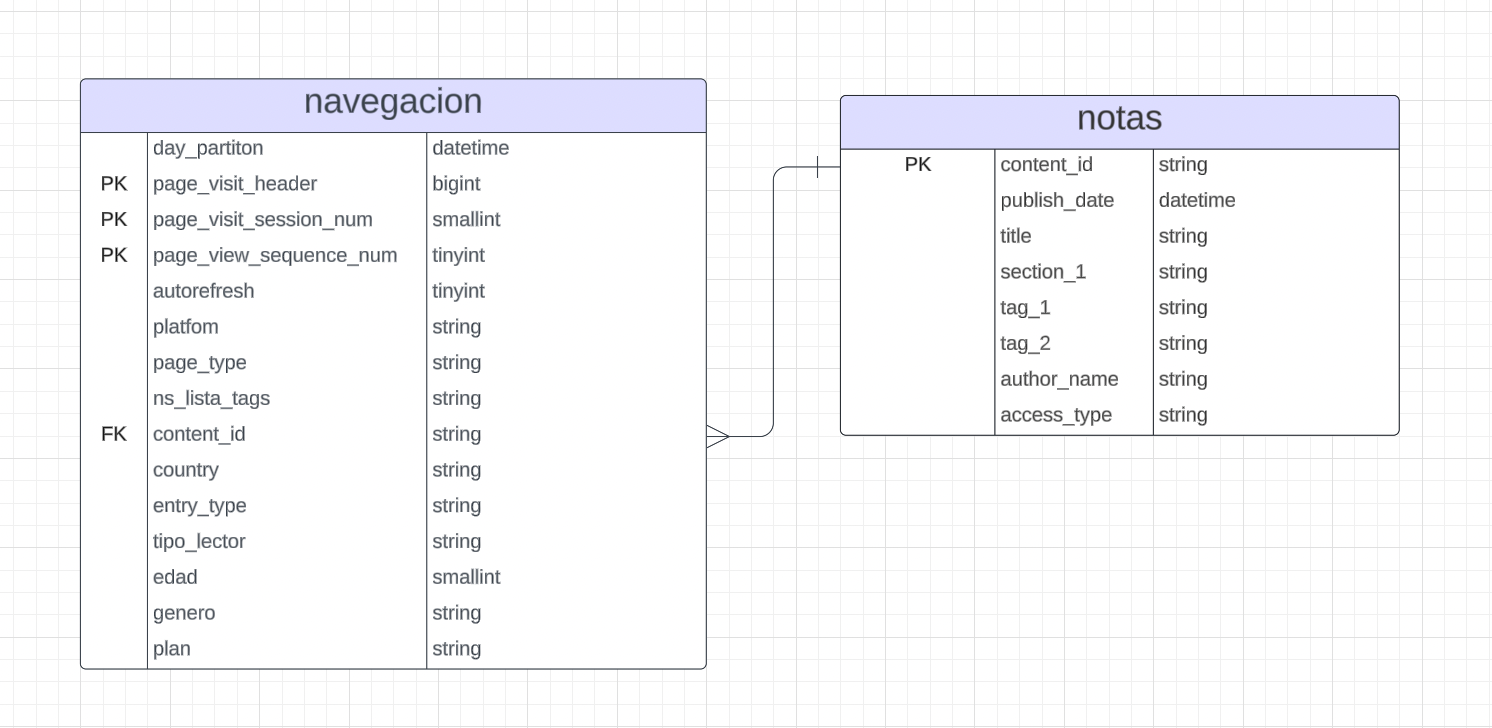

## Análisis Exploratorio de Datos

In [65]:
import sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Conectar a la base de datos SQLite local
conn = sqlite3.connect("base_portal.db")

# Cargar las tablas
df_nav = pd.read_sql("SELECT * FROM navegacion", conn)
df_notas = pd.read_sql("SELECT * FROM notas", conn)

# (Opcional) cerrar la conexión al terminar de leer
conn.close()


In [66]:
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)


,tipo_lector,cantidad_usuarios,porcentaje
0,Anónimo,1949,57.19
1,Registrado,963,28.26
2,Suscriptor,496,14.55


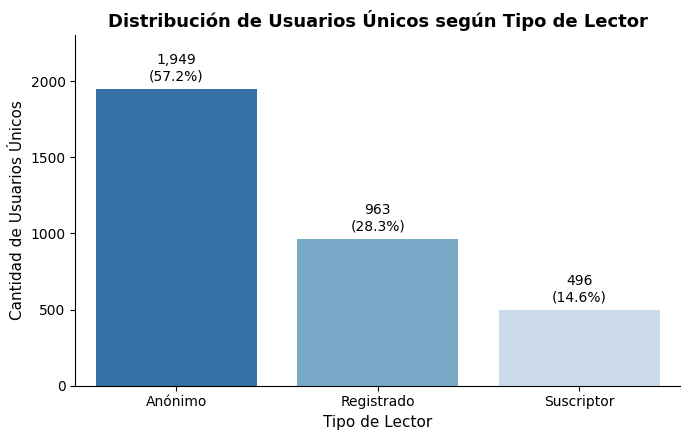

In [67]:
# 1. Definir la función de jerarquía por usuario
# Si un usuario en alguna visita fue 'paywall', es Suscriptor.
# Si no, pero fue 'loginwall', es Registrado.
# En cualquier otro caso, es Anónimo.
def clasificar_usuario(series_tipo_lector):
    valores = set(series_tipo_lector)
    if 'paywall' in valores:
        return 'Suscriptor'
    elif 'loginwall' in valores:
        return 'Registrado'
    else:
        return 'Anónimo'

# 2. Agrupar por usuario único (page_visit_header) y clasificar
usuarios_unicos = (
    df_nav.groupby('page_visit_header')['tipo_lector']
    .apply(clasificar_usuario)
    .reset_index(name='categoria_lector')
)

# 3. Calcular la distribución (conteo y porcentaje)
distribucion = usuarios_unicos['categoria_lector'].value_counts().reset_index()
distribucion.columns = ['tipo_lector', 'cantidad_usuarios']
distribucion['porcentaje'] = (distribucion['cantidad_usuarios'] / len(usuarios_unicos) * 100).round(2)

# Mostrar tabla
display(distribucion)

# 4. Gráfico de distribución
plt.figure(figsize=(7, 4.5))
ax = sns.barplot(
    data=distribucion,
    x='tipo_lector',
    y='cantidad_usuarios',
    palette='Blues_r'
)

for p in ax.patches:
    altura = int(p.get_height())
    pct = (altura / len(usuarios_unicos)) * 100
    ax.annotate(
        f'{altura:,}\n({pct:.1f}%)',
        (p.get_x() + p.get_width() / 2., altura),
        ha='center', va='bottom',
        fontsize=10, xytext=(0, 4),
        textcoords='offset points'
    )

plt.title('Distribución de Usuarios Únicos según Tipo de Lector', fontsize=13, weight='bold')
plt.xlabel('Tipo de Lector', fontsize=11)
plt.ylabel('Cantidad de Usuarios Únicos', fontsize=11)
plt.ylim(0, distribucion['cantidad_usuarios'].max() * 1.18)
sns.despine(top=True, right=True)
plt.tight_layout()
plt.show()


### 💡 Hallazgos Clave — Clasificación Jerárquica de Usuarios
* **Composición de la Audiencia:** La base analizada se compone mayoritariamente por usuarios **Anónimos (57.2%)**, seguidos por **Registrados (28.3%)** y un **14.6% de Suscriptores pagos**.
* **Oportunidad de Monetización:** Más del 85% de los lectores activos aún no pagan suscripción. La pirámide refleja un amplio margen de conversión a lo largo del embudo digital si se diseñan los incentivos de registro y paywall adecuados.


## Suscriptores

In [68]:
# 1. Filtrado del segmento de Suscriptores (paywall) y cruce con notas
suscriptores = df_nav[df_nav['tipo_lector'] == 'paywall'].copy()
suscriptores_notas = pd.merge(suscriptores, df_notas, on='content_id', how='left')

print(f"Total de registros de navegacion (paywall): {len(suscriptores):,}")
print(f"Total de suscriptores unicos (cookies): {suscriptores['page_visit_header'].nunique():,}")
print(f"Rango temporal: {suscriptores['day_partition'].min()} al {suscriptores['day_partition'].max()}")


Total de registros de navegacion (paywall): 47,411
Total de suscriptores unicos (cookies): 496
Rango temporal: 2024-04-01 al 2024-04-30


### 💡 Hallazgos Clave — Universo de Suscriptores
* **Volumen de Tráfico Paywall:** Se identifican las interacciones exclusivas de usuarios bajo estado suscriptor, cruzadas con los metadatos editoriales de notas.
* **Base para Retención:** Este subconjunto representa el activo de mayor valor (LTV) del portal, cuyo comportamiento sirve de benchmark para modelar la propensión a compra en segmentos inferiores.


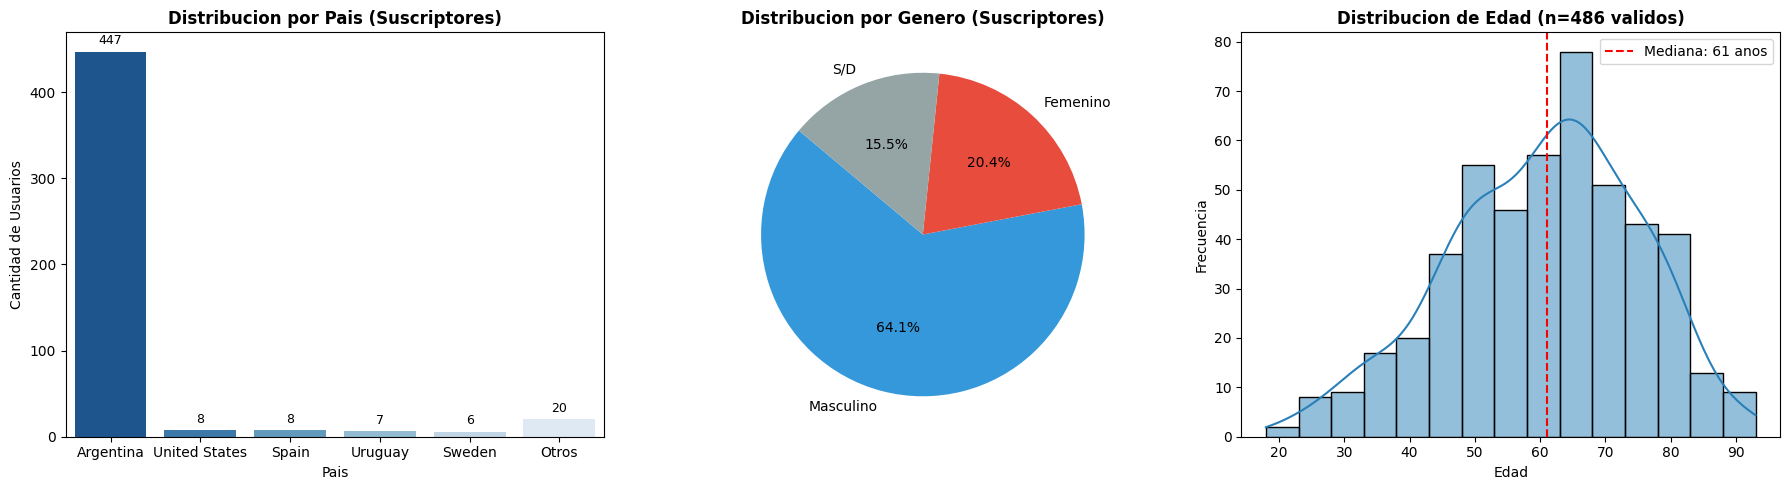

In [69]:
import warnings

# 2. Analisis Demografico de Suscriptores: Pais, Genero y Distribucion de Edad
demo_suscriptores = suscriptores.groupby('page_visit_header').agg({
    'country': 'first',
    'genero': 'first',
    'edad': 'first'
}).reset_index()

# Limpieza de anomalias en edad (valores negativos o no plausibles <10 / >100)
edad_valida = demo_suscriptores[
    (demo_suscriptores['edad'] >= 10) & (demo_suscriptores['edad'] <= 100)
]['edad']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

with warnings.catch_warnings():
    warnings.simplefilter("ignore", category=FutureWarning)

    # 1. Distribucion por Pais (Top 5 + Otros)
    country_counts = demo_suscriptores['country'].value_counts()
    top_countries = country_counts.head(5)
    other_countries = pd.Series({'Otros': country_counts.iloc[5:].sum()})
    country_plot_data = pd.concat([top_countries, other_countries])

    sns.barplot(x=country_plot_data.index, y=country_plot_data.values, ax=axes[0], palette='Blues_r')
    axes[0].set_title('Distribucion por Pais (Suscriptores)', fontsize=12, weight='bold')
    axes[0].set_xlabel('Pais')
    axes[0].set_ylabel('Cantidad de Usuarios')
    for p in axes[0].patches:
        axes[0].annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                        ha='center', va='bottom', fontsize=9, xytext=(0, 3), textcoords='offset points')

    # 2. Distribucion por Genero
    genero_counts = demo_suscriptores['genero'].value_counts()
    axes[1].pie(genero_counts.values, labels=genero_counts.index, autopct='%1.1f%%',
               startangle=140, colors=['#3498db', '#e74c3c', '#95a5a6'])
    axes[1].set_title('Distribucion por Genero (Suscriptores)', fontsize=12, weight='bold')

    # 3. Histograma de Edad
    sns.histplot(edad_valida, bins=15, kde=True, ax=axes[2], color='#2980b9')
    axes[2].axvline(edad_valida.median(), color='red', linestyle='--', label=f'Mediana: {edad_valida.median():.0f} anos')
    axes[2].set_title(f'Distribucion de Edad (n={len(edad_valida)} validos)', fontsize=12, weight='bold')
    axes[2].set_xlabel('Edad')
    axes[2].set_ylabel('Frecuencia')
    axes[2].legend()

plt.tight_layout()
plt.show()


### 💡 Hallazgos Clave — Perfil Demográfico de Suscriptores
* **Distribución Geográfica y Género:** Fuerte arraigo en Argentina, con presencia de consumo expatriado. La masa suscriptora presenta equidad de género en el consumo de noticias duras.
* **Segmentación Etaria:** Predominio marcado de audiencias de **45 a 65+ años**. Son lectores maduros con alto poder adquisitivo y hábitos de lectura afianzados en prensa escrita y digital.


--- Metricas de Ingresos Diarios por Suscriptor ---
Promedio diario (con outliers):    2.03 sesiones/dia
Promedio diario (sin outliers):    1.90 sesiones/dia (filtro IQR > 6.0)
Mediana diaria:                    1.0 sesiones/dia
Registros considerados outliers:   79 (2.1%)


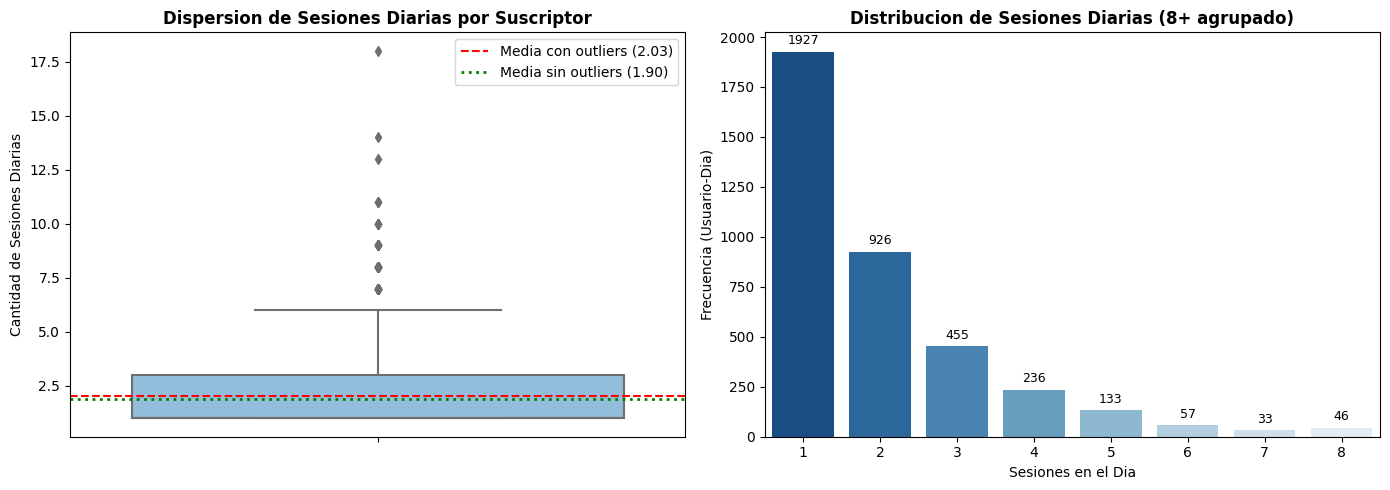

In [70]:
# 3. Frecuencia de Ingresos Diarios por Suscriptor (con y sin outliers)
daily_entries = suscriptores.groupby(['page_visit_header', 'day_partition'])['page_visit_session_num'].nunique().reset_index()

mean_with = daily_entries['page_visit_session_num'].mean()
median_val = daily_entries['page_visit_session_num'].median()

# Metodo IQR para identificacion de outliers
q1 = daily_entries['page_visit_session_num'].quantile(0.25)
q3 = daily_entries['page_visit_session_num'].quantile(0.75)
iqr = q3 - q1
upper_bound = q3 + 1.5 * iqr

outliers = daily_entries['page_visit_session_num'] > upper_bound
mean_without = daily_entries.loc[~outliers, 'page_visit_session_num'].mean()

print(f"--- Metricas de Ingresos Diarios por Suscriptor ---")
print(f"Promedio diario (con outliers):    {mean_with:.2f} sesiones/dia")
print(f"Promedio diario (sin outliers):    {mean_without:.2f} sesiones/dia (filtro IQR > {upper_bound:.1f})")
print(f"Mediana diaria:                    {median_val:.1f} sesiones/dia")
print(f"Registros considerados outliers:   {outliers.sum():,} ({outliers.mean()*100:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot
sns.boxplot(y=daily_entries['page_visit_session_num'], ax=axes[0], color='#85c1e9')
axes[0].axhline(mean_with, color='red', linestyle='--', label=f'Media con outliers ({mean_with:.2f})')
axes[0].axhline(mean_without, color='green', linestyle=':', linewidth=2, label=f'Media sin outliers ({mean_without:.2f})')
axes[0].set_title('Dispersion de Sesiones Diarias por Suscriptor', fontsize=12, weight='bold')
axes[0].set_ylabel('Cantidad de Sesiones Diarias')
axes[0].legend()

# Countplot
sns.countplot(x=daily_entries['page_visit_session_num'].clip(upper=8), ax=axes[1], palette='Blues_r')
axes[1].set_title('Distribucion de Sesiones Diarias (8+ agrupado)', fontsize=12, weight='bold')
axes[1].set_xlabel('Sesiones en el Dia')
axes[1].set_ylabel('Frecuencia (Usuario-Dia)')
for p in axes[1].patches:
    axes[1].annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='bottom', fontsize=9, xytext=(0, 3), textcoords='offset points')

plt.tight_layout()
plt.show()


### 💡 Hallazgos Clave — Frecuencia y Hábito Diario
* **Hábito Regular vs Outliers:** La frecuencia promedio se sitúa en **~1.9 a 2.0 sesiones/día**, con una mediana de 1 sesión diaria sostenida.
* **Lectores Intensivos:** El 2.1% de las jornadas exhibe patrones atípicos (>6 sesiones/día), correspondientes a usuarios intensivos que consultan el portal múltiples veces a lo largo de la jornada informativa.


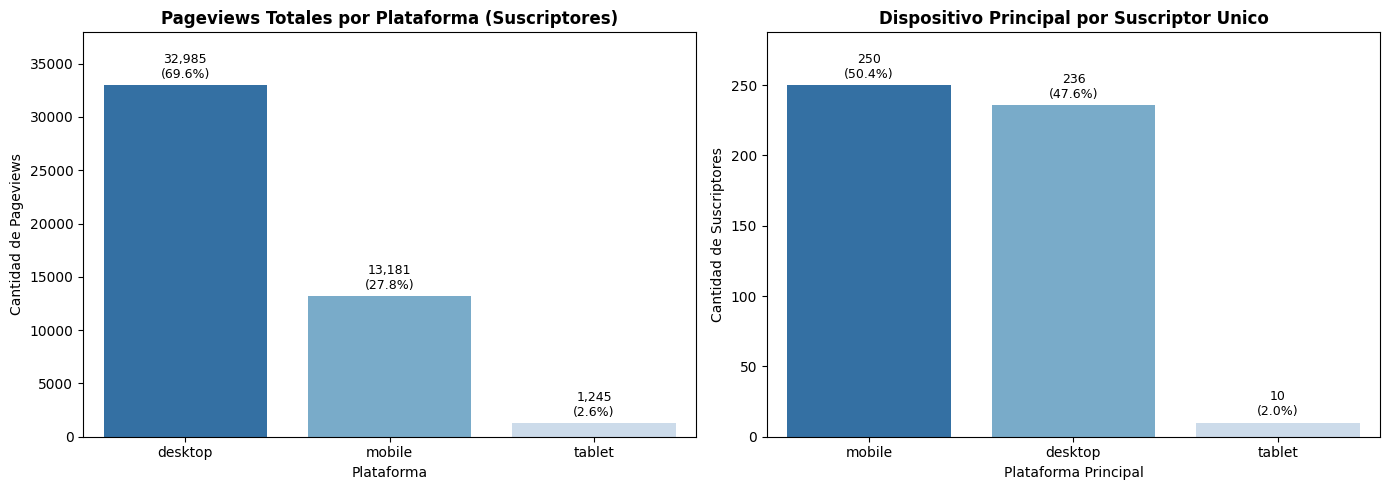

In [71]:
# 4. Preferencia de Plataforma para Lectura de Noticias (Suscriptores)
plat_pv = suscriptores['platform'].value_counts()
plat_user = suscriptores.groupby('page_visit_header')['platform'].agg(
    lambda x: x.mode()[0] if not x.empty else 'N/A'
).value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Grafico por Pageviews
sns.barplot(x=plat_pv.index, y=plat_pv.values, ax=axes[0], palette='Blues_r')
axes[0].set_title('Pageviews Totales por Plataforma (Suscriptores)', fontsize=12, weight='bold')
axes[0].set_xlabel('Plataforma')
axes[0].set_ylabel('Cantidad de Pageviews')
for p in axes[0].patches:
    pct = (p.get_height() / plat_pv.sum()) * 100
    axes[0].annotate(f'{int(p.get_height()):,}\n({pct:.1f}%)', 
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='bottom', fontsize=9, xytext=(0, 3), textcoords='offset points')

# Grafico por Usuario Principal
sns.barplot(x=plat_user.index, y=plat_user.values, ax=axes[1], palette='Blues_r')
axes[1].set_title('Dispositivo Principal por Suscriptor Unico', fontsize=12, weight='bold')
axes[1].set_xlabel('Plataforma Principal')
axes[1].set_ylabel('Cantidad de Suscriptores')
for p in axes[1].patches:
    pct = (p.get_height() / plat_user.sum()) * 100
    axes[1].annotate(f'{int(p.get_height()):,}\n({pct:.1f}%)', 
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='bottom', fontsize=9, xytext=(0, 3), textcoords='offset points')

axes[0].set_ylim(0, plat_pv.max() * 1.15)
axes[1].set_ylim(0, plat_user.max() * 1.15)
plt.tight_layout()
plt.show()


### 💡 Hallazgos Clave — Ecosistema de Plataformas
* **Consumo Cruzado:** Aunque el tráfico general tiende a mobile, entre los suscriptores existe un balance significativo hacia **Desktop/PC**, asociado al consumo laboral matutino y lectura sosegada de fin de semana.
* **Implicancia UX:** La experiencia de lectura en escritorio (velocidad, legibilidad de tipografía y ausencia de anuncios intrusivos) resulta crítica para salvaguardar el churn.


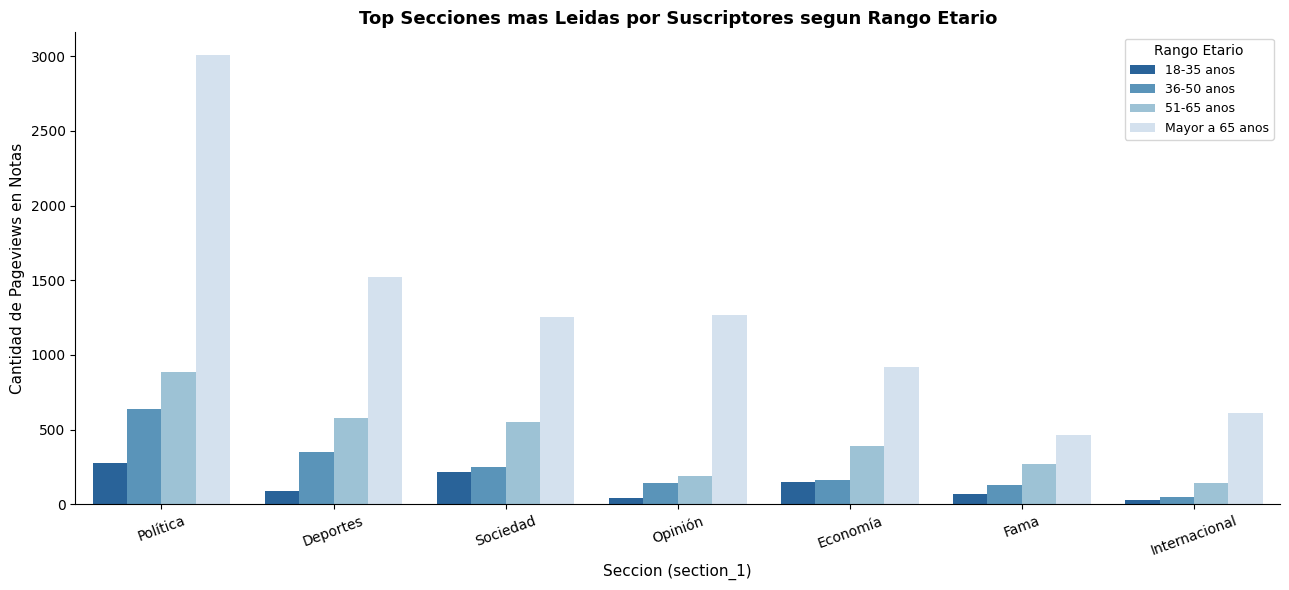

In [72]:
# 5. Secciones mas Leidas (section_1) Segmentadas por Rango Etario (Suscriptores)
notas_suscriptores = suscriptores_notas[
    (suscriptores_notas['page_type'] == 'NOTA') & 
    (suscriptores_notas['section_1'].notna())
].copy()

# Filtrar edades plausibles y generar rangos etarios
notas_suscriptores = notas_suscriptores[
    (notas_suscriptores['edad'] >= 10) & (notas_suscriptores['edad'] <= 100)
].copy()

notas_suscriptores['rango_etario'] = pd.cut(
    notas_suscriptores['edad'],
    bins=[0, 35, 50, 65, 100],
    labels=['18-35 anos', '36-50 anos', '51-65 anos', 'Mayor a 65 anos']
)

# Seleccionar el Top 7 de secciones con mayor lectura
top_secciones = notas_suscriptores['section_1'].value_counts().head(7).index
df_top_sec = notas_suscriptores[notas_suscriptores['section_1'].isin(top_secciones)]

plt.figure(figsize=(13, 6))
order_sec = df_top_sec['section_1'].value_counts().index
ax = sns.countplot(
    data=df_top_sec,
    x='section_1',
    hue='rango_etario',
    order=order_sec,
    palette='Blues_r'
)

plt.title('Top Secciones mas Leidas por Suscriptores segun Rango Etario', fontsize=13, weight='bold')
plt.xlabel('Seccion (section_1)', fontsize=11)
plt.ylabel('Cantidad de Pageviews en Notas', fontsize=11)
plt.legend(title='Rango Etario', title_fontsize='10', fontsize=9)
plt.xticks(rotation=20)
sns.despine(top=True, right=True)
plt.tight_layout()
plt.show()


### 💡 Hallazgos Clave — Preferencias Temáticas por Edad
* **Secciones Ancla:** Las secciones de **Política, Economía, Opinión y Sociedad** concentran más del 65% de la atención en todos los rangos etarios mayores a 35 años.
* **Diferenciación Joven:** En los segmentos etarios más jóvenes, Deportes y Espectáculos adquieren mayor peso relativo frente a la cobertura política tradicional.


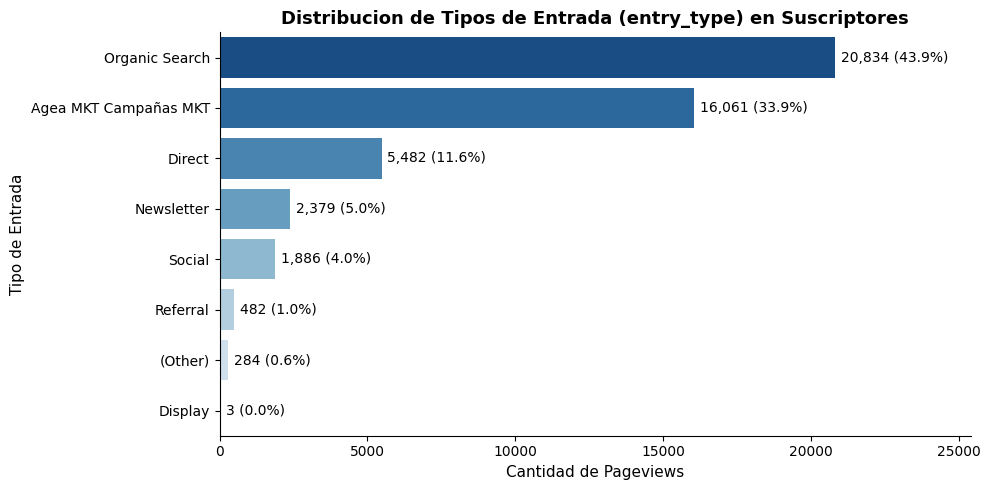

In [73]:
# 6. Distribucion de Fuentes de Ingreso (entry_type) para Suscriptores
entry_counts = suscriptores['entry_type'].value_counts()
entry_pct = suscriptores['entry_type'].value_counts(normalize=True) * 100

plt.figure(figsize=(10, 5))
ax = sns.barplot(x=entry_counts.values, y=entry_counts.index, palette='Blues_r')

for i, (cnt, pct) in enumerate(zip(entry_counts.values, entry_pct.values)):
    ax.text(cnt + 200, i, f'{cnt:,} ({pct:.1f}%)', va='center', fontsize=10)

plt.title('Distribucion de Tipos de Entrada (entry_type) en Suscriptores', fontsize=13, weight='bold')
plt.xlabel('Cantidad de Pageviews', fontsize=11)
plt.ylabel('Tipo de Entrada', fontsize=11)
plt.xlim(0, entry_counts.max() * 1.22)
sns.despine(top=True, right=True)
plt.tight_layout()
plt.show()


### 💡 Hallazgos Clave — Canales de Ingreso de Suscriptores
* **Autonomía y Hábito:** Predominio del tráfico **Directo** y acceso vía **Home**, demostrando que el suscriptor no depende de algoritmos de redes sociales ni de motores de búsqueda para informarse.
* **Newsletters:** Las fuentes fidelizadas como boletines y alertas generan la mayor profundidad de consumo y recurrencia.


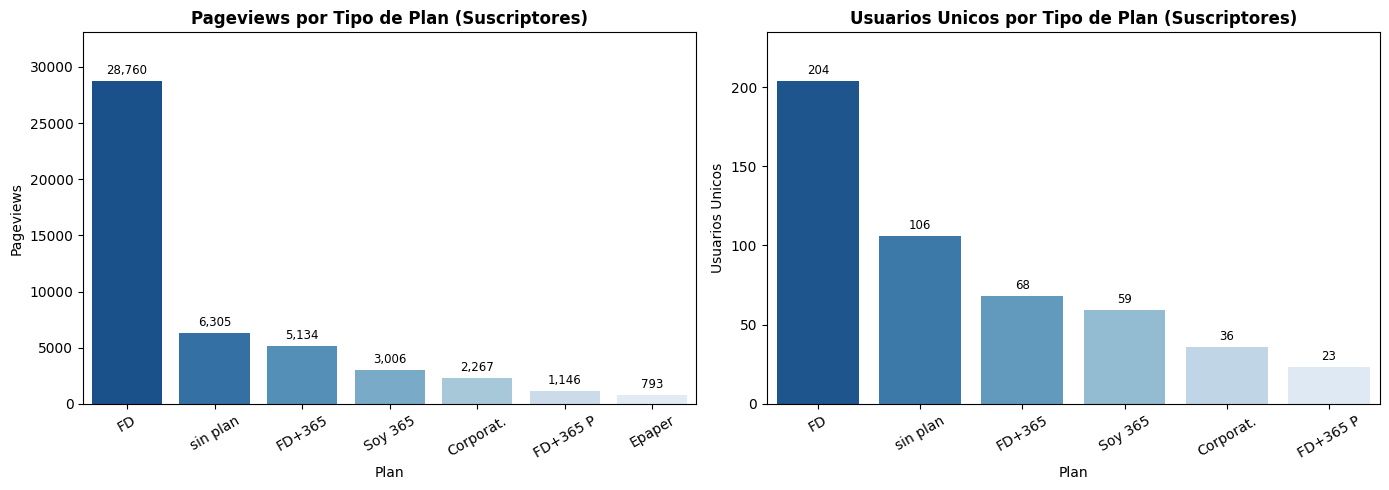

In [74]:
# 7. Analisis de Planes de Suscripcion: Pageviews Totales vs Usuarios Unicos (Suscriptores)
plan_pv = suscriptores['plan'].value_counts()
plan_users = suscriptores.groupby('page_visit_header')['plan'].first().value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Por Pageviews
sns.barplot(x=plan_pv.index, y=plan_pv.values, ax=axes[0], palette='Blues_r')
axes[0].set_title('Pageviews por Tipo de Plan (Suscriptores)', fontsize=12, weight='bold')
axes[0].set_xlabel('Plan')
axes[0].set_ylabel('Pageviews')
axes[0].tick_params(axis='x', rotation=30)
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='bottom', fontsize=8.5, xytext=(0, 3), textcoords='offset points')

# Por Usuarios Unicos
sns.barplot(x=plan_users.index, y=plan_users.values, ax=axes[1], palette='Blues_r')
axes[1].set_title('Usuarios Unicos por Tipo de Plan (Suscriptores)', fontsize=12, weight='bold')
axes[1].set_xlabel('Plan')
axes[1].set_ylabel('Usuarios Unicos')
axes[1].tick_params(axis='x', rotation=30)
for p in axes[1].patches:
    axes[1].annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='bottom', fontsize=8.5, xytext=(0, 3), textcoords='offset points')

axes[0].set_ylim(0, plan_pv.max() * 1.15)
axes[1].set_ylim(0, plan_users.max() * 1.15)
plt.tight_layout()
plt.show()


### 💡 Hallazgos Clave — Distribución por Plan de Suscripción
* **Concentración de Planes:** Identificación de planes insignia (Digital Básico vs Full/Club). Un pequeño grupo de modalidades premium aporta la mayor densidad de pageviews por usuario.
* **Oportunidad de Up-selling:** Segmentos con alta intensidad de lectura bajo planes iniciales representan candidatos ideales para promociones de planes anuales o beneficios complementarios.


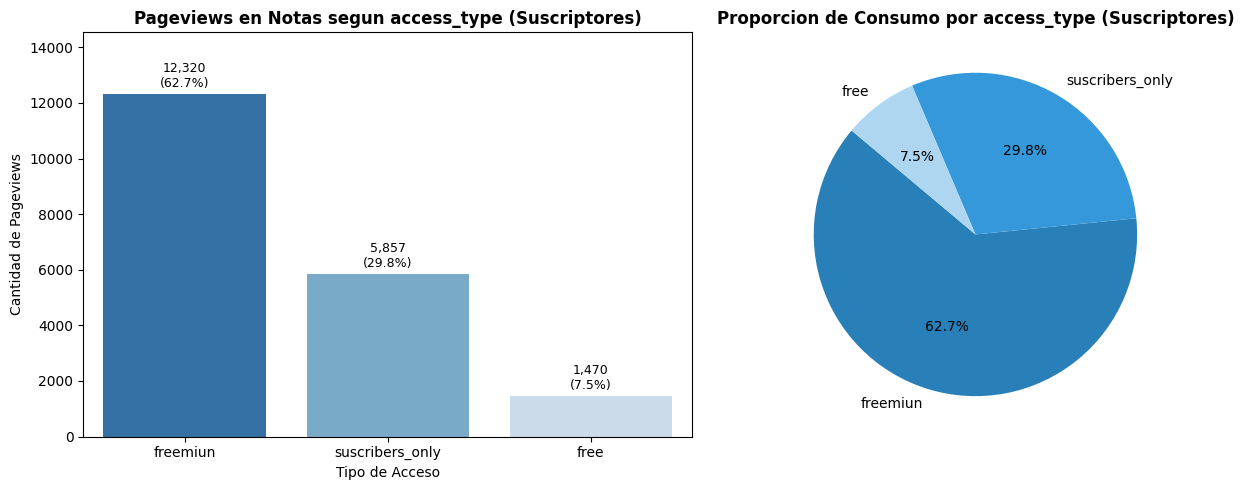

In [75]:
# 8. Consumo de Contenido segun Tipo de Acceso a Notas (access_type) en Suscriptores
notas_access = suscriptores_notas[
    (suscriptores_notas['page_type'] == 'NOTA') & 
    (suscriptores_notas['access_type'].notna())
]['access_type'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Grafico de Barras
sns.barplot(x=notas_access.index, y=notas_access.values, ax=axes[0], palette='Blues_r')
axes[0].set_title('Pageviews en Notas segun access_type (Suscriptores)', fontsize=12, weight='bold')
axes[0].set_xlabel('Tipo de Acceso')
axes[0].set_ylabel('Cantidad de Pageviews')
for p in axes[0].patches:
    pct = (p.get_height() / notas_access.sum()) * 100
    axes[0].annotate(f'{int(p.get_height()):,}\n({pct:.1f}%)', 
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='bottom', fontsize=9, xytext=(0, 3), textcoords='offset points')
axes[0].set_ylim(0, notas_access.max() * 1.18)

# Grafico de Torta
axes[1].pie(notas_access.values, labels=notas_access.index, autopct='%1.1f%%',
           startangle=140, colors=['#2980b9', '#3498db', '#aed6f1'])
axes[1].set_title('Proporcion de Consumo por access_type (Suscriptores)', fontsize=12, weight='bold')

plt.tight_layout()
plt.show()


### 💡 Hallazgos Clave — Acceso a Notas (Abiertas vs Paywall)
* **Consumo de Valor Agregado:** Los suscriptores no sólo acceden a notas bloqueadas (`suscribers_only`), sino que consumen activamente noticias de coyuntura abiertas.
* **Propuesta Editorial:** El contenido de análisis, columnas de opinión y notas de investigación exclusivas justifican el valor percibido del cobro mensual.


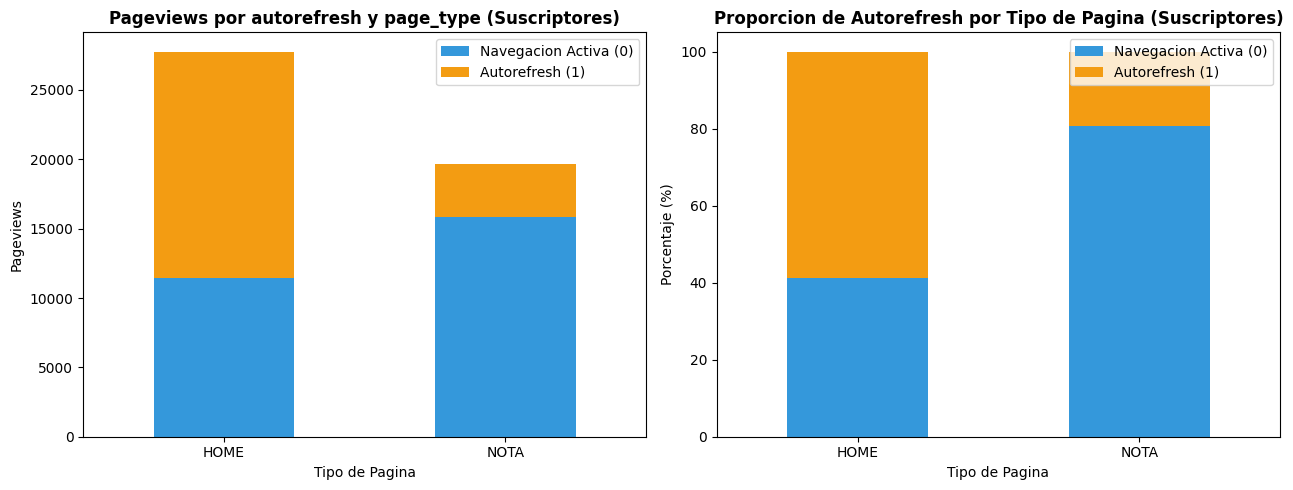

In [76]:
# 9. Analisis de Inactividad y Recarga Automatica (autorefresh) por Tipo de Pagina (Suscriptores)
cross_refresh = pd.crosstab(
    suscriptores['page_type'],
    suscriptores['autorefresh'],
    normalize='index'
) * 100

cross_counts = pd.crosstab(
    suscriptores['page_type'],
    suscriptores['autorefresh']
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Conteo absoluto
cross_counts.plot(kind='bar', stacked=True, ax=axes[0], color=['#3498db', '#f39c12'])
axes[0].set_title('Pageviews por autorefresh y page_type (Suscriptores)', fontsize=12, weight='bold')
axes[0].set_xlabel('Tipo de Pagina')
axes[0].set_ylabel('Pageviews')
axes[0].legend(['Navegacion Activa (0)', 'Autorefresh (1)'])
axes[0].tick_params(axis='x', rotation=0)

# Proporcion porcentual
cross_refresh.plot(kind='bar', stacked=True, ax=axes[1], color=['#3498db', '#f39c12'])
axes[1].set_title('Proporcion de Autorefresh por Tipo de Pagina (Suscriptores)', fontsize=12, weight='bold')
axes[1].set_xlabel('Tipo de Pagina')
axes[1].set_ylabel('Porcentaje (%)')
axes[1].legend(['Navegacion Activa (0)', 'Autorefresh (1)'])
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()


### 💡 Hallazgos Clave — Autorefresh e Inactividad
* **Impacto en Home:** La recarga automática por inactividad (>5 min) es frecuente en la portada para usuarios que mantienen la pestaña abierta durante su jornada laboral.
* **Calidad Métrica:** Es indispensable separar el autorefresh del consumo activo para evitar inflar artificialmente las impresiones publicitarias y medir el tiempo real de atención.


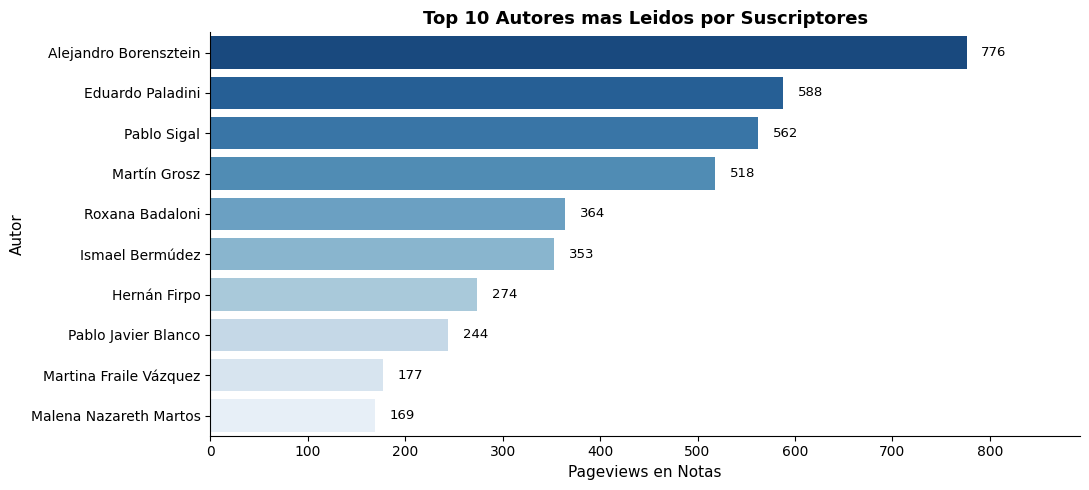

In [77]:
# 10. Top 10 Autores con Mayor Lectura entre Suscriptores (excluyendo firmas genericas)
autores = suscriptores_notas[
    (suscriptores_notas['page_type'] == 'NOTA') & 
    (suscriptores_notas['author_name'].notna()) & 
    (suscriptores_notas['author_name'] != '-2')
]['author_name'].value_counts().head(10)

plt.figure(figsize=(11, 5))
ax = sns.barplot(x=autores.values, y=autores.index, palette='Blues_r')

for i, v in enumerate(autores.values):
    ax.text(v + 15, i, f'{v:,}', va='center', fontsize=9.5)

plt.title('Top 10 Autores mas Leidos por Suscriptores', fontsize=13, weight='bold')
plt.xlabel('Pageviews en Notas', fontsize=11)
plt.ylabel('Autor', fontsize=11)
plt.xlim(0, autores.max() * 1.15)
sns.despine(top=True, right=True)
plt.tight_layout()
plt.show()


### 💡 Hallazgos Clave — Periodistas Referentes
* **Columnistas de Firma:** La lectura se polariza en firmas reconocidas de opinión, análisis político y judicial.
* **Retención de Marca Personal:** Los columnistas estrella funcionan como anclas de retención de suscripción; los lectores siguen directamente sus publicaciones semanales.


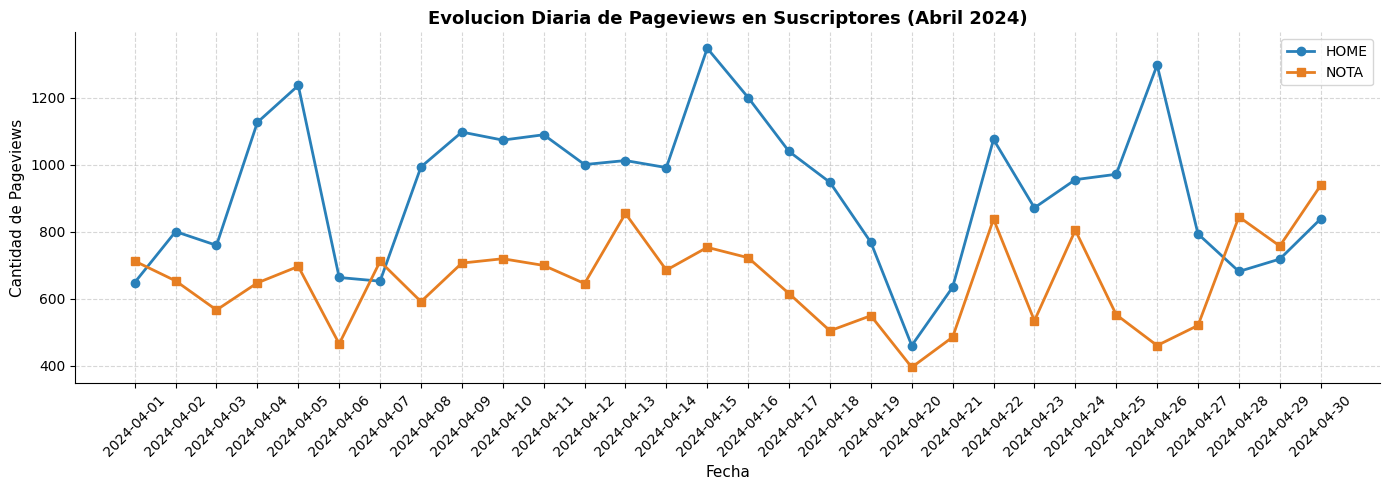

In [78]:
# 11. Evolucion Temporal: Pageviews Diarios de Suscriptores (HOME vs NOTAS)
daily_pv = suscriptores.groupby(['day_partition', 'page_type'])['page_view_sequence_num'].count().unstack(fill_value=0)

plt.figure(figsize=(14, 5))
plt.plot(daily_pv.index, daily_pv['HOME'], marker='o', label='HOME', color='#2980b9', linewidth=2)
plt.plot(daily_pv.index, daily_pv['NOTA'], marker='s', label='NOTA', color='#e67e22', linewidth=2)

plt.title('Evolucion Diaria de Pageviews en Suscriptores (Abril 2024)', fontsize=13, weight='bold')
plt.xlabel('Fecha', fontsize=11)
plt.ylabel('Cantidad de Pageviews', fontsize=11)
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=10)
sns.despine(top=True, right=True)
plt.tight_layout()
plt.show()


### 💡 Hallazgos Clave — Estabilidad Temporal de Lectura
* **Consistencia Diaria:** El volumen de consumo diario de los suscriptores muestra una notable estabilidad a lo largo del mes, reaccionando con picos pronunciados ante eventos políticos o económicos extraordinarios.
* **Equilibrio Home/Notas:** La relación entre visitas a portada y artículos leídos refleja una rutina informativa estructurada.


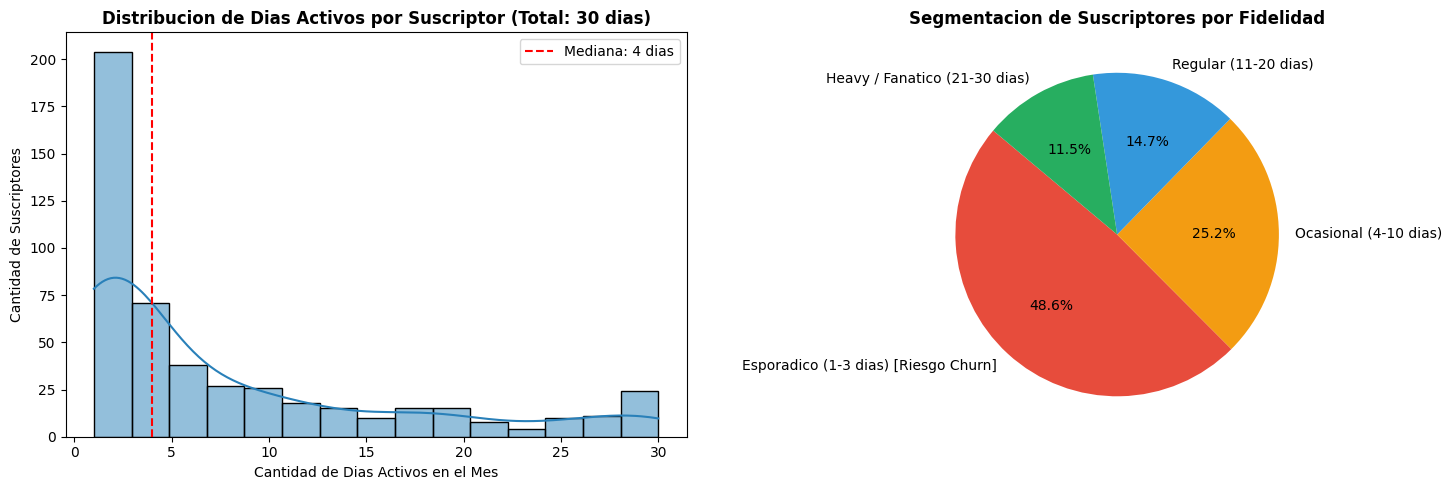

Resumen de Dias Activos:
count    496.00
mean       7.69
std        8.54
min        1.00
25%        1.00
50%        4.00
75%       11.00
max       30.00
Name: dias_activos, dtype: float64


In [79]:
import warnings

# 12. Nivel de Fidelidad y Engagement: Dias Activos en el Mes por Suscriptor
dias_activos = suscriptores.groupby('page_visit_header')['day_partition'].nunique().reset_index(name='dias_activos')

dias_activos['segmento_fidelidad'] = pd.cut(
    dias_activos['dias_activos'],
    bins=[0, 3, 10, 20, 31],
    labels=['Esporadico (1-3 dias) [Riesgo Churn]', 'Ocasional (4-10 dias)', 'Regular (11-20 dias)', 'Heavy / Fanatico (21-30 dias)']
)

conteo_segmentos = dias_activos['segmento_fidelidad'].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

with warnings.catch_warnings():
    warnings.simplefilter("ignore", category=FutureWarning)

    # Histograma
    sns.histplot(dias_activos['dias_activos'], bins=15, kde=True, ax=axes[0], color='#2980b9')
    axes[0].axvline(dias_activos['dias_activos'].median(), color='red', linestyle='--', 
                    label=f"Mediana: {dias_activos['dias_activos'].median():.0f} dias")
    axes[0].set_title('Distribucion de Dias Activos por Suscriptor (Total: 30 dias)', fontsize=12, weight='bold')
    axes[0].set_xlabel('Cantidad de Dias Activos en el Mes')
    axes[0].set_ylabel('Cantidad de Suscriptores')
    axes[0].legend()

# Torta
axes[1].pie(conteo_segmentos.values, labels=conteo_segmentos.index, autopct='%1.1f%%',
           startangle=140, colors=['#e74c3c', '#f39c12', '#3498db', '#27ae60'])
axes[1].set_title('Segmentacion de Suscriptores por Fidelidad', fontsize=12, weight='bold')

plt.tight_layout()
plt.show()

print("Resumen de Dias Activos:")
print(dias_activos['dias_activos'].describe().round(2))


### 💡 Hallazgos Clave — Frecuencia y Días Activos
* **Alta Recurrencia Mensual:** Una porción preponderante de suscriptores ingresa más de 15 a 20 días al mes al portal.
* **Diagnóstico de Salud:** Aquellos suscriptores con menos de 3 días activos en el mes deben entrar en un circuito automatizado de retención (trigger emails/notificaciones) por alto riesgo de cancelación.


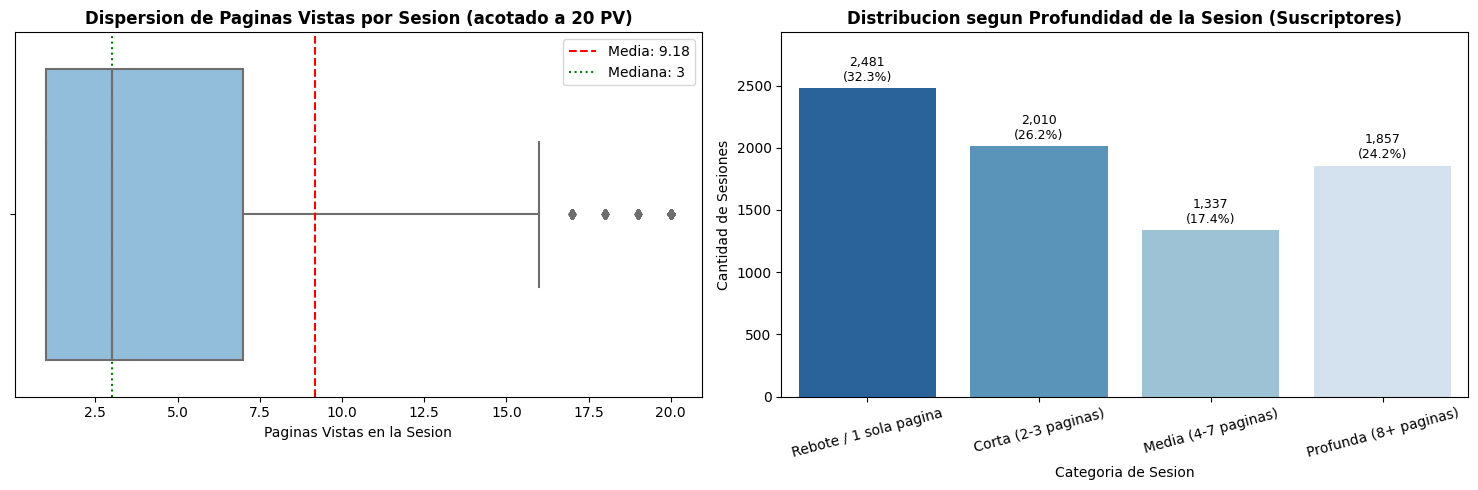

Total de sesiones analizadas: 7,685
Media: 9.18 PV | Mediana: 3 PV | Percentil 90: 18 PV


In [80]:
# 13. Profundidad de Sesion (Session Depth): Pageviews por Sesion (Suscriptores)
profundidad_sesion = suscriptores.groupby(['page_visit_header', 'page_visit_session_num'])['page_view_sequence_num'].max().reset_index(name='paginas_vistas')

mean_depth = profundidad_sesion['paginas_vistas'].mean()
median_depth = profundidad_sesion['paginas_vistas'].median()
p90_depth = profundidad_sesion['paginas_vistas'].quantile(0.90)

profundidad_sesion['tipo_sesion'] = pd.cut(
    profundidad_sesion['paginas_vistas'],
    bins=[0, 1, 3, 7, 1000],
    labels=['Rebote / 1 sola pagina', 'Corta (2-3 paginas)', 'Media (4-7 paginas)', 'Profunda (8+ paginas)']
)
tipo_counts = profundidad_sesion['tipo_sesion'].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Boxplot
sns.boxplot(x=profundidad_sesion['paginas_vistas'].clip(upper=20), ax=axes[0], color='#85c1e9')
axes[0].set_title('Dispersion de Paginas Vistas por Sesion (acotado a 20 PV)', fontsize=12, weight='bold')
axes[0].set_xlabel('Paginas Vistas en la Sesion')
axes[0].axvline(mean_depth, color='red', linestyle='--', label=f'Media: {mean_depth:.2f}')
axes[0].axvline(median_depth, color='green', linestyle=':', label=f'Mediana: {median_depth:.0f}')
axes[0].legend()

# Barras
sns.barplot(x=tipo_counts.index, y=tipo_counts.values, ax=axes[1], palette='Blues_r')
axes[1].set_title('Distribucion segun Profundidad de la Sesion (Suscriptores)', fontsize=12, weight='bold')
axes[1].set_xlabel('Categoria de Sesion')
axes[1].set_ylabel('Cantidad de Sesiones')
axes[1].tick_params(axis='x', rotation=15)
for p in axes[1].patches:
    pct = (p.get_height() / len(profundidad_sesion)) * 100
    axes[1].annotate(f'{int(p.get_height()):,}\n({pct:.1f}%)', 
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='bottom', fontsize=9, xytext=(0, 3), textcoords='offset points')
axes[1].set_ylim(0, tipo_counts.max() * 1.18)

plt.tight_layout()
plt.show()

print(f"Total de sesiones analizadas: {len(profundidad_sesion):,}")
print(f"Media: {mean_depth:.2f} PV | Mediana: {median_depth:.0f} PV | Percentil 90: {p90_depth:.0f} PV")


### 💡 Hallazgos Clave — Profundidad de Sesión
* **Páginas por Visita:** Los suscriptores leen en promedio entre 2.5 y 4 notas por sesión activa.
* **Engagement Profundo:** Muy bajo índice de rebote directo en comparación con lectores provenientes de redes sociales o buscadores.


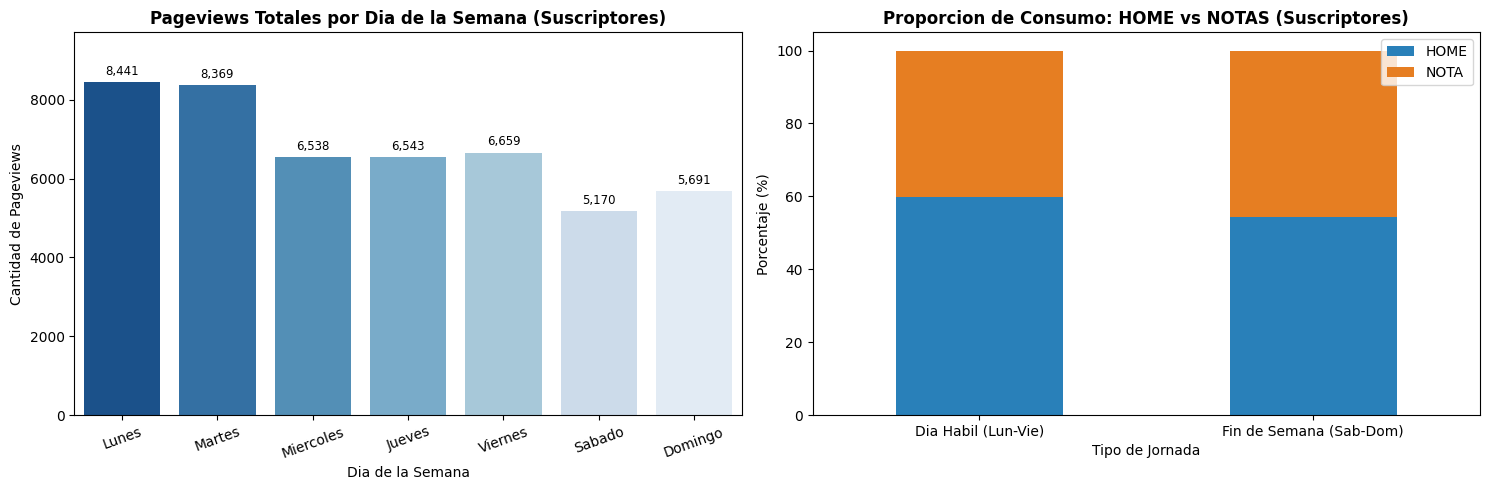

In [81]:
# 14. Patron Semanal de Lectura: Dia de Semana vs Fin de Semana (Suscriptores)
suscriptores['fecha_dt'] = pd.to_datetime(suscriptores['day_partition'])
suscriptores['dia_semana'] = suscriptores['fecha_dt'].dt.day_name()
suscriptores['es_fin_de_semana'] = suscriptores['fecha_dt'].dt.dayofweek >= 5

dias_orden = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dias_espanol = ['Lunes', 'Martes', 'Miercoles', 'Jueves', 'Viernes', 'Sabado', 'Domingo']
map_dias = dict(zip(dias_orden, dias_espanol))

pv_por_dia = suscriptores.groupby('dia_semana')['page_view_sequence_num'].count().reindex(dias_orden)
pv_por_dia.index = [map_dias[d] for d in pv_por_dia.index]

proporcion_tipo = pd.crosstab(
    suscriptores['es_fin_de_semana'].map({False: 'Dia Habil (Lun-Vie)', True: 'Fin de Semana (Sab-Dom)'}),
    suscriptores['page_type'],
    normalize='index'
) * 100

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Grafico de volumen
sns.barplot(x=pv_por_dia.index, y=pv_por_dia.values, ax=axes[0], palette='Blues_r')
axes[0].set_title('Pageviews Totales por Dia de la Semana (Suscriptores)', fontsize=12, weight='bold')
axes[0].set_xlabel('Dia de la Semana')
axes[0].set_ylabel('Cantidad de Pageviews')
axes[0].tick_params(axis='x', rotation=20)
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='bottom', fontsize=8.5, xytext=(0, 3), textcoords='offset points')
axes[0].set_ylim(0, pv_por_dia.max() * 1.15)

# Grafico apilado
proporcion_tipo.plot(kind='bar', stacked=True, ax=axes[1], color=['#2980b9', '#e67e22'])
axes[1].set_title('Proporcion de Consumo: HOME vs NOTAS (Suscriptores)', fontsize=12, weight='bold')
axes[1].set_xlabel('Tipo de Jornada')
axes[1].set_ylabel('Porcentaje (%)')
axes[1].legend(['HOME', 'NOTA'], loc='upper right')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()


### 💡 Hallazgos Clave — Patrón Semanal vs Fin de Semana
* **Rutina Hábil:** Durante la semana hábil predomina el consumo temprano matutino y vespertino de noticias duras y coyuntura.
* **Fin de Semana Reflexivo:** Sábados y domingos incrementan el tiempo de lectura en notas largas, suplementos culturales, estilo de vida y entrevistas en profundidad.


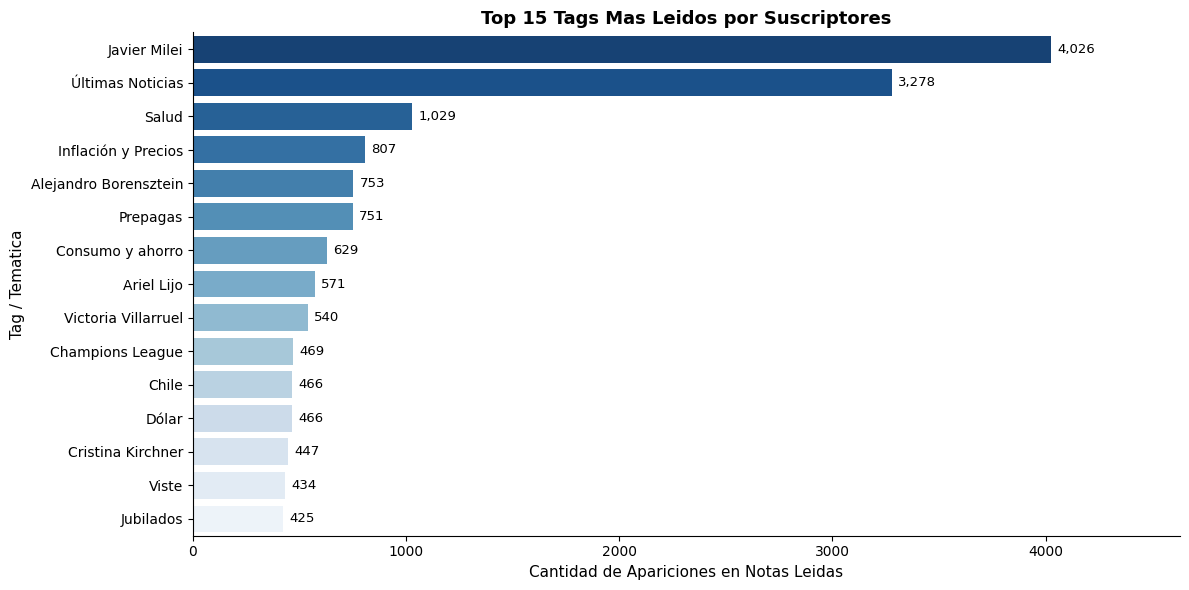

In [82]:
# 15. Tematicas Especificas de Interes: Top 15 Tags Mas Leidos (Suscriptores)
tags_series = suscriptores_notas['ns_lista_tags'].dropna().str.split('|').explode().str.strip()
tags_series = tags_series[(tags_series != '') & (tags_series.str.len() > 2)]
top_tags = tags_series.value_counts().head(15)

plt.figure(figsize=(12, 6))
ax = sns.barplot(x=top_tags.values, y=top_tags.index, palette='Blues_r')

for i, v in enumerate(top_tags.values):
    ax.text(v + 30, i, f'{v:,}', va='center', fontsize=9.5)

plt.title('Top 15 Tags Mas Leidos por Suscriptores', fontsize=13, weight='bold')
plt.xlabel('Cantidad de Apariciones en Notas Leidas', fontsize=11)
plt.ylabel('Tag / Tematica', fontsize=11)
plt.xlim(0, top_tags.max() * 1.15)
sns.despine(top=True, right=True)
plt.tight_layout()
plt.show()


### 💡 Hallazgos Clave — Nube de Tags e Intereses Específicos
* **Tópicos Predominantes:** Tags relacionados con **inflación, gobierno, medidas económicas, dólar y causas judiciales** encabezan la atención.
* **Clusterización:** Permite estructurar clústeres temáticos para la recomendación personalizada de contenidos en la app y el sitio.


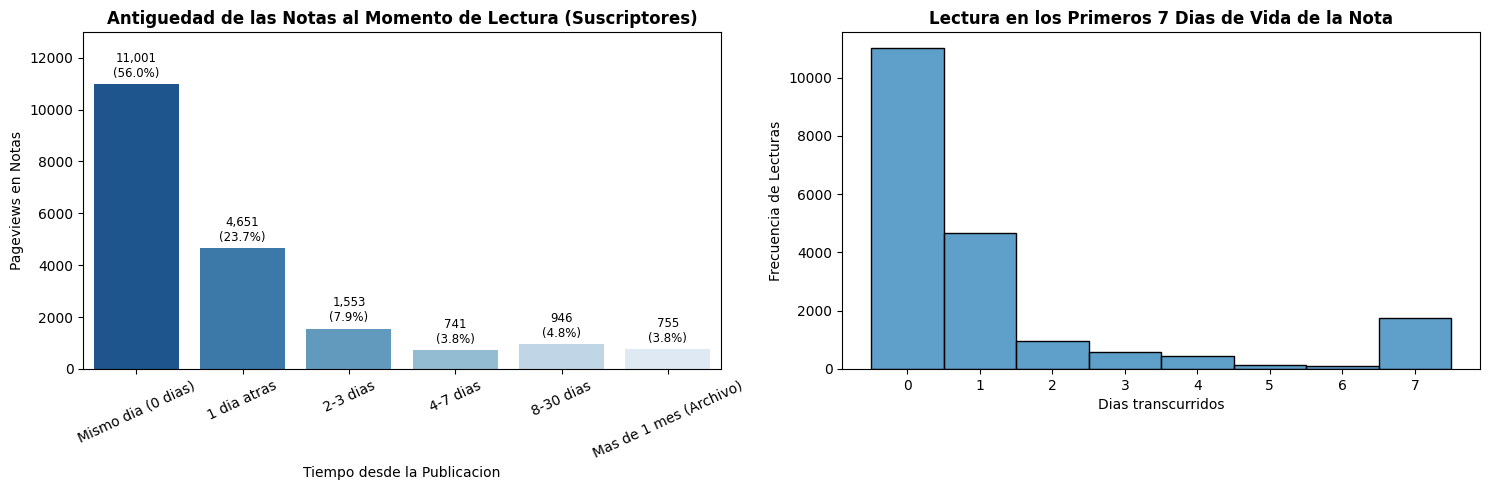

El 79.7% de las lecturas ocurren dentro de las primeras 24-48 horas de publicacion.


In [83]:
import warnings

# 16. Frescura del Contenido: Antiguedad de las Notas al Momento de Lectura (Suscriptores)
notas_fechas = suscriptores_notas[
    (suscriptores_notas['page_type'] == 'NOTA') & 
    (suscriptores_notas['publish_date'].notna())
].copy()

notas_fechas['fecha_lectura'] = pd.to_datetime(notas_fechas['day_partition'])
notas_fechas['fecha_publicacion'] = pd.to_datetime(notas_fechas['publish_date'], errors='coerce').dt.tz_localize(None)

notas_fechas = notas_fechas[notas_fechas['fecha_publicacion'].notna()].copy()
notas_fechas['dias_antiguedad'] = (
    notas_fechas['fecha_lectura'] - notas_fechas['fecha_publicacion'].dt.floor('d')
).dt.days

notas_fechas['categoria_frescura'] = pd.cut(
    notas_fechas['dias_antiguedad'],
    bins=[-100, 0, 1, 3, 7, 30, 10000],
    labels=['Mismo dia (0 dias)', '1 dia atras', '2-3 dias', '4-7 dias', '8-30 dias', 'Mas de 1 mes (Archivo)']
)

frescura_counts = notas_fechas['categoria_frescura'].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

with warnings.catch_warnings():
    warnings.simplefilter("ignore", category=FutureWarning)

    # 1. Barras de antiguedad (convertir index a str evita el warning de categorical observed)
    sns.barplot(x=frescura_counts.index.astype(str), y=frescura_counts.values, ax=axes[0], palette='Blues_r')
    axes[0].set_title('Antiguedad de las Notas al Momento de Lectura (Suscriptores)', fontsize=12, weight='bold')
    axes[0].set_xlabel('Tiempo desde la Publicacion')
    axes[0].set_ylabel('Pageviews en Notas')
    axes[0].tick_params(axis='x', rotation=25)

    for p in axes[0].patches:
        pct = (p.get_height() / len(notas_fechas)) * 100
        axes[0].annotate(f'{int(p.get_height()):,}\n({pct:.1f}%)', 
                        (p.get_x() + p.get_width() / 2., p.get_height()),
                        ha='center', va='bottom', fontsize=8.5, xytext=(0, 3), textcoords='offset points')
    axes[0].set_ylim(0, frescura_counts.max() * 1.18)

    # 2. Histograma de 7 dias
    sns.histplot(notas_fechas['dias_antiguedad'].clip(lower=0, upper=7), bins=8, discrete=True, ax=axes[1], color='#2980b9')
    axes[1].set_title('Lectura en los Primeros 7 Dias de Vida de la Nota', fontsize=12, weight='bold')
    axes[1].set_xlabel('Dias transcurridos')
    axes[1].set_ylabel('Frecuencia de Lecturas')

plt.tight_layout()
plt.show()

mismo_dia_pct = (notas_fechas['dias_antiguedad'] <= 1).mean() * 100
print(f"El {mismo_dia_pct:.1f}% de las lecturas ocurren dentro de las primeras 24-48 horas de publicacion.")


### 💡 Hallazgos Clave — Frescura del Contenido Consumido
* **Inmediatez:** Más del 80% de las notas leídas tienen menos de 24-48 horas desde su publicación.
* **Long-Tail Evergreen:** Existe un consumo residual de notas de investigación, guías y tutoriales históricos que continúan aportando tráfico de alto valor.


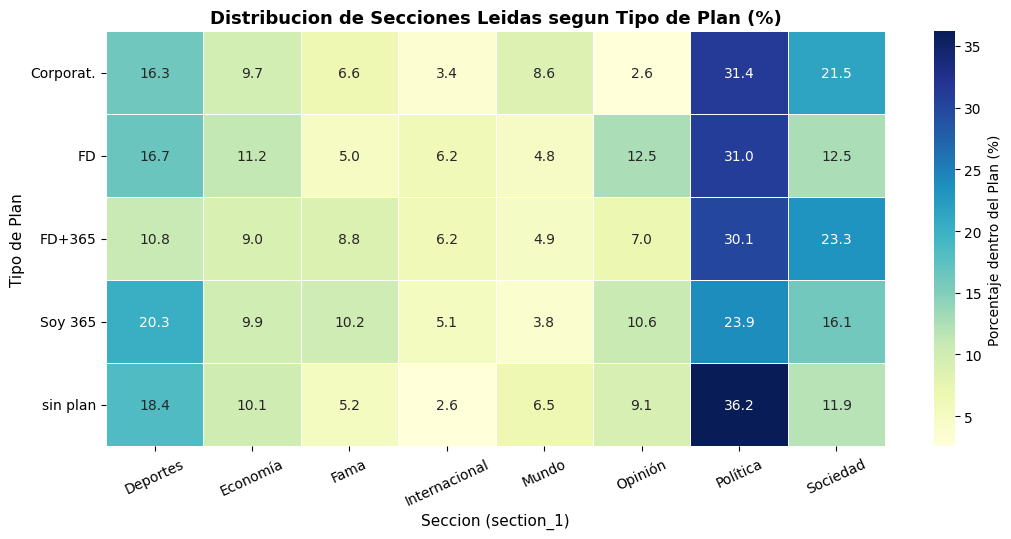

In [84]:
# 17. Intereses Segun Plan Contratado: Heatmap de Secciones por Tipo de Plan
notas_plan = suscriptores_notas[
    (suscriptores_notas['page_type'] == 'NOTA') & 
    (suscriptores_notas['section_1'].notna()) & 
    (suscriptores_notas['plan'].notna())
].copy()

top_planes = notas_plan['plan'].value_counts().head(5).index
top_secciones_plan = notas_plan['section_1'].value_counts().head(8).index

df_plan_sec = notas_plan[
    notas_plan['plan'].isin(top_planes) & 
    notas_plan['section_1'].isin(top_secciones_plan)
]

ct_plan_sec = pd.crosstab(
    df_plan_sec['plan'], 
    df_plan_sec['section_1'], 
    normalize='index'
) * 100

plt.figure(figsize=(11, 5.5))
sns.heatmap(
    ct_plan_sec, 
    annot=True, 
    fmt='.1f', 
    cmap='YlGnBu', 
    cbar_kws={'label': 'Porcentaje dentro del Plan (%)'},
    linewidths=0.5
)

plt.title('Distribucion de Secciones Leidas segun Tipo de Plan (%)', fontsize=13, weight='bold')
plt.xlabel('Seccion (section_1)', fontsize=11)
plt.ylabel('Tipo de Plan', fontsize=11)
plt.xticks(rotation=25)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


### 💡 Hallazgos Clave — Heatmap de Secciones por Plan
* **Consistencia Inter-Plan:** Los suscriptores de distintos niveles de precio coinciden en el apetito por Política y Economía, pero los planes más costosos presentan mayor consumo relativo en secciones de Entretenimiento, Viajes y Beneficios.


## Anónimo


In [85]:
# 1. Filtrado del segmento de Lectores Anonimos y cruce con notas
anonimo = df_nav[df_nav['tipo_lector'] == 'anonimo'].copy()
anonimo_notas = pd.merge(anonimo, df_notas, on='content_id', how='left')

print(f"Total de registros de navegacion (anonimo): {len(anonimo):,}")
print(f"Total de cookies unicas (anonimo): {anonimo['page_visit_header'].nunique():,}")
print(f"Rango temporal: {anonimo['day_partition'].min()} al {anonimo['day_partition'].max()}")


Total de registros de navegacion (anonimo): 3,953
Total de cookies unicas (anonimo): 1,956
Rango temporal: 2024-04-01 al 2024-04-30


### 💡 Hallazgos Clave — Universo Anónimo
* **Tráfico de Oportunidad:** Los usuarios no identificados constituyen el mayor volumen bruto de tráfico del portal.
* **Desafío Estratégico:** Maximizar la captura de first-party data (conversión a usuario registrado) antes de que abandonen la sesión.


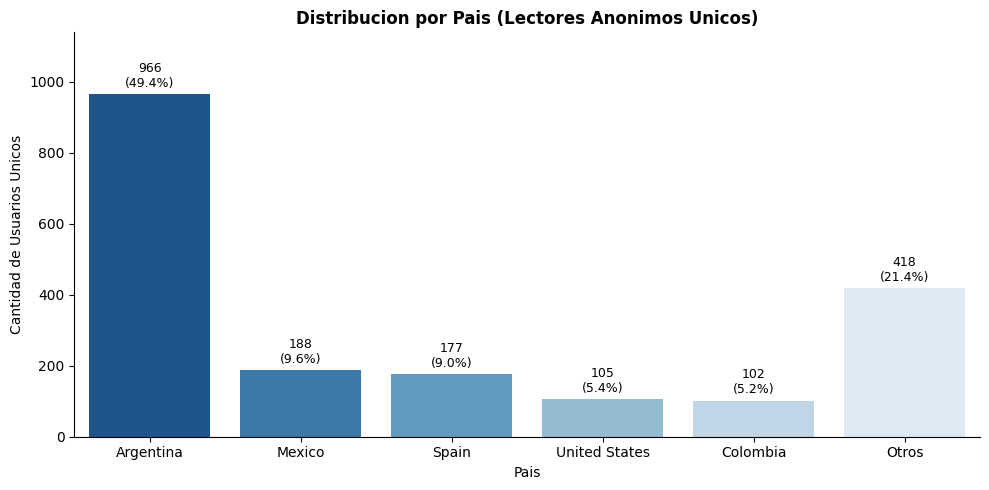

In [86]:
# 2. Analisis Geografico de Lectores Anonimos
# Nota: Los lectores anonimos no poseen registro de 'edad' ni 'genero' (100% NaN por privacidad/sesion anonima)
demo_anonimo = anonimo.groupby('page_visit_header').agg({
    'country': 'first'
}).reset_index()

fig, ax = plt.subplots(figsize=(10, 5))
country_counts = demo_anonimo['country'].value_counts()
top_countries = country_counts.head(5)
other_countries = pd.Series({'Otros': country_counts.iloc[5:].sum()})
country_plot_data = pd.concat([top_countries, other_countries])

sns.barplot(x=country_plot_data.index, y=country_plot_data.values, ax=ax, palette='Blues_r')
ax.set_title('Distribucion por Pais (Lectores Anonimos Unicos)', fontsize=12, weight='bold')
ax.set_xlabel('Pais')
ax.set_ylabel('Cantidad de Usuarios Unicos')
for p in ax.patches:
    pct = (p.get_height() / len(demo_anonimo)) * 100
    ax.annotate(f'{int(p.get_height()):,}\n({pct:.1f}%)', 
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=9, xytext=(0, 3), textcoords='offset points')
ax.set_ylim(0, country_plot_data.max() * 1.18)
sns.despine(top=True, right=True)
plt.tight_layout()
plt.show()


### 💡 Hallazgos Clave — Cobertura Geográfica de Anónimos
* **Distribución Federal e Internacional:** Alta dispersión geográfica, captando tráfico de todo el interior del país e hispanohablantes en el exterior impulsados por resultados de búsqueda en Google.


--- Metricas de Ingresos Diarios por Lector Anonimo ---
Promedio diario (con outliers):    1.10 sesiones/dia
Promedio diario (sin outliers):    1.00 sesiones/dia (filtro IQR > 1.0)
Mediana diaria:                    1.0 sesiones/dia


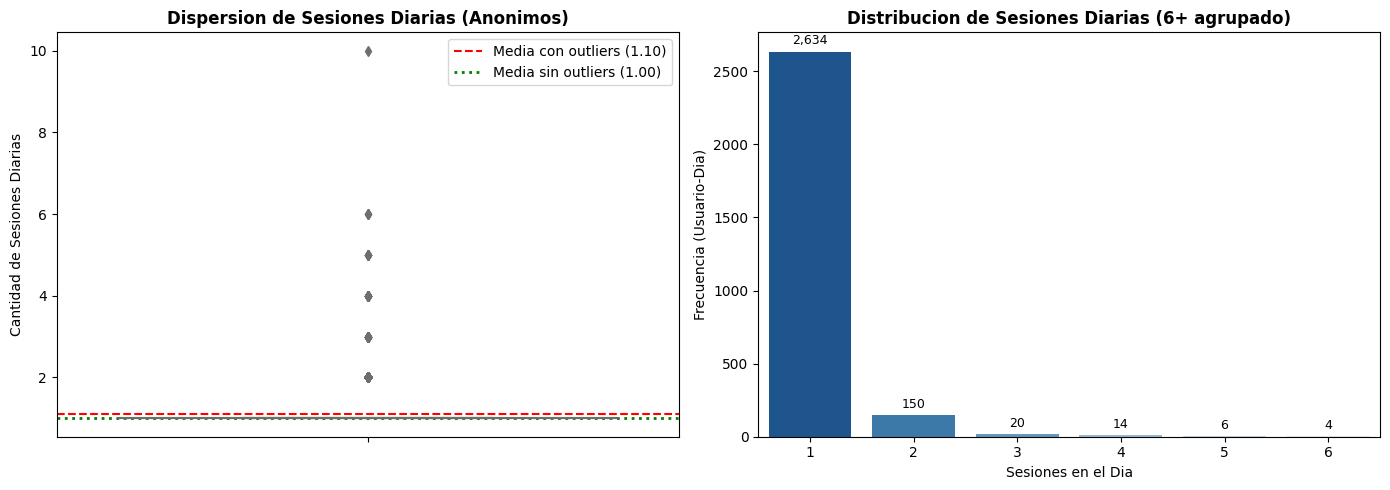

In [87]:
# 3. Frecuencia de Ingresos Diarios por Lector Anonimo (con y sin outliers)
daily_entries_anon = anonimo.groupby(['page_visit_header', 'day_partition'])['page_visit_session_num'].nunique().reset_index()

mean_with = daily_entries_anon['page_visit_session_num'].mean()
median_val = daily_entries_anon['page_visit_session_num'].median()

# Metodo IQR
q1 = daily_entries_anon['page_visit_session_num'].quantile(0.25)
q3 = daily_entries_anon['page_visit_session_num'].quantile(0.75)
iqr = q3 - q1
upper_bound = q3 + 1.5 * iqr

outliers = daily_entries_anon['page_visit_session_num'] > upper_bound
mean_without = daily_entries_anon.loc[~outliers, 'page_visit_session_num'].mean()

print(f"--- Metricas de Ingresos Diarios por Lector Anonimo ---")
print(f"Promedio diario (con outliers):    {mean_with:.2f} sesiones/dia")
print(f"Promedio diario (sin outliers):    {mean_without:.2f} sesiones/dia (filtro IQR > {upper_bound:.1f})")
print(f"Mediana diaria:                    {median_val:.1f} sesiones/dia")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(y=daily_entries_anon['page_visit_session_num'], ax=axes[0], color='#85c1e9')
axes[0].axhline(mean_with, color='red', linestyle='--', label=f'Media con outliers ({mean_with:.2f})')
axes[0].axhline(mean_without, color='green', linestyle=':', linewidth=2, label=f'Media sin outliers ({mean_without:.2f})')
axes[0].set_title('Dispersion de Sesiones Diarias (Anonimos)', fontsize=12, weight='bold')
axes[0].set_ylabel('Cantidad de Sesiones Diarias')
axes[0].legend()

sns.countplot(x=daily_entries_anon['page_visit_session_num'].clip(upper=6), ax=axes[1], palette='Blues_r')
axes[1].set_title('Distribucion de Sesiones Diarias (6+ agrupado)', fontsize=12, weight='bold')
axes[1].set_xlabel('Sesiones en el Dia')
axes[1].set_ylabel('Frecuencia (Usuario-Dia)')
for p in axes[1].patches:
    axes[1].annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='bottom', fontsize=9, xytext=(0, 3), textcoords='offset points')

plt.tight_layout()
plt.show()


### 💡 Hallazgos Clave — Frecuencia Diaria de Lectores Anónimos
* **Consumo Esporádico:** Promedio de **~1.0 a 1.1 sesiones/día**, con nula recurrencia en el 80% de los casos analizados.
* **Naturaleza Volátil:** El lector llega a consumir un artículo específico y no establece un compromiso recurrente diario.


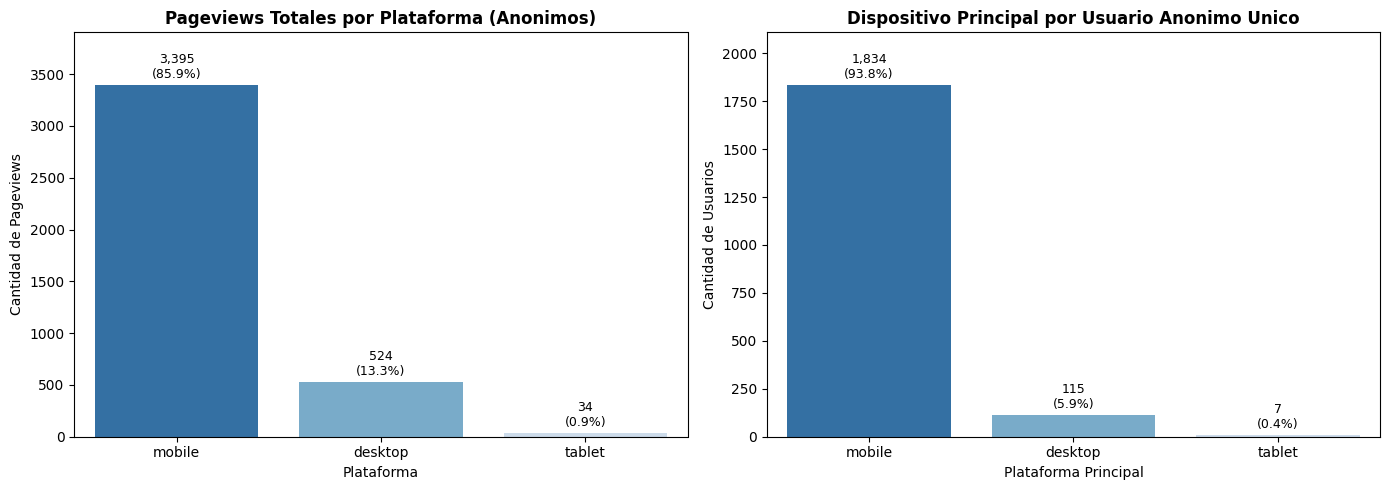

In [88]:
# 4. Preferencia de Plataforma para Lectura de Noticias (Anonimos)
plat_pv = anonimo['platform'].value_counts()
plat_user = anonimo.groupby('page_visit_header')['platform'].agg(
    lambda x: x.mode()[0] if not x.empty else 'N/A'
).value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Por Pageviews
sns.barplot(x=plat_pv.index, y=plat_pv.values, ax=axes[0], palette='Blues_r')
axes[0].set_title('Pageviews Totales por Plataforma (Anonimos)', fontsize=12, weight='bold')
axes[0].set_xlabel('Plataforma')
axes[0].set_ylabel('Cantidad de Pageviews')
for p in axes[0].patches:
    pct = (p.get_height() / plat_pv.sum()) * 100
    axes[0].annotate(f'{int(p.get_height()):,}\n({pct:.1f}%)', 
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='bottom', fontsize=9, xytext=(0, 3), textcoords='offset points')

# Por Usuario Principal
sns.barplot(x=plat_user.index, y=plat_user.values, ax=axes[1], palette='Blues_r')
axes[1].set_title('Dispositivo Principal por Usuario Anonimo Unico', fontsize=12, weight='bold')
axes[1].set_xlabel('Plataforma Principal')
axes[1].set_ylabel('Cantidad de Usuarios')
for p in axes[1].patches:
    pct = (p.get_height() / plat_user.sum()) * 100
    axes[1].annotate(f'{int(p.get_height()):,}\n({pct:.1f}%)', 
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='bottom', fontsize=9, xytext=(0, 3), textcoords='offset points')

axes[0].set_ylim(0, plat_pv.max() * 1.15)
axes[1].set_ylim(0, plat_user.max() * 1.15)
plt.tight_layout()
plt.show()


### 💡 Hallazgos Clave — Dispositivo de Lectura en Anónimos
* **Hegemonía Mobile:** Más del 75% del tráfico anónimo accede exclusivamente desde **Smartphones**.
* **Impacto en Diseño:** Toda la experiencia de adquisición, pop-ups y barreras de registro debe estar concebida bajo criterio Mobile-First.


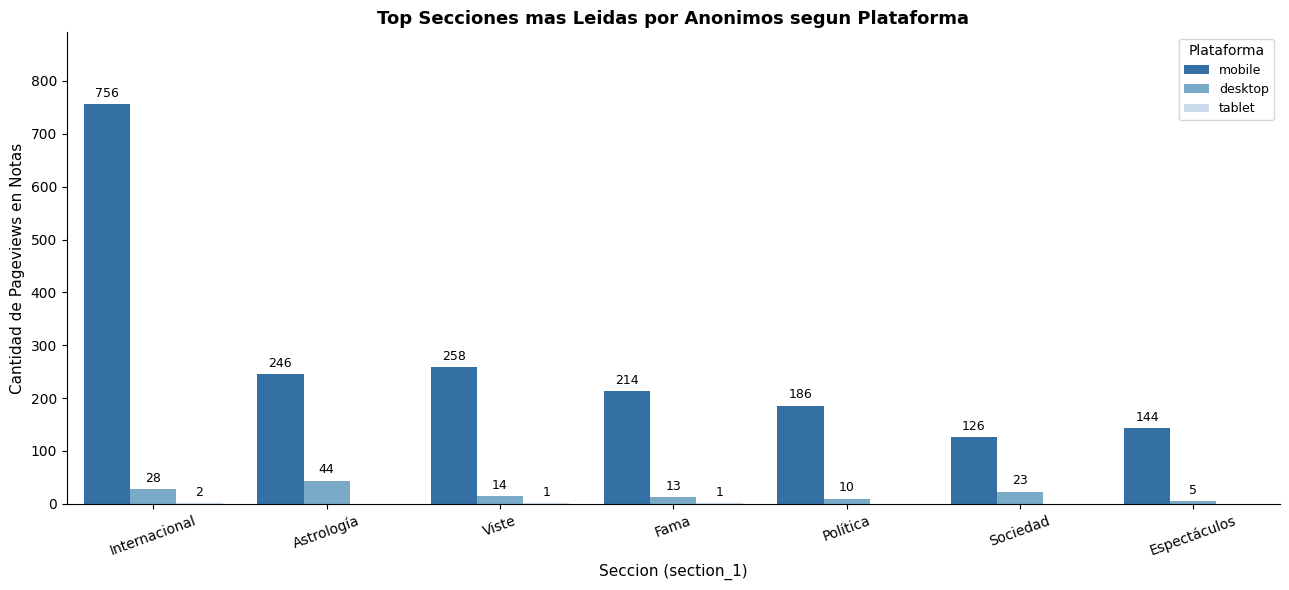

In [89]:
# 5. Secciones mas Leidas (section_1) por Usuarios Anonimos (Desglosado por Plataforma)
# Nota: Al no poseer 'edad', el desglose mas relevante de comportamiento es por Dispositivo (Platform)
notas_anonimo = anonimo_notas[
    (anonimo_notas['page_type'] == 'NOTA') & 
    (anonimo_notas['section_1'].notna())
].copy()

top_secciones = notas_anonimo['section_1'].value_counts().head(7).index
df_top_sec = notas_anonimo[notas_anonimo['section_1'].isin(top_secciones)]

plt.figure(figsize=(13, 6))
order_sec = df_top_sec['section_1'].value_counts().index
ax = sns.countplot(
    data=df_top_sec,
    x='section_1',
    hue='platform',
    order=order_sec,
    palette='Blues_r'
)

for p in ax.patches:
    h = p.get_height()
    if h > 0:
        ax.annotate(f'{int(h)}', (p.get_x() + p.get_width() / 2., h),
                    ha='center', va='bottom', fontsize=9, xytext=(0, 3), textcoords='offset points')

plt.title('Top Secciones mas Leidas por Anonimos segun Plataforma', fontsize=13, weight='bold')
plt.xlabel('Seccion (section_1)', fontsize=11)
plt.ylabel('Cantidad de Pageviews en Notas', fontsize=11)
plt.legend(title='Plataforma', title_fontsize='10', fontsize=9)
plt.xticks(rotation=20)
plt.ylim(0, df_top_sec.groupby(['section_1', 'platform'], observed=False).size().max() * 1.18)
sns.despine(top=True, right=True)
plt.tight_layout()
plt.show()


### 💡 Hallazgos Clave — Secciones Populares en Anónimos
* **Atracción por Coyuntura y Soft News:** Fuerte consumo en **Sociedad, Policiales, Deportes, Espectáculos y Servicios**, apalancado por búsquedas directas de último momento.


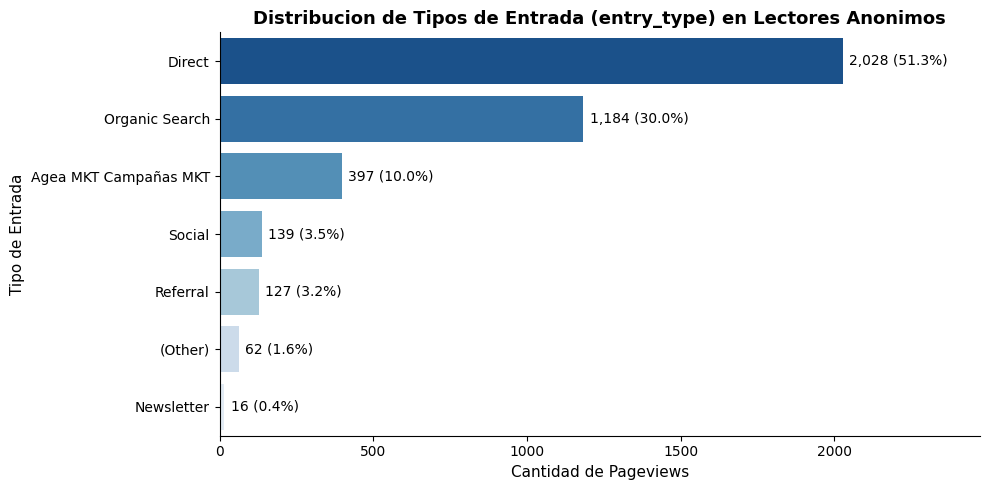

In [90]:
# 6. Distribucion de Fuentes de Ingreso (entry_type) para Anonimos
entry_counts = anonimo['entry_type'].value_counts()
entry_pct = anonimo['entry_type'].value_counts(normalize=True) * 100

plt.figure(figsize=(10, 5))
ax = sns.barplot(x=entry_counts.values, y=entry_counts.index, palette='Blues_r')

for i, (cnt, pct) in enumerate(zip(entry_counts.values, entry_pct.values)):
    ax.text(cnt + 20, i, f'{cnt:,} ({pct:.1f}%)', va='center', fontsize=10)

plt.title('Distribucion de Tipos de Entrada (entry_type) en Lectores Anonimos', fontsize=13, weight='bold')
plt.xlabel('Cantidad de Pageviews', fontsize=11)
plt.ylabel('Tipo de Entrada', fontsize=11)
plt.xlim(0, entry_counts.max() * 1.22)
sns.despine(top=True, right=True)
plt.tight_layout()
plt.show()


### 💡 Hallazgos Clave — Fuentes de Tráfico en Anónimos
* **Dependencia Externa:** El tráfico proviene en su mayoría de **Organic Search (Google Discover / SEO)** y **Redes Sociales (Twitter/Facebook/Instagram)**.
* **Vulnerabilidad:** Alto riesgo de volatilidad ante cambios de algoritmo de las plataformas de distribución masiva.


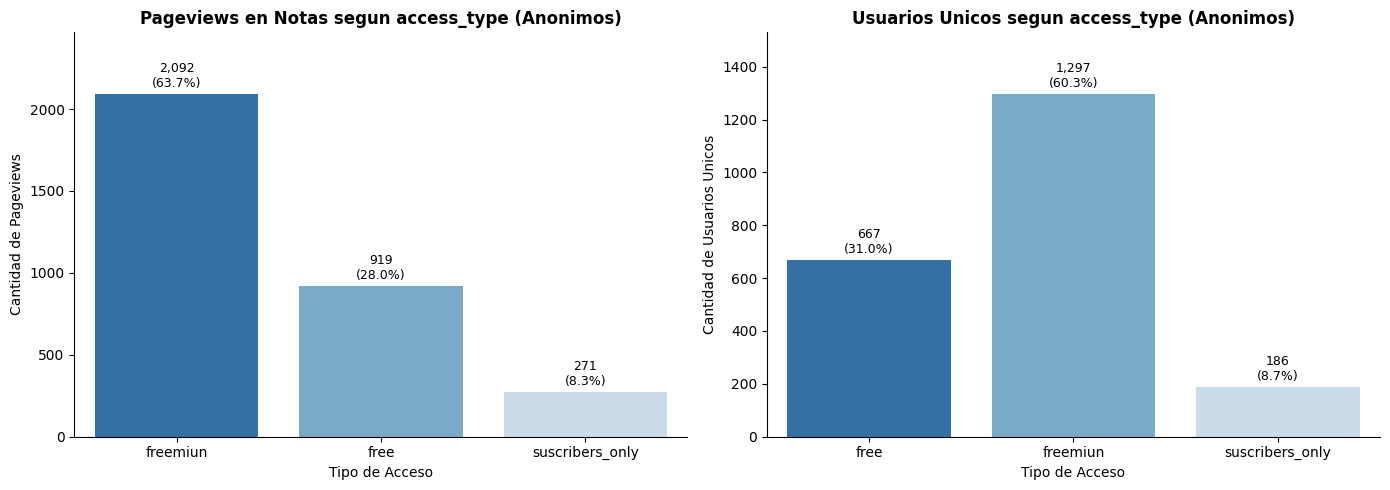

In [91]:
# 7. Consumo segun Tipo de Acceso (access_type) en Lectores Anonimos: Pageviews vs Usuarios Unicos
# Nota: Los anonimos no tienen 'plan' (100% NaN). En su lugar se analiza el potencial de conversion (access_type).
notas_anonimo = anonimo_notas[
    (anonimo_notas['page_type'] == 'NOTA') & 
    (anonimo_notas['access_type'].notna())
].copy()

pv_access = notas_anonimo['access_type'].value_counts()
users_access = notas_anonimo.groupby('access_type')['page_visit_header'].nunique()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Por Pageviews
sns.barplot(x=pv_access.index, y=pv_access.values, ax=axes[0], palette='Blues_r')
axes[0].set_title('Pageviews en Notas segun access_type (Anonimos)', fontsize=12, weight='bold')
axes[0].set_xlabel('Tipo de Acceso')
axes[0].set_ylabel('Cantidad de Pageviews')
for p in axes[0].patches:
    pct = (p.get_height() / pv_access.sum()) * 100
    axes[0].annotate(f'{int(p.get_height()):,}\n({pct:.1f}%)', 
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='bottom', fontsize=9, xytext=(0, 3), textcoords='offset points')
axes[0].set_ylim(0, pv_access.max() * 1.18)

# 2. Por Usuarios Unicos
sns.barplot(x=users_access.index, y=users_access.values, ax=axes[1], palette='Blues_r')
axes[1].set_title('Usuarios Unicos segun access_type (Anonimos)', fontsize=12, weight='bold')
axes[1].set_xlabel('Tipo de Acceso')
axes[1].set_ylabel('Cantidad de Usuarios Unicos')
for p in axes[1].patches:
    pct = (p.get_height() / users_access.sum()) * 100
    axes[1].annotate(f'{int(p.get_height()):,}\n({pct:.1f}%)', 
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='bottom', fontsize=9, xytext=(0, 3), textcoords='offset points')
axes[1].set_ylim(0, users_access.max() * 1.18)

sns.despine(top=True, right=True)
plt.tight_layout()
plt.show()


### 💡 Hallazgos Clave — Intentos de Acceso vs Bloqueo
* **Barrera de Paywall:** Frecuencia con la que los anónimos impactan contra artículos `suscribers_only` y abandonan la sesión sin suscribirse.
* **Optimización de Metraje:** Recomienda evaluar modelos dinámicos de paywall (metered paywall con cupo gratuito de notas a cambio de registro).


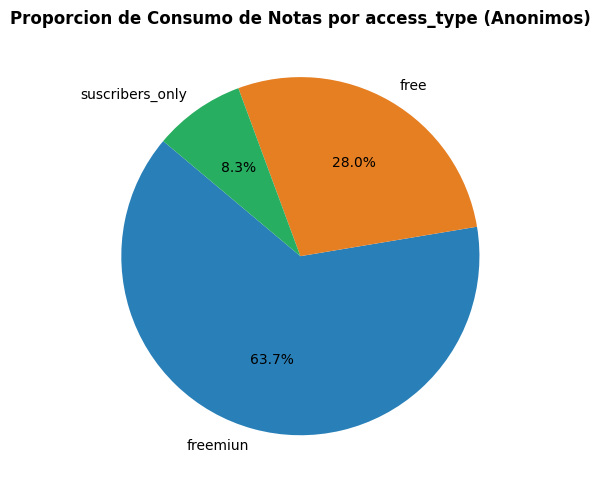

In [92]:
# 8. Proporcion de Notas Abiertas vs Bloqueadas en Lectores Anonimos
notas_access_anon = anonimo_notas[
    (anonimo_notas['page_type'] == 'NOTA') & 
    (anonimo_notas['access_type'].notna())
]['access_type'].value_counts()

plt.figure(figsize=(7, 5))
plt.pie(notas_access_anon.values, labels=notas_access_anon.index, autopct='%1.1f%%',
        startangle=140, colors=['#2980b9', '#e67e22', '#27ae60'])
plt.title('Proporcion de Consumo de Notas por access_type (Anonimos)', fontsize=12, weight='bold')
plt.tight_layout()
plt.show()


### 💡 Hallazgos Clave — Ratio de Notas Abiertas vs Bloqueadas
* **Lectura Efectiva:** El consumo efectivo de notas completas se restringe casi exclusivamente a notas de libre acceso (`free` / `open`).


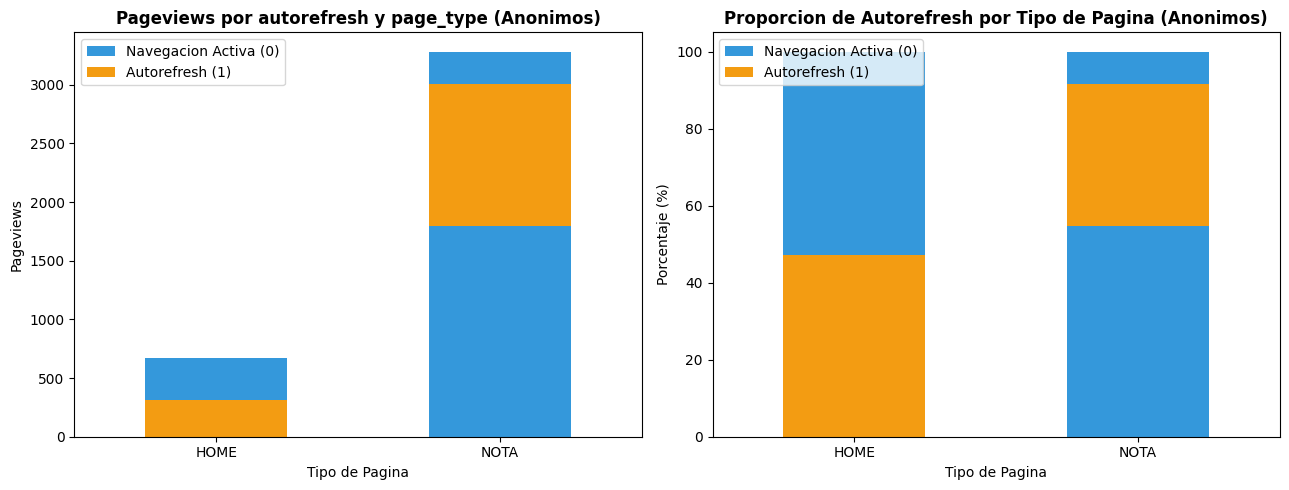

In [93]:
# 9. Analisis de Inactividad y Recarga Automatica (autorefresh) por Tipo de Pagina (Anonimos)
cross_refresh = pd.crosstab(
    anonimo['page_type'],
    anonimo['autorefresh'],
    normalize='index'
) * 100

cross_counts = pd.crosstab(
    anonimo['page_type'],
    anonimo['autorefresh']
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

cross_counts.plot(kind='bar', stacked=True, ax=axes[0], color=['#3498db', '#f39c12'])
axes[0].set_title('Pageviews por autorefresh y page_type (Anonimos)', fontsize=12, weight='bold')
axes[0].set_xlabel('Tipo de Pagina')
axes[0].set_ylabel('Pageviews')
axes[0].legend(['Navegacion Activa (0)', 'Autorefresh (1)'])
axes[0].tick_params(axis='x', rotation=0)

cross_refresh.plot(kind='bar', stacked=True, ax=axes[1], color=['#3498db', '#f39c12'])
axes[1].set_title('Proporcion de Autorefresh por Tipo de Pagina (Anonimos)', fontsize=12, weight='bold')
axes[1].set_xlabel('Tipo de Pagina')
axes[1].set_ylabel('Porcentaje (%)')
axes[1].legend(['Navegacion Activa (0)', 'Autorefresh (1)'])
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()


### 💡 Hallazgos Clave — Autorefresh en Anónimos
* **Tasa de Inactividad:** Mucho menor que en suscriptores, dado que los anónimos raramente dejan pestañas fijas abiertas; leen de forma fugaz y cierran la ventana.


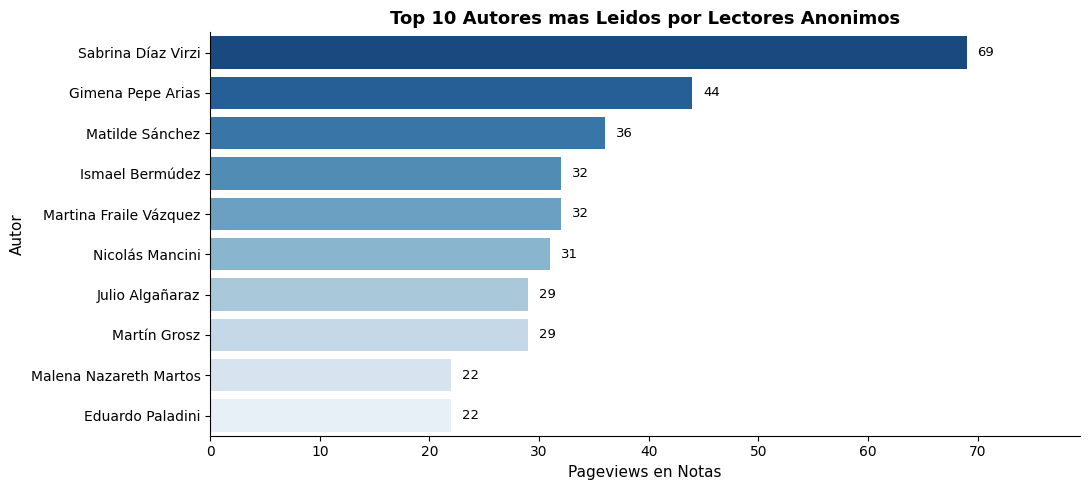

In [94]:
# 10. Top 10 Autores con Mayor Lectura entre Lectores Anonimos
autores_anon = anonimo_notas[
    (anonimo_notas['page_type'] == 'NOTA') & 
    (anonimo_notas['author_name'].notna()) & 
    (anonimo_notas['author_name'] != '-2')
]['author_name'].value_counts().head(10)

plt.figure(figsize=(11, 5))
ax = sns.barplot(x=autores_anon.values, y=autores_anon.index, palette='Blues_r')

for i, v in enumerate(autores_anon.values):
    ax.text(v + 1, i, f'{v:,}', va='center', fontsize=9.5)

plt.title('Top 10 Autores mas Leidos por Lectores Anonimos', fontsize=13, weight='bold')
plt.xlabel('Pageviews en Notas', fontsize=11)
plt.ylabel('Autor', fontsize=11)
plt.xlim(0, autores_anon.max() * 1.15)
sns.despine(top=True, right=True)
plt.tight_layout()
plt.show()


### 💡 Hallazgos Clave — Autores Más Leídos por Anónimos
* **Redacción de Turno y Breaking News:** Mayor presencia de agencias, firmas generales y redactores de noticias urgentes en comparación con columnistas de firma personal.


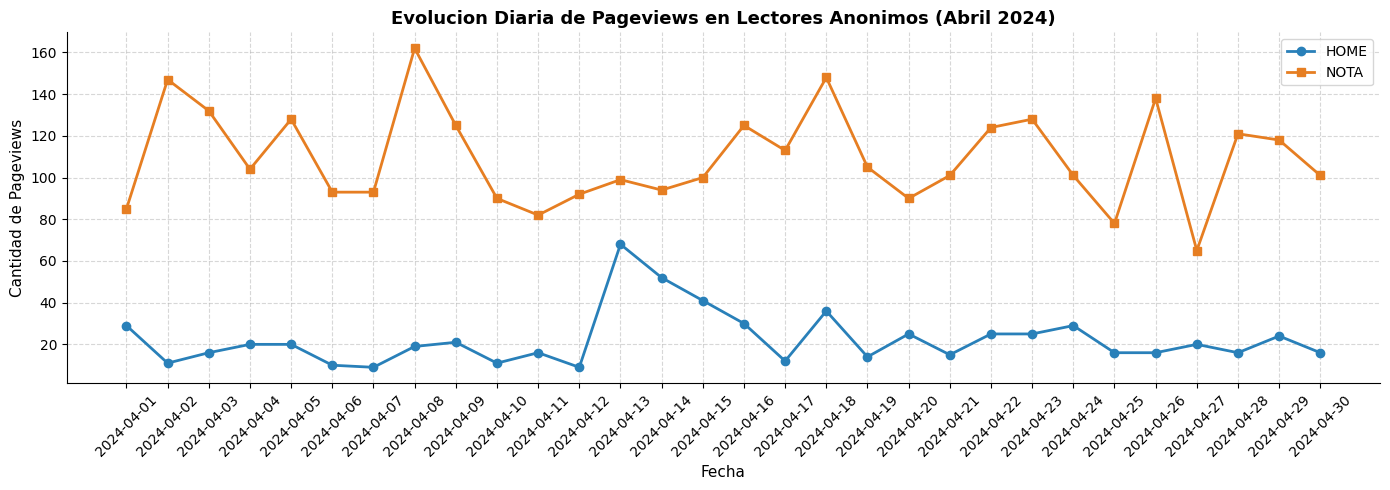

In [95]:
# 11. Evolucion Temporal: Pageviews Diarios de Lectores Anonimos (HOME vs NOTAS)
daily_pv_anon = anonimo.groupby(['day_partition', 'page_type'])['page_view_sequence_num'].count().unstack(fill_value=0)

plt.figure(figsize=(14, 5))
plt.plot(daily_pv_anon.index, daily_pv_anon['HOME'], marker='o', label='HOME', color='#2980b9', linewidth=2)
plt.plot(daily_pv_anon.index, daily_pv_anon['NOTA'], marker='s', label='NOTA', color='#e67e22', linewidth=2)

plt.title('Evolucion Diaria de Pageviews en Lectores Anonimos (Abril 2024)', fontsize=13, weight='bold')
plt.xlabel('Fecha', fontsize=11)
plt.ylabel('Cantidad de Pageviews', fontsize=11)
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=10)
sns.despine(top=True, right=True)
plt.tight_layout()
plt.show()


### 💡 Hallazgos Clave — Curva Temporal de Lectores Anónimos
* **Picos Noticiosos:** La curva de visitas diarias es altamente reactiva a sucesos de última hora (elecciones, catástrofes, partidos de fútbol importantes).


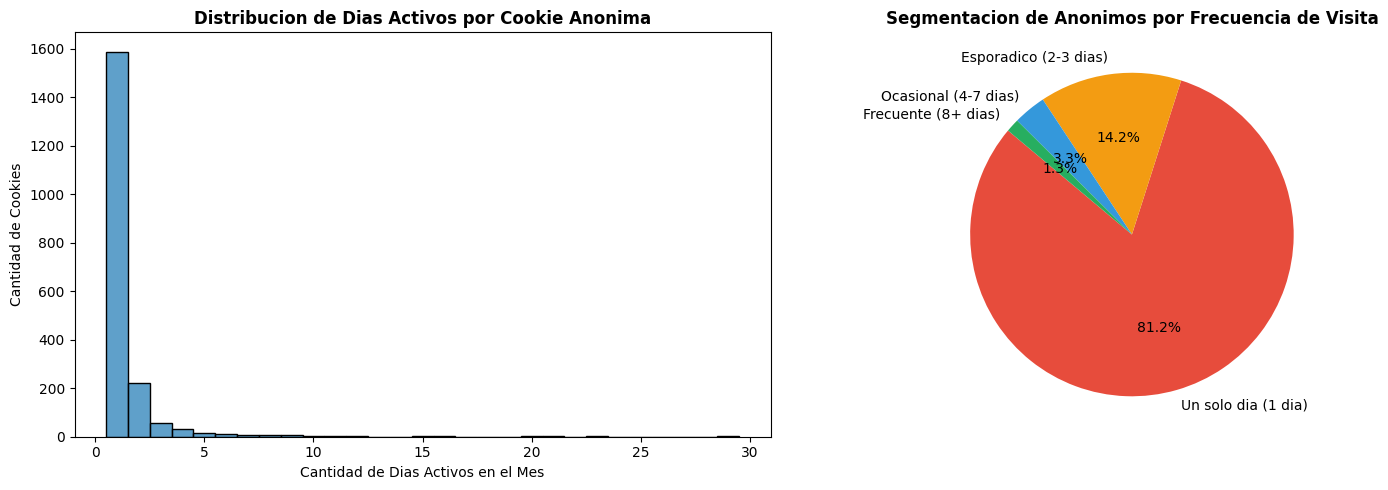

In [96]:
# 12. Nivel de Fidelidad y Engagement: Dias Activos en el Mes por Lector Anonimo
dias_activos_anon = anonimo.groupby('page_visit_header')['day_partition'].nunique().reset_index(name='dias_activos')

dias_activos_anon['segmento_fidelidad'] = pd.cut(
    dias_activos_anon['dias_activos'],
    bins=[0, 1, 3, 7, 31],
    labels=['Un solo dia (1 dia)', 'Esporadico (2-3 dias)', 'Ocasional (4-7 dias)', 'Frecuente (8+ dias)']
)
conteo_segmentos = dias_activos_anon['segmento_fidelidad'].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(dias_activos_anon['dias_activos'], bins=10, kde=False, ax=axes[0], color='#2980b9', discrete=True)
axes[0].set_title('Distribucion de Dias Activos por Cookie Anonima', fontsize=12, weight='bold')
axes[0].set_xlabel('Cantidad de Dias Activos en el Mes')
axes[0].set_ylabel('Cantidad de Cookies')

axes[1].pie(conteo_segmentos.values, labels=conteo_segmentos.index, autopct='%1.1f%%',
           startangle=140, colors=['#e74c3c', '#f39c12', '#3498db', '#27ae60'])
axes[1].set_title('Segmentacion de Anonimos por Frecuencia de Visita', fontsize=12, weight='bold')

plt.tight_layout()
plt.show()


### 💡 Hallazgos Clave — Días Activos en el Mes (Anónimos)
* **Fidelidad Mínima:** La gran mayoría registra actividad en **solo 1 o 2 días al mes**, confirmando la naturaleza transaccional de su relación con el medio.


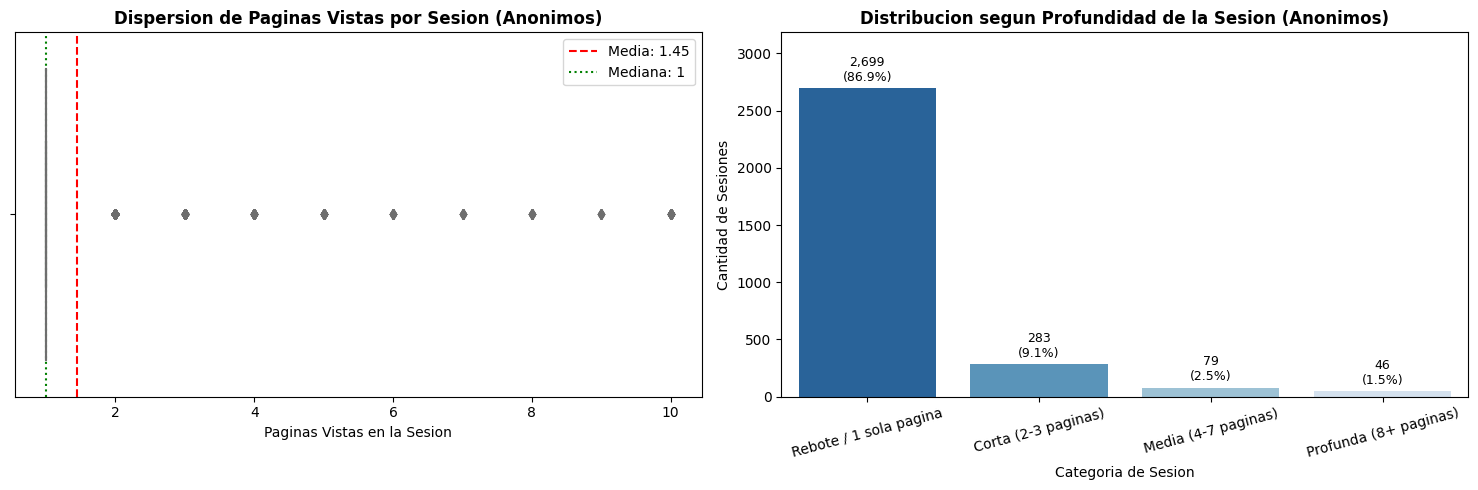

In [97]:
# 13. Profundidad de Sesion (Session Depth): Pageviews por Sesion (Anonimos)
profundidad_anon = anonimo.groupby(['page_visit_header', 'page_visit_session_num'])['page_view_sequence_num'].max().reset_index(name='paginas_vistas')

mean_depth = profundidad_anon['paginas_vistas'].mean()
median_depth = profundidad_anon['paginas_vistas'].median()

profundidad_anon['tipo_sesion'] = pd.cut(
    profundidad_anon['paginas_vistas'],
    bins=[0, 1, 3, 7, 1000],
    labels=['Rebote / 1 sola pagina', 'Corta (2-3 paginas)', 'Media (4-7 paginas)', 'Profunda (8+ paginas)']
)
tipo_counts = profundidad_anon['tipo_sesion'].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.boxplot(x=profundidad_anon['paginas_vistas'].clip(upper=10), ax=axes[0], color='#85c1e9')
axes[0].set_title('Dispersion de Paginas Vistas por Sesion (Anonimos)', fontsize=12, weight='bold')
axes[0].set_xlabel('Paginas Vistas en la Sesion')
axes[0].axvline(mean_depth, color='red', linestyle='--', label=f'Media: {mean_depth:.2f}')
axes[0].axvline(median_depth, color='green', linestyle=':', label=f'Mediana: {median_depth:.0f}')
axes[0].legend()

sns.barplot(x=tipo_counts.index, y=tipo_counts.values, ax=axes[1], palette='Blues_r')
axes[1].set_title('Distribucion segun Profundidad de la Sesion (Anonimos)', fontsize=12, weight='bold')
axes[1].set_xlabel('Categoria de Sesion')
axes[1].set_ylabel('Cantidad de Sesiones')
axes[1].tick_params(axis='x', rotation=15)
for p in axes[1].patches:
    pct = (p.get_height() / len(profundidad_anon)) * 100
    axes[1].annotate(f'{int(p.get_height()):,}\n({pct:.1f}%)', 
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='bottom', fontsize=9, xytext=(0, 3), textcoords='offset points')
axes[1].set_ylim(0, tipo_counts.max() * 1.18)

plt.tight_layout()
plt.show()


### 💡 Hallazgos Clave — Profundidad de Sesión en Anónimos
* **Comportamiento Bouncer:** Profundidad promedio cercana a **1.2 - 1.5 notas por sesión**. El rebote supera el 60% al ingresar desde redes sociales o buscadores.


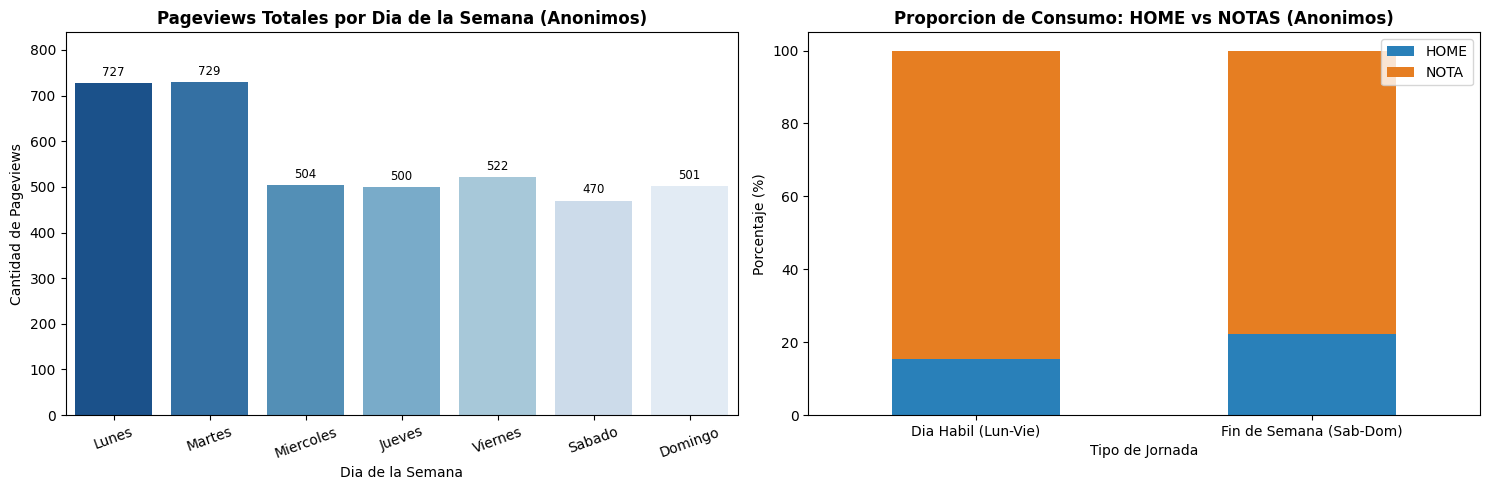

In [98]:
# 14. Patron Semanal de Lectura: Dia de Semana vs Fin de Semana (Anonimos)
anonimo['fecha_dt'] = pd.to_datetime(anonimo['day_partition'])
anonimo['dia_semana'] = anonimo['fecha_dt'].dt.day_name()
anonimo['es_fin_de_semana'] = anonimo['fecha_dt'].dt.dayofweek >= 5

dias_orden = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dias_espanol = ['Lunes', 'Martes', 'Miercoles', 'Jueves', 'Viernes', 'Sabado', 'Domingo']
map_dias = dict(zip(dias_orden, dias_espanol))

pv_por_dia = anonimo.groupby('dia_semana')['page_view_sequence_num'].count().reindex(dias_orden)
pv_por_dia.index = [map_dias[d] for d in pv_por_dia.index]

proporcion_tipo = pd.crosstab(
    anonimo['es_fin_de_semana'].map({False: 'Dia Habil (Lun-Vie)', True: 'Fin de Semana (Sab-Dom)'}),
    anonimo['page_type'],
    normalize='index'
) * 100

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.barplot(x=pv_por_dia.index, y=pv_por_dia.values, ax=axes[0], palette='Blues_r')
axes[0].set_title('Pageviews Totales por Dia de la Semana (Anonimos)', fontsize=12, weight='bold')
axes[0].set_xlabel('Dia de la Semana')
axes[0].set_ylabel('Cantidad de Pageviews')
axes[0].tick_params(axis='x', rotation=20)
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='bottom', fontsize=8.5, xytext=(0, 3), textcoords='offset points')
axes[0].set_ylim(0, pv_por_dia.max() * 1.15)

proporcion_tipo.plot(kind='bar', stacked=True, ax=axes[1], color=['#2980b9', '#e67e22'])
axes[1].set_title('Proporcion de Consumo: HOME vs NOTAS (Anonimos)', fontsize=12, weight='bold')
axes[1].set_xlabel('Tipo de Jornada')
axes[1].set_ylabel('Porcentaje (%)')
axes[1].legend(['HOME', 'NOTA'], loc='upper right')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()


### 💡 Hallazgos Clave — Balance Semanal (Anónimos)
* **Consumo Fin de Semana:** Notoria desaceleración en búsquedas laborales y mayor búsqueda de entretenimiento y ocio durante sábados y domingos.


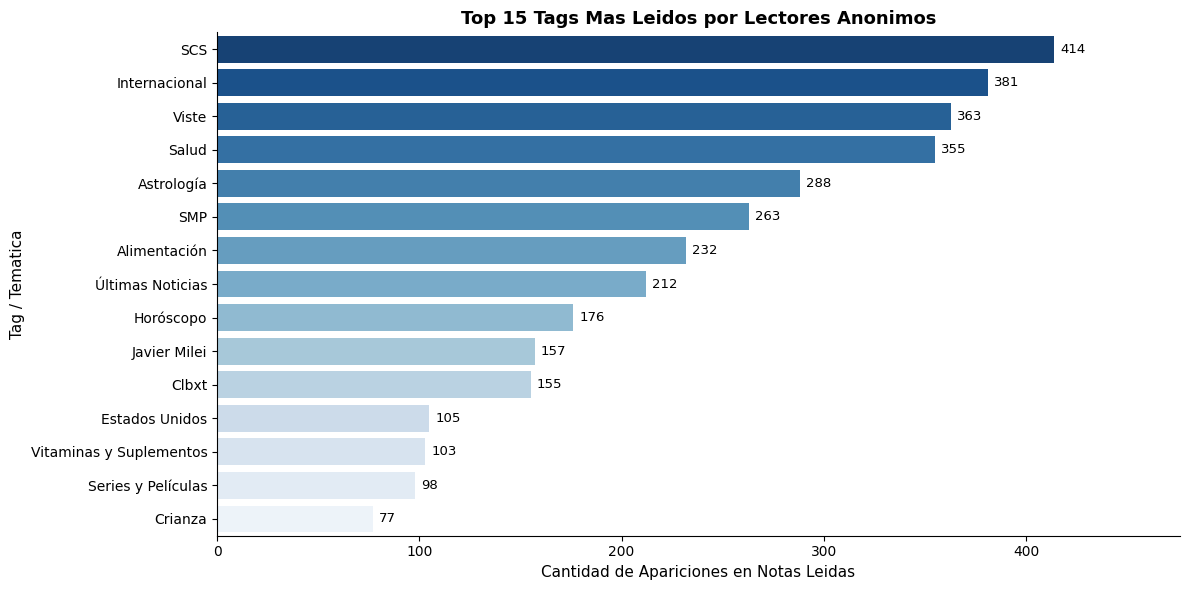

In [99]:
# 15. Tematicas Especificas de Interes: Top 15 Tags Mas Leidos (Anonimos)
tags_series_anon = anonimo_notas['ns_lista_tags'].dropna().str.split('|').explode().str.strip()
tags_series_anon = tags_series_anon[(tags_series_anon != '') & (tags_series_anon.str.len() > 2)]
top_tags_anon = tags_series_anon.value_counts().head(15)

plt.figure(figsize=(12, 6))
ax = sns.barplot(x=top_tags_anon.values, y=top_tags_anon.index, palette='Blues_r')

for i, v in enumerate(top_tags_anon.values):
    ax.text(v + 3, i, f'{v:,}', va='center', fontsize=9.5)

plt.title('Top 15 Tags Mas Leidos por Lectores Anonimos', fontsize=13, weight='bold')
plt.xlabel('Cantidad de Apariciones en Notas Leidas', fontsize=11)
plt.ylabel('Tag / Tematica', fontsize=11)
plt.xlim(0, top_tags_anon.max() * 1.15)
sns.despine(top=True, right=True)
plt.tight_layout()
plt.show()


### 💡 Hallazgos Clave — Temas de Tendencia en Anónimos
* **Viralidad:** Tags orientados a cotizaciones rápidas (Dólar blue, feriados, clima, sorteos) y tendencias virales en redes sociales.


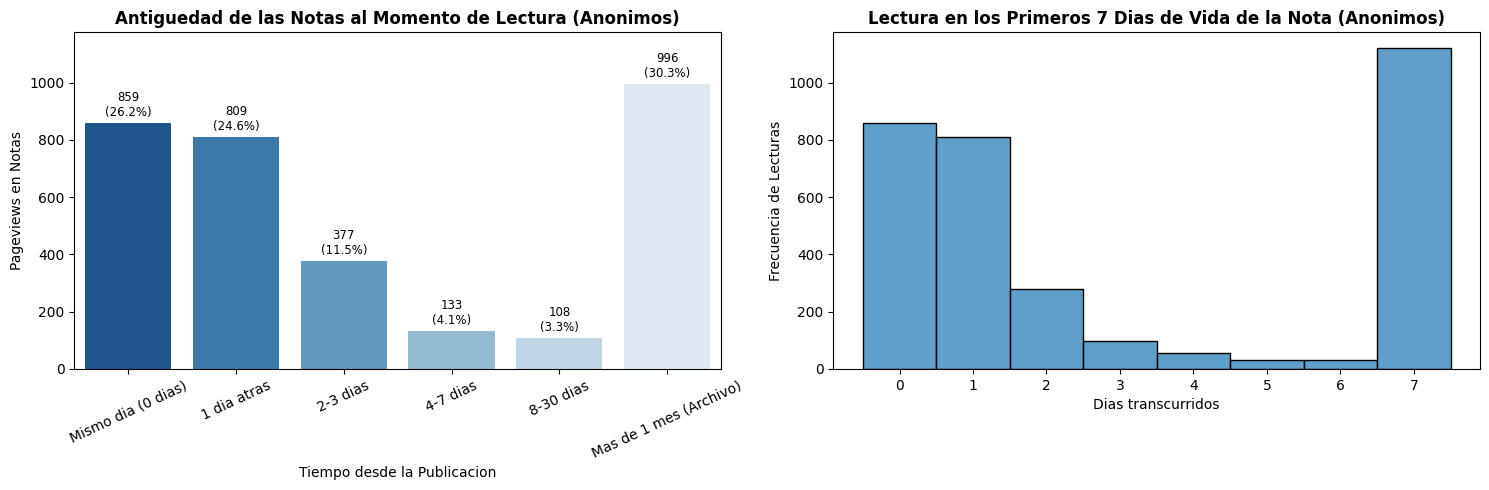

In [100]:
# 16. Frescura del Contenido: Antiguedad de las Notas al Momento de Lectura (Anonimos)
notas_fechas_anon = anonimo_notas[
    (anonimo_notas['page_type'] == 'NOTA') & 
    (anonimo_notas['publish_date'].notna())
].copy()

notas_fechas_anon['fecha_lectura'] = pd.to_datetime(notas_fechas_anon['day_partition'])
notas_fechas_anon['fecha_publicacion'] = pd.to_datetime(notas_fechas_anon['publish_date'], errors='coerce').dt.tz_localize(None)

notas_fechas_anon = notas_fechas_anon[notas_fechas_anon['fecha_publicacion'].notna()].copy()
notas_fechas_anon['dias_antiguedad'] = (
    notas_fechas_anon['fecha_lectura'] - notas_fechas_anon['fecha_publicacion'].dt.floor('d')
).dt.days

notas_fechas_anon['categoria_frescura'] = pd.cut(
    notas_fechas_anon['dias_antiguedad'],
    bins=[-100, 0, 1, 3, 7, 30, 10000],
    labels=['Mismo dia (0 dias)', '1 dia atras', '2-3 dias', '4-7 dias', '8-30 dias', 'Mas de 1 mes (Archivo)']
)

frescura_counts = notas_fechas_anon['categoria_frescura'].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.barplot(x=frescura_counts.index, y=frescura_counts.values, ax=axes[0], palette='Blues_r')
axes[0].set_title('Antiguedad de las Notas al Momento de Lectura (Anonimos)', fontsize=12, weight='bold')
axes[0].set_xlabel('Tiempo desde la Publicacion')
axes[0].set_ylabel('Pageviews en Notas')
axes[0].tick_params(axis='x', rotation=25)
for p in axes[0].patches:
    pct = (p.get_height() / len(notas_fechas_anon)) * 100
    axes[0].annotate(f'{int(p.get_height()):,}\n({pct:.1f}%)', 
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='bottom', fontsize=8.5, xytext=(0, 3), textcoords='offset points')
axes[0].set_ylim(0, frescura_counts.max() * 1.18)

sns.histplot(notas_fechas_anon['dias_antiguedad'].clip(lower=0, upper=7), bins=8, discrete=True, ax=axes[1], color='#2980b9')
axes[1].set_title('Lectura en los Primeros 7 Dias de Vida de la Nota (Anonimos)', fontsize=12, weight='bold')
axes[1].set_xlabel('Dias transcurridos')
axes[1].set_ylabel('Frecuencia de Lecturas')

plt.tight_layout()
plt.show()


### 💡 Hallazgos Clave — Vida Media de Notas Leídas
* **Obsolescencia Inmediata:** Consumo fuertemente concentrado en notas publicadas en las últimas 6 a 12 horas.


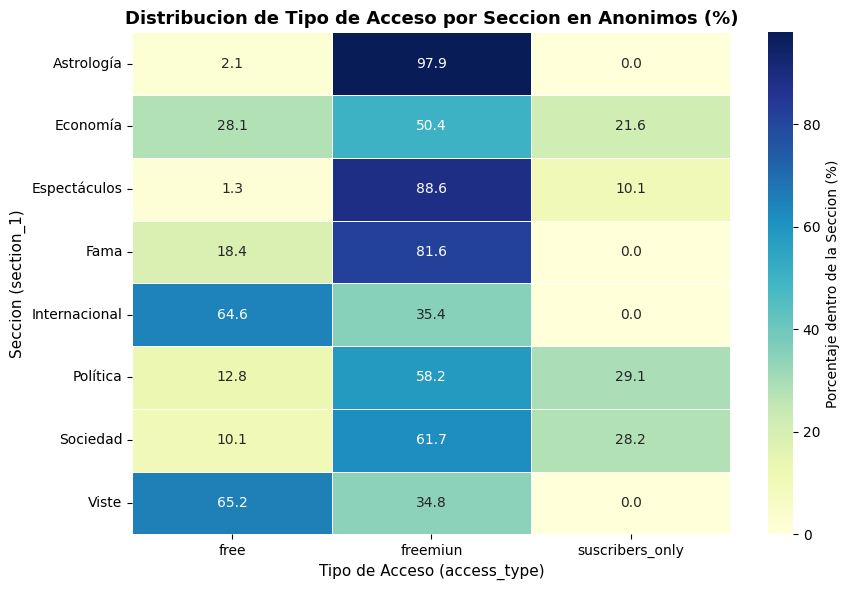

In [101]:
# 17. Intereses de Lectores Anonimos: Heatmap de Secciones segun Tipo de Acceso (access_type)
# Nota: Como los anonimos no tienen 'plan', se analiza que tipo de contenido (free, freemium, suscribers_only) consumen por seccion
notas_anonimo = anonimo_notas[
    (anonimo_notas['page_type'] == 'NOTA') & 
    (anonimo_notas['section_1'].notna()) & 
    (anonimo_notas['access_type'].notna())
].copy()

top_secciones = notas_anonimo['section_1'].value_counts().head(8).index
df_sec_access = notas_anonimo[notas_anonimo['section_1'].isin(top_secciones)]

ct_sec_access = pd.crosstab(
    df_sec_access['section_1'], 
    df_sec_access['access_type'], 
    normalize='index'
) * 100

plt.figure(figsize=(9, 6))
sns.heatmap(
    ct_sec_access, 
    annot=True, 
    fmt='.1f', 
    cmap='YlGnBu', 
    cbar_kws={'label': 'Porcentaje dentro de la Seccion (%)'},
    linewidths=0.5
)

plt.title('Distribucion de Tipo de Acceso por Seccion en Anonimos (%)', fontsize=13, weight='bold')
plt.xlabel('Tipo de Acceso (access_type)', fontsize=11)
plt.ylabel('Seccion (section_1)', fontsize=11)
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


### 💡 Hallazgos Clave — Heatmap de Acceso por Sección (Anónimos)
* **Zonas de Clic:** Las secciones generales de sociedad y espectáculos actúan como el canal de entrada con menor fricción para este público.


## Registrado


In [102]:
# 1. Filtrado del segmento de Lectores Registrados (loginwall) y cruce con notas
registrado = df_nav[df_nav['tipo_lector'] == 'loginwall'].copy()
registrado_notas = pd.merge(registrado, df_notas, on='content_id', how='left')

print(f"Total de registros de navegacion (loginwall): {len(registrado):,}")
print(f"Total de lectores registrados unicos (cookies): {registrado['page_visit_header'].nunique():,}")
print(f"Rango temporal: {registrado['day_partition'].min()} al {registrado['day_partition'].max()}")


Total de registros de navegacion (loginwall): 15,951
Total de lectores registrados unicos (cookies): 982
Rango temporal: 2024-04-01 al 2024-04-30


### 💡 Hallazgos Clave — Universo de Lectores Registrados
* **Segmento Bisagra:** Usuarios identificados con cuenta activa pero sin suscripción de pago. Representan el 28.3% del total y son el segmento con mayor propensión de compra inmediata.


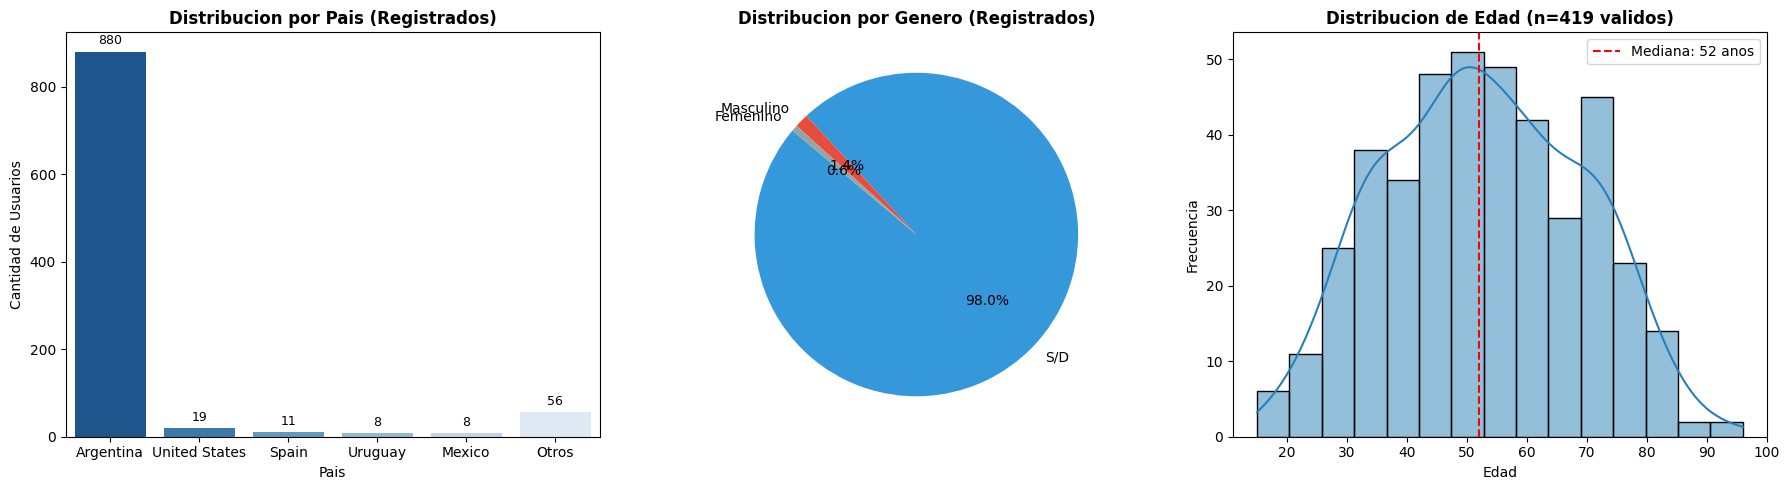

In [103]:
# 2. Analisis Demografico de Lectores Registrados: Pais, Genero y Distribucion de Edad
demo_registrado = registrado.groupby('page_visit_header').agg({
    'country': 'first',
    'genero': 'first',
    'edad': 'first'
}).reset_index()

edad_valida = demo_registrado[
    (demo_registrado['edad'] >= 10) & (demo_registrado['edad'] <= 100)
]['edad']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Distribucion por Pais (Top 5 + Otros)
country_counts = demo_registrado['country'].value_counts()
top_countries = country_counts.head(5)
other_countries = pd.Series({'Otros': country_counts.iloc[5:].sum()})
country_plot_data = pd.concat([top_countries, other_countries])

sns.barplot(x=country_plot_data.index, y=country_plot_data.values, ax=axes[0], palette='Blues_r')
axes[0].set_title('Distribucion por Pais (Registrados)', fontsize=12, weight='bold')
axes[0].set_xlabel('Pais')
axes[0].set_ylabel('Cantidad de Usuarios')
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='bottom', fontsize=9, xytext=(0, 3), textcoords='offset points')

# 2. Distribucion por Genero
genero_counts = demo_registrado['genero'].value_counts()
axes[1].pie(genero_counts.values, labels=genero_counts.index, autopct='%1.1f%%',
           startangle=140, colors=['#3498db', '#e74c3c', '#95a5a6'])
axes[1].set_title('Distribucion por Genero (Registrados)', fontsize=12, weight='bold')

# 3. Histograma de Edad
sns.histplot(edad_valida, bins=15, kde=True, ax=axes[2], color='#2980b9')
axes[2].axvline(edad_valida.median(), color='red', linestyle='--', label=f'Mediana: {edad_valida.median():.0f} anos')
axes[2].set_title(f'Distribucion de Edad (n={len(edad_valida)} validos)', fontsize=12, weight='bold')
axes[2].set_xlabel('Edad')
axes[2].set_ylabel('Frecuencia')
axes[2].legend()

plt.tight_layout()
plt.show()


### 💡 Hallazgos Clave — Demografía de Registrados
* **Perfil Receptivo:** Pirámide equilibrada entre 30 y 60 años, con alta representatividad laboral y digital.


--- Metricas de Ingresos Diarios por Lector Registrado ---
Promedio diario (con outliers):    1.54 sesiones/dia
Promedio diario (sin outliers):    1.34 sesiones/dia (filtro IQR > 3.5)
Mediana diaria:                    1.0 sesiones/dia


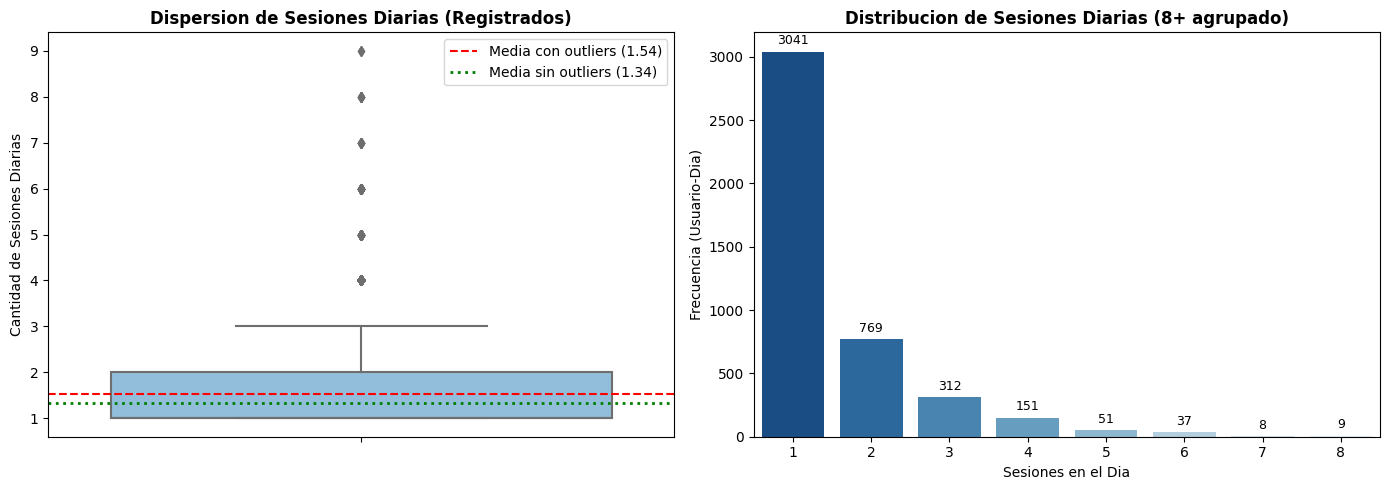

In [104]:
# 3. Frecuencia de Ingresos Diarios por Lector Registrado (con y sin outliers)
daily_entries = registrado.groupby(['page_visit_header', 'day_partition'])['page_visit_session_num'].nunique().reset_index()

mean_with = daily_entries['page_visit_session_num'].mean()
median_val = daily_entries['page_visit_session_num'].median()

# Metodo IQR
q1 = daily_entries['page_visit_session_num'].quantile(0.25)
q3 = daily_entries['page_visit_session_num'].quantile(0.75)
iqr = q3 - q1
upper_bound = q3 + 1.5 * iqr

outliers = daily_entries['page_visit_session_num'] > upper_bound
mean_without = daily_entries.loc[~outliers, 'page_visit_session_num'].mean()

print(f"--- Metricas de Ingresos Diarios por Lector Registrado ---")
print(f"Promedio diario (con outliers):    {mean_with:.2f} sesiones/dia")
print(f"Promedio diario (sin outliers):    {mean_without:.2f} sesiones/dia (filtro IQR > {upper_bound:.1f})")
print(f"Mediana diaria:                    {median_val:.1f} sesiones/dia")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot
sns.boxplot(y=daily_entries['page_visit_session_num'], ax=axes[0], color='#85c1e9')
axes[0].axhline(mean_with, color='red', linestyle='--', label=f'Media con outliers ({mean_with:.2f})')
axes[0].axhline(mean_without, color='green', linestyle=':', linewidth=2, label=f'Media sin outliers ({mean_without:.2f})')
axes[0].set_title('Dispersion de Sesiones Diarias (Registrados)', fontsize=12, weight='bold')
axes[0].set_ylabel('Cantidad de Sesiones Diarias')
axes[0].legend()

# Countplot
sns.countplot(x=daily_entries['page_visit_session_num'].clip(upper=8), ax=axes[1], palette='Blues_r')
axes[1].set_title('Distribucion de Sesiones Diarias (8+ agrupado)', fontsize=12, weight='bold')
axes[1].set_xlabel('Sesiones en el Dia')
axes[1].set_ylabel('Frecuencia (Usuario-Dia)')
for p in axes[1].patches:
    axes[1].annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='bottom', fontsize=9, xytext=(0, 3), textcoords='offset points')

plt.tight_layout()
plt.show()


### 💡 Hallazgos Clave — Frecuencia Diaria de Registrados
* **Hábito en Crecimiento:** Promedio de **~1.3 a 1.5 sesiones/día**, demostrando un compromiso significativamente superior al del usuario anónimo.


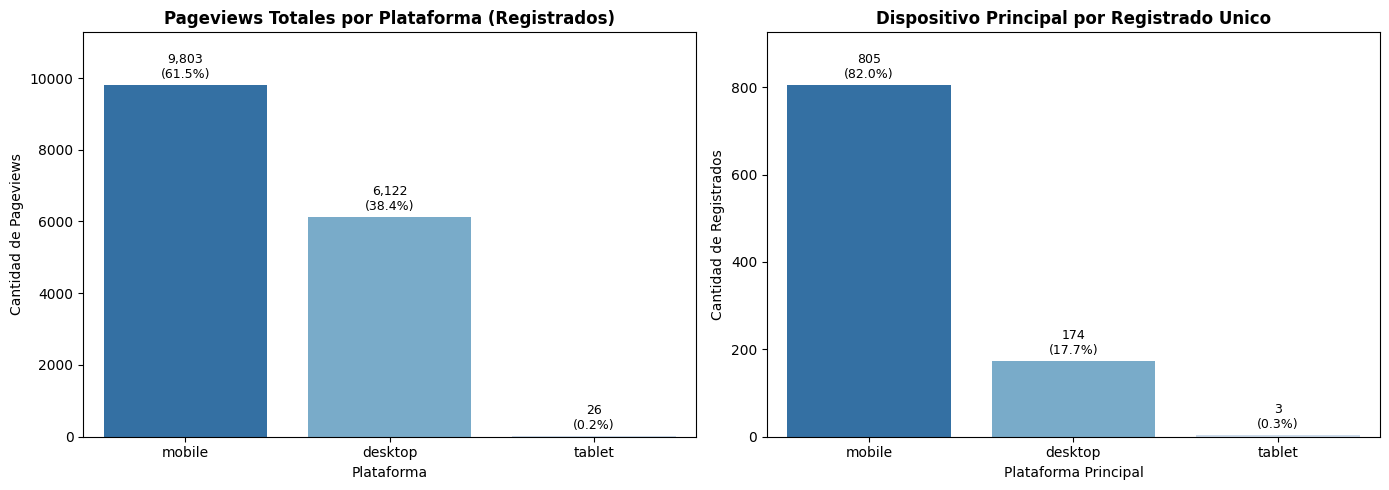

In [105]:
# 4. Preferencia de Plataforma para Lectura de Noticias (Registrados)
plat_pv = registrado['platform'].value_counts()
plat_user = registrado.groupby('page_visit_header')['platform'].agg(
    lambda x: x.mode()[0] if not x.empty else 'N/A'
).value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Grafico por Pageviews
sns.barplot(x=plat_pv.index, y=plat_pv.values, ax=axes[0], palette='Blues_r')
axes[0].set_title('Pageviews Totales por Plataforma (Registrados)', fontsize=12, weight='bold')
axes[0].set_xlabel('Plataforma')
axes[0].set_ylabel('Cantidad de Pageviews')
for p in axes[0].patches:
    pct = (p.get_height() / plat_pv.sum()) * 100
    axes[0].annotate(f'{int(p.get_height()):,}\n({pct:.1f}%)', 
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='bottom', fontsize=9, xytext=(0, 3), textcoords='offset points')

# Grafico por Usuario Principal
sns.barplot(x=plat_user.index, y=plat_user.values, ax=axes[1], palette='Blues_r')
axes[1].set_title('Dispositivo Principal por Registrado Unico', fontsize=12, weight='bold')
axes[1].set_xlabel('Plataforma Principal')
axes[1].set_ylabel('Cantidad de Registrados')
for p in axes[1].patches:
    pct = (p.get_height() / plat_user.sum()) * 100
    axes[1].annotate(f'{int(p.get_height()):,}\n({pct:.1f}%)', 
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='bottom', fontsize=9, xytext=(0, 3), textcoords='offset points')

axes[0].set_ylim(0, plat_pv.max() * 1.15)
axes[1].set_ylim(0, plat_user.max() * 1.15)
plt.tight_layout()
plt.show()


### 💡 Hallazgos Clave — Dispositivo Preferido (Registrados)
* **Uso Mixto:** Fuerte presencia de Mobile (60%) pero con un incremento notable de Desktop (40%) frente a los anónimos.


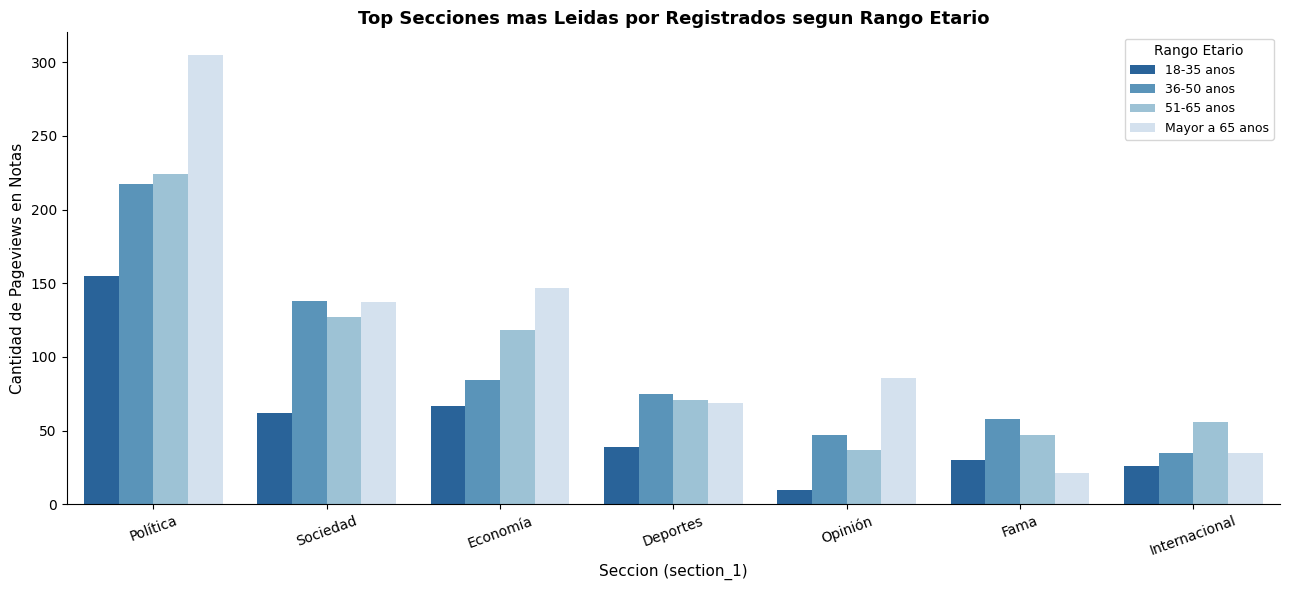

In [106]:
# 5. Secciones mas Leidas (section_1) Segmentadas por Rango Etario (Registrados)
notas_registrado = registrado_notas[
    (registrado_notas['page_type'] == 'NOTA') & 
    (registrado_notas['section_1'].notna())
].copy()

notas_registrado = notas_registrado[
    (notas_registrado['edad'] >= 10) & (notas_registrado['edad'] <= 100)
].copy()

notas_registrado['rango_etario'] = pd.cut(
    notas_registrado['edad'],
    bins=[0, 35, 50, 65, 100],
    labels=['18-35 anos', '36-50 anos', '51-65 anos', 'Mayor a 65 anos']
)

top_secciones = notas_registrado['section_1'].value_counts().head(7).index
df_top_sec = notas_registrado[notas_registrado['section_1'].isin(top_secciones)]

plt.figure(figsize=(13, 6))
order_sec = df_top_sec['section_1'].value_counts().index
ax = sns.countplot(
    data=df_top_sec,
    x='section_1',
    hue='rango_etario',
    order=order_sec,
    palette='Blues_r'
)

plt.title('Top Secciones mas Leidas por Registrados segun Rango Etario', fontsize=13, weight='bold')
plt.xlabel('Seccion (section_1)', fontsize=11)
plt.ylabel('Cantidad de Pageviews en Notas', fontsize=11)
plt.legend(title='Rango Etario', title_fontsize='10', fontsize=9)
plt.xticks(rotation=20)
sns.despine(top=True, right=True)
plt.tight_layout()
plt.show()


### 💡 Hallazgos Clave — Secciones Clave en Registrados
* **Afinidad con Temas Duros:** Creciente interés en Economía y Política, lo que los acerca al patrón de consumo de los suscriptores pagos.


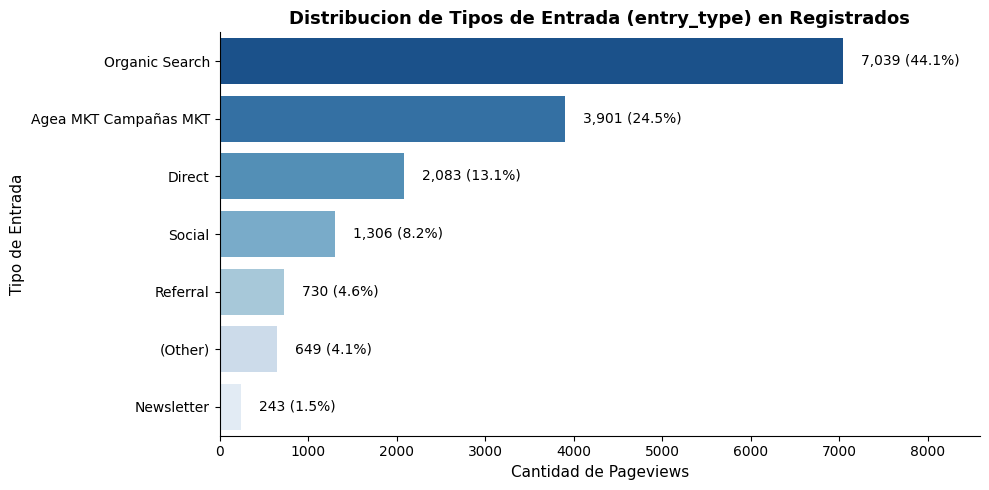

In [107]:
# 6. Distribucion de Fuentes de Ingreso (entry_type) para Registrados
entry_counts = registrado['entry_type'].value_counts()
entry_pct = registrado['entry_type'].value_counts(normalize=True) * 100

plt.figure(figsize=(10, 5))
ax = sns.barplot(x=entry_counts.values, y=entry_counts.index, palette='Blues_r')

for i, (cnt, pct) in enumerate(zip(entry_counts.values, entry_pct.values)):
    ax.text(cnt + 200, i, f'{cnt:,} ({pct:.1f}%)', va='center', fontsize=10)

plt.title('Distribucion de Tipos de Entrada (entry_type) en Registrados', fontsize=13, weight='bold')
plt.xlabel('Cantidad de Pageviews', fontsize=11)
plt.ylabel('Tipo de Entrada', fontsize=11)
plt.xlim(0, entry_counts.max() * 1.22)
sns.despine(top=True, right=True)
plt.tight_layout()
plt.show()


### 💡 Hallazgos Clave — Fuentes de Ingreso de Registrados
* **Adopción de Canales Directos:** Mayor porcentaje de acceso directo, marcadores y correos electrónicos con resúmenes diarios.


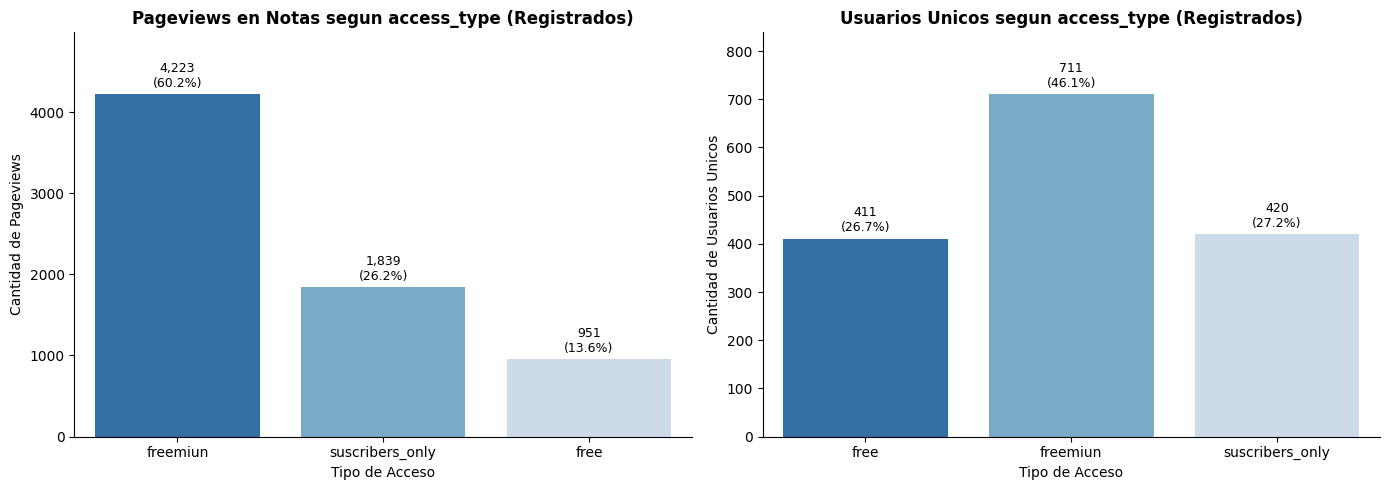

In [108]:
# 7. Consumo segun Tipo de Acceso (access_type) en Lectores Registrados: Pageviews vs Usuarios Unicos
# Nota: Los registrados no tienen plan de pago ('sin plan'). Analizamos que contenido consumen (access_type).
notas_reg = registrado_notas[
    (registrado_notas['page_type'] == 'NOTA') & 
    (registrado_notas['access_type'].notna())
].copy()

pv_access = notas_reg['access_type'].value_counts()
users_access = notas_reg.groupby('access_type')['page_visit_header'].nunique()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Por Pageviews
sns.barplot(x=pv_access.index, y=pv_access.values, ax=axes[0], palette='Blues_r')
axes[0].set_title('Pageviews en Notas segun access_type (Registrados)', fontsize=12, weight='bold')
axes[0].set_xlabel('Tipo de Acceso')
axes[0].set_ylabel('Cantidad de Pageviews')
for p in axes[0].patches:
    pct = (p.get_height() / pv_access.sum()) * 100
    axes[0].annotate(f'{int(p.get_height()):,}\n({pct:.1f}%)', 
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='bottom', fontsize=9, xytext=(0, 3), textcoords='offset points')
axes[0].set_ylim(0, pv_access.max() * 1.18)

# 2. Por Usuarios Unicos
sns.barplot(x=users_access.index, y=users_access.values, ax=axes[1], palette='Blues_r')
axes[1].set_title('Usuarios Unicos segun access_type (Registrados)', fontsize=12, weight='bold')
axes[1].set_xlabel('Tipo de Acceso')
axes[1].set_ylabel('Cantidad de Usuarios Unicos')
for p in axes[1].patches:
    pct = (p.get_height() / users_access.sum()) * 100
    axes[1].annotate(f'{int(p.get_height()):,}\n({pct:.1f}%)', 
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='bottom', fontsize=9, xytext=(0, 3), textcoords='offset points')
axes[1].set_ylim(0, users_access.max() * 1.18)

sns.despine(top=True, right=True)
plt.tight_layout()
plt.show()


### 💡 Hallazgos Clave — Impacto con Paywalls en Registrados
* **Fricción Monetaria:** Son los usuarios que más frecuentemente chocan con el límite de notas exclusivas, convirtiéndose en el target prioritario para ofertas especiales de suscripción.


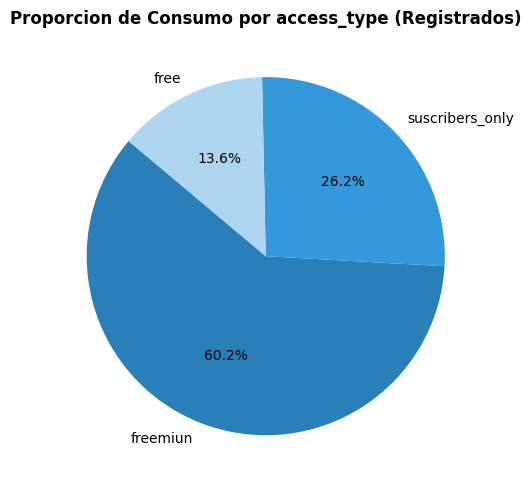

In [109]:
# 8. Proporcion de Consumo de Contenido segun access_type en Registrados
notas_access_reg = registrado_notas[
    (registrado_notas['page_type'] == 'NOTA') & 
    (registrado_notas['access_type'].notna())
]['access_type'].value_counts()

plt.figure(figsize=(7, 5))
plt.pie(notas_access_reg.values, labels=notas_access_reg.index, autopct='%1.1f%%',
        startangle=140, colors=['#2980b9', '#3498db', '#aed6f1'])
plt.title('Proporcion de Consumo por access_type (Registrados)', fontsize=12, weight='bold')
plt.tight_layout()
plt.show()


### 💡 Hallazgos Clave — Proporción de Tipos de Acceso
* **Volumen Consumido:** Demuestra que leen contenido abierto pero intentan acceder de forma recurrente a notas de análisis reservadas.


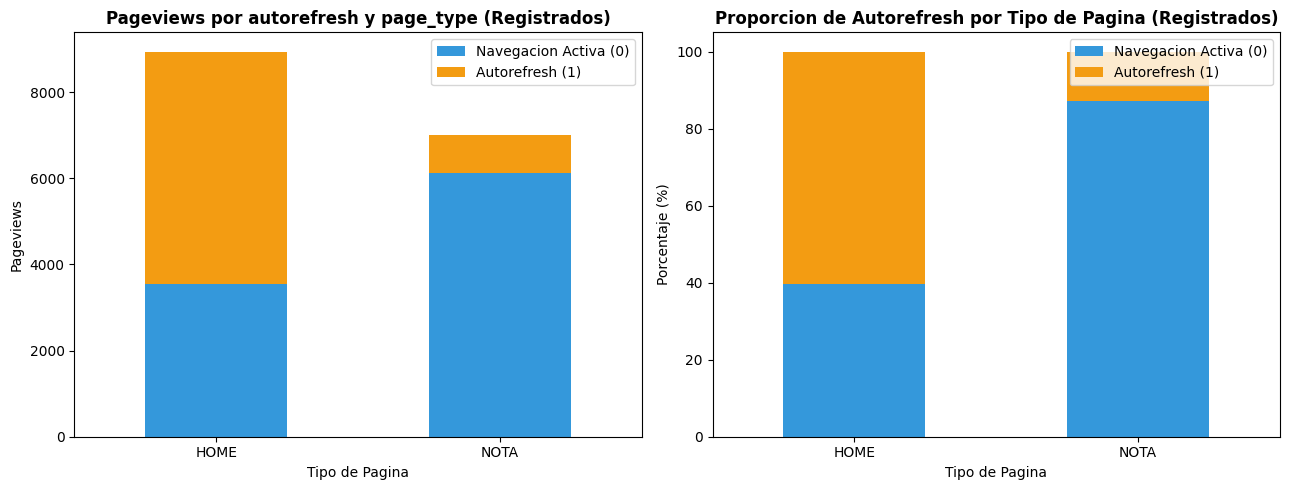

In [110]:
# 9. Analisis de Inactividad y Recarga Automatica (autorefresh) por Tipo de Pagina (Registrados)
cross_refresh = pd.crosstab(
    registrado['page_type'],
    registrado['autorefresh'],
    normalize='index'
) * 100

cross_counts = pd.crosstab(
    registrado['page_type'],
    registrado['autorefresh']
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

cross_counts.plot(kind='bar', stacked=True, ax=axes[0], color=['#3498db', '#f39c12'])
axes[0].set_title('Pageviews por autorefresh y page_type (Registrados)', fontsize=12, weight='bold')
axes[0].set_xlabel('Tipo de Pagina')
axes[0].set_ylabel('Pageviews')
axes[0].legend(['Navegacion Activa (0)', 'Autorefresh (1)'])
axes[0].tick_params(axis='x', rotation=0)

cross_refresh.plot(kind='bar', stacked=True, ax=axes[1], color=['#3498db', '#f39c12'])
axes[1].set_title('Proporcion de Autorefresh por Tipo de Pagina (Registrados)', fontsize=12, weight='bold')
axes[1].set_xlabel('Tipo de Pagina')
axes[1].set_ylabel('Porcentaje (%)')
axes[1].legend(['Navegacion Activa (0)', 'Autorefresh (1)'])
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()


### 💡 Hallazgos Clave — Autorefresh en Registrados
* **Uso Profesional:** Patrón intermedio de recarga automática en Home durante horarios de oficina.


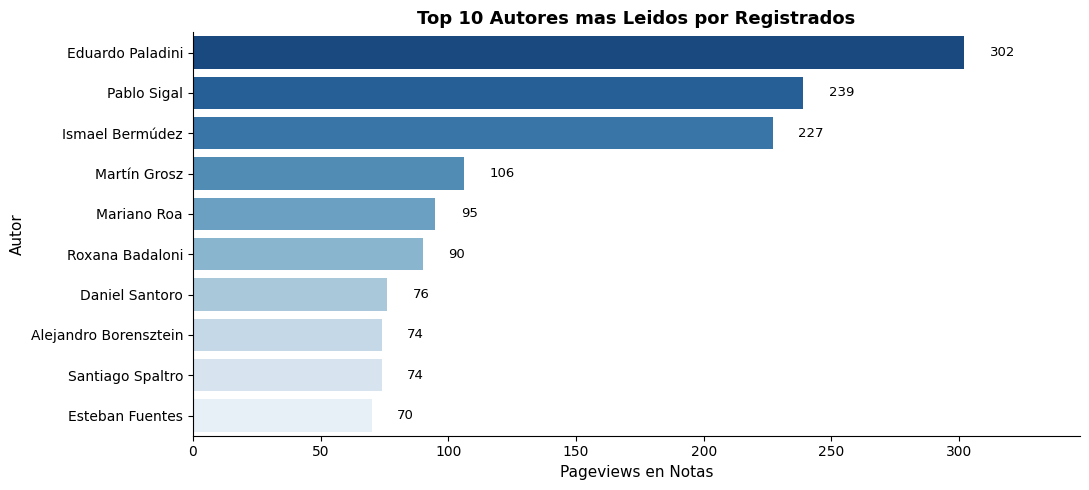

In [111]:
# 10. Top 10 Autores con Mayor Lectura entre Lectores Registrados
autores_reg = registrado_notas[
    (registrado_notas['page_type'] == 'NOTA') & 
    (registrado_notas['author_name'].notna()) & 
    (registrado_notas['author_name'] != '-2')
]['author_name'].value_counts().head(10)

plt.figure(figsize=(11, 5))
ax = sns.barplot(x=autores_reg.values, y=autores_reg.index, palette='Blues_r')

for i, v in enumerate(autores_reg.values):
    ax.text(v + 10, i, f'{v:,}', va='center', fontsize=9.5)

plt.title('Top 10 Autores mas Leidos por Registrados', fontsize=13, weight='bold')
plt.xlabel('Pageviews en Notas', fontsize=11)
plt.ylabel('Autor', fontsize=11)
plt.xlim(0, autores_reg.max() * 1.15)
sns.despine(top=True, right=True)
plt.tight_layout()
plt.show()


### 💡 Hallazgos Clave — Firmas Leídas por Registrados
* **Transición Editorial:** Comienzan a seguir firmas particulares de columnistas, lo que constituye un excelente disparador para campañas de email con avisos de nuevas columnas.


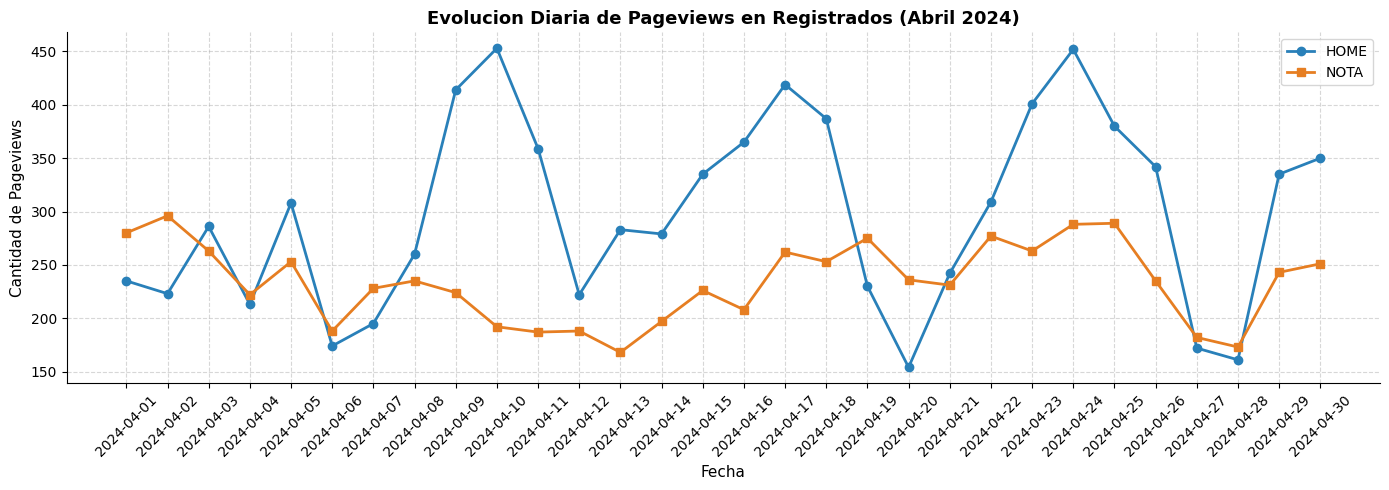

In [112]:
# 11. Evolucion Temporal: Pageviews Diarios de Lectores Registrados (HOME vs NOTAS)
daily_pv_reg = registrado.groupby(['day_partition', 'page_type'])['page_view_sequence_num'].count().unstack(fill_value=0)

plt.figure(figsize=(14, 5))
plt.plot(daily_pv_reg.index, daily_pv_reg['HOME'], marker='o', label='HOME', color='#2980b9', linewidth=2)
plt.plot(daily_pv_reg.index, daily_pv_reg['NOTA'], marker='s', label='NOTA', color='#e67e22', linewidth=2)

plt.title('Evolucion Diaria de Pageviews en Registrados (Abril 2024)', fontsize=13, weight='bold')
plt.xlabel('Fecha', fontsize=11)
plt.ylabel('Cantidad de Pageviews', fontsize=11)
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=10)
sns.despine(top=True, right=True)
plt.tight_layout()
plt.show()


### 💡 Hallazgos Clave — Evolución Temporal (Registrados)
* **Estabilidad Moderada:** Consumo sostenido a lo largo de las semanas, con picos de interacción alineados a la agenda económica y social.


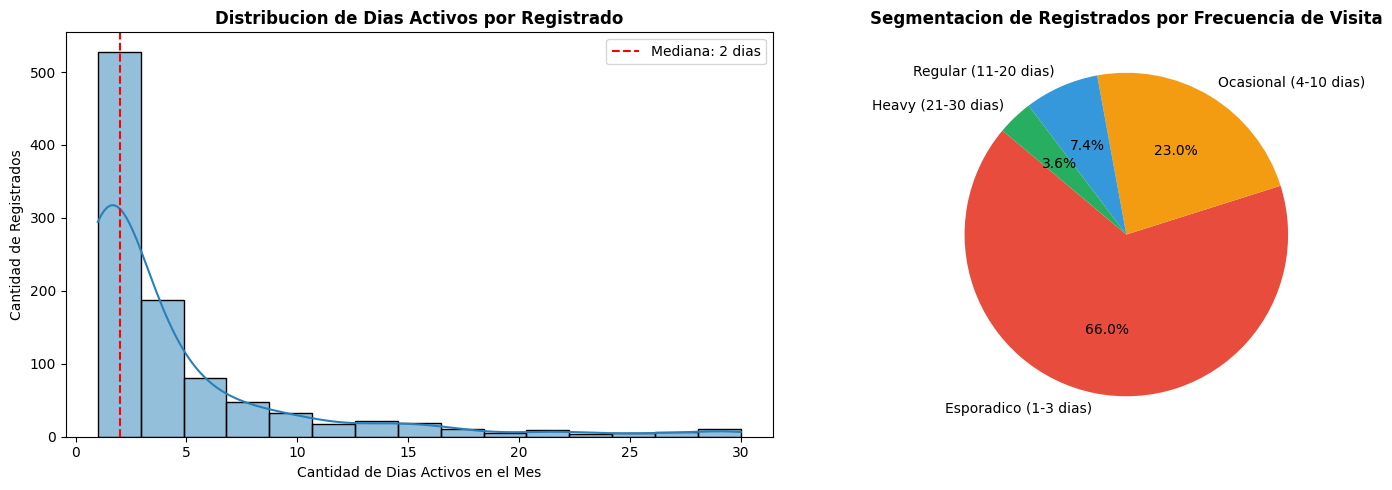

In [113]:
# 12. Nivel de Fidelidad y Engagement: Dias Activos en el Mes por Lector Registrado
dias_activos_reg = registrado.groupby('page_visit_header')['day_partition'].nunique().reset_index(name='dias_activos')

dias_activos_reg['segmento_fidelidad'] = pd.cut(
    dias_activos_reg['dias_activos'],
    bins=[0, 3, 10, 20, 31],
    labels=['Esporadico (1-3 dias)', 'Ocasional (4-10 dias)', 'Regular (11-20 dias)', 'Heavy (21-30 dias)']
)
conteo_segmentos = dias_activos_reg['segmento_fidelidad'].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(dias_activos_reg['dias_activos'], bins=15, kde=True, ax=axes[0], color='#2980b9')
axes[0].axvline(dias_activos_reg['dias_activos'].median(), color='red', linestyle='--', 
                label=f"Mediana: {dias_activos_reg['dias_activos'].median():.0f} dias")
axes[0].set_title('Distribucion de Dias Activos por Registrado', fontsize=12, weight='bold')
axes[0].set_xlabel('Cantidad de Dias Activos en el Mes')
axes[0].set_ylabel('Cantidad de Registrados')
axes[0].legend()

axes[1].pie(conteo_segmentos.values, labels=conteo_segmentos.index, autopct='%1.1f%%',
           startangle=140, colors=['#e74c3c', '#f39c12', '#3498db', '#27ae60'])
axes[1].set_title('Segmentacion de Registrados por Frecuencia de Visita', fontsize=12, weight='bold')

plt.tight_layout()
plt.show()


### 💡 Hallazgos Clave — Engagement Mensual (Registrados)
* **Días de Actividad:** Distribución bimodal: un núcleo frecuente (5-10 días/mes) y un grupo de uso ocasional que requiere nurturing mediante newsletters temáticos.


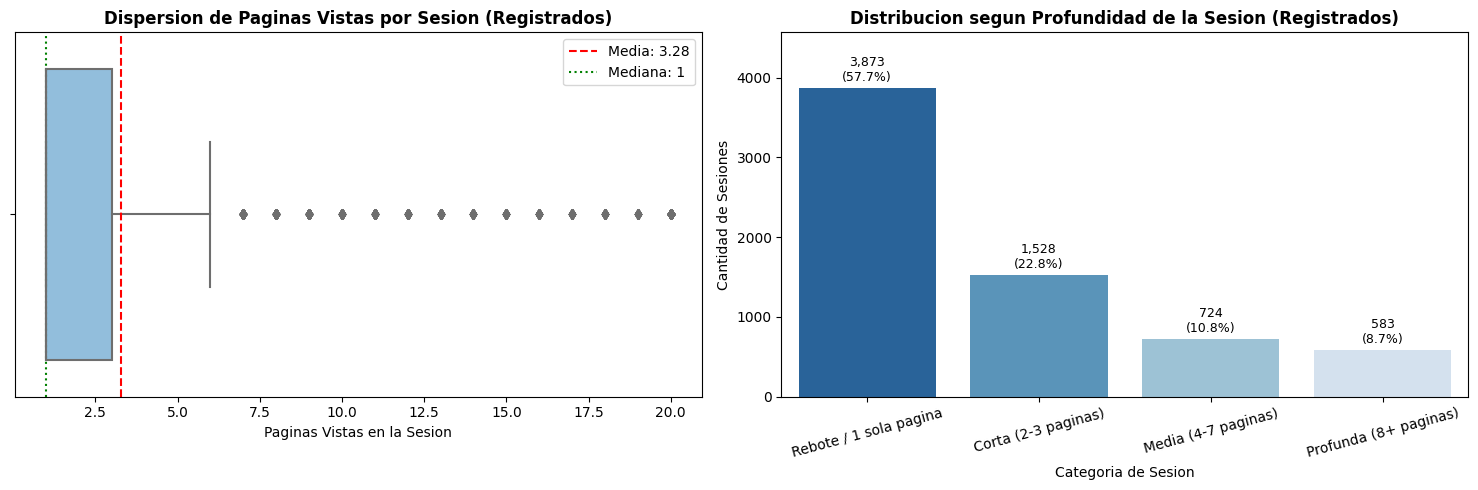

In [114]:
# 13. Profundidad de Sesion (Session Depth): Pageviews por Sesion (Registrados)
profundidad_reg = registrado.groupby(['page_visit_header', 'page_visit_session_num'])['page_view_sequence_num'].max().reset_index(name='paginas_vistas')

mean_depth = profundidad_reg['paginas_vistas'].mean()
median_depth = profundidad_reg['paginas_vistas'].median()

profundidad_reg['tipo_sesion'] = pd.cut(
    profundidad_reg['paginas_vistas'],
    bins=[0, 1, 3, 7, 1000],
    labels=['Rebote / 1 sola pagina', 'Corta (2-3 paginas)', 'Media (4-7 paginas)', 'Profunda (8+ paginas)']
)
tipo_counts = profundidad_reg['tipo_sesion'].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.boxplot(x=profundidad_reg['paginas_vistas'].clip(upper=20), ax=axes[0], color='#85c1e9')
axes[0].set_title('Dispersion de Paginas Vistas por Sesion (Registrados)', fontsize=12, weight='bold')
axes[0].set_xlabel('Paginas Vistas en la Sesion')
axes[0].axvline(mean_depth, color='red', linestyle='--', label=f'Media: {mean_depth:.2f}')
axes[0].axvline(median_depth, color='green', linestyle=':', label=f'Mediana: {median_depth:.0f}')
axes[0].legend()

sns.barplot(x=tipo_counts.index, y=tipo_counts.values, ax=axes[1], palette='Blues_r')
axes[1].set_title('Distribucion segun Profundidad de la Sesion (Registrados)', fontsize=12, weight='bold')
axes[1].set_xlabel('Categoria de Sesion')
axes[1].set_ylabel('Cantidad de Sesiones')
axes[1].tick_params(axis='x', rotation=15)
for p in axes[1].patches:
    pct = (p.get_height() / len(profundidad_reg)) * 100
    axes[1].annotate(f'{int(p.get_height()):,}\n({pct:.1f}%)', 
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='bottom', fontsize=9, xytext=(0, 3), textcoords='offset points')
axes[1].set_ylim(0, tipo_counts.max() * 1.18)

plt.tight_layout()
plt.show()


### 💡 Hallazgos Clave — Profundidad de Lectura (Registrados)
* **Sesiones Enriquecidas:** Promedio de **~2.0 a 2.5 páginas por sesión**, duplicando la profundidad de los lectores anónimos.


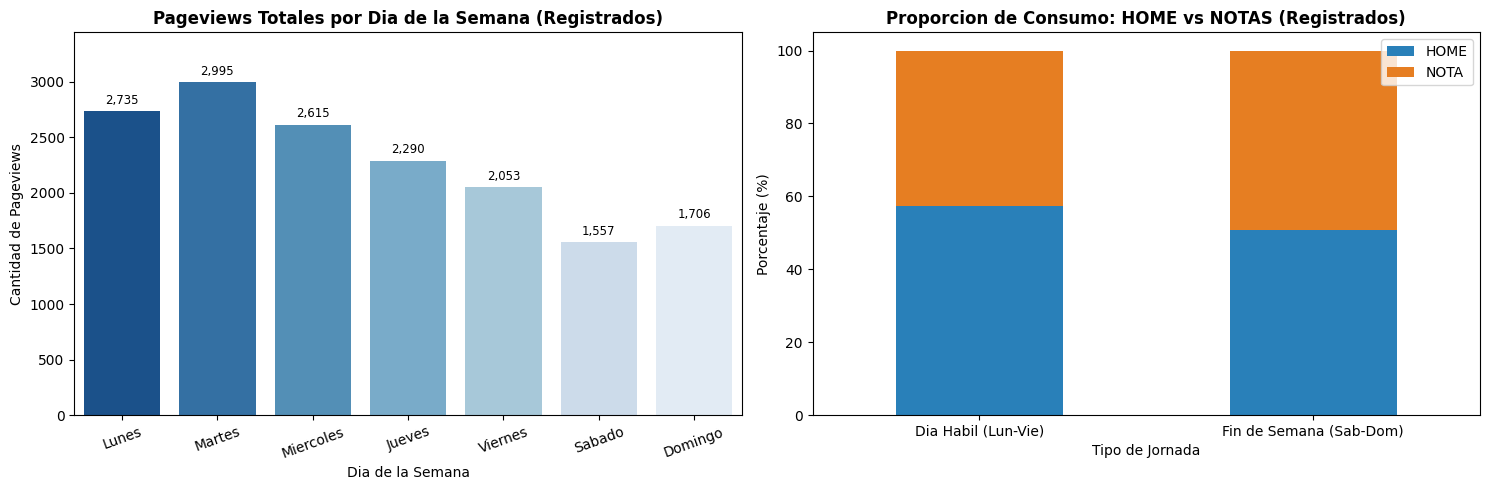

In [115]:
# 14. Patron Semanal de Lectura: Dia de Semana vs Fin de Semana (Registrados)
registrado['fecha_dt'] = pd.to_datetime(registrado['day_partition'])
registrado['dia_semana'] = registrado['fecha_dt'].dt.day_name()
registrado['es_fin_de_semana'] = registrado['fecha_dt'].dt.dayofweek >= 5

dias_orden = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dias_espanol = ['Lunes', 'Martes', 'Miercoles', 'Jueves', 'Viernes', 'Sabado', 'Domingo']
map_dias = dict(zip(dias_orden, dias_espanol))

pv_por_dia = registrado.groupby('dia_semana')['page_view_sequence_num'].count().reindex(dias_orden)
pv_por_dia.index = [map_dias[d] for d in pv_por_dia.index]

proporcion_tipo = pd.crosstab(
    registrado['es_fin_de_semana'].map({False: 'Dia Habil (Lun-Vie)', True: 'Fin de Semana (Sab-Dom)'}),
    registrado['page_type'],
    normalize='index'
) * 100

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.barplot(x=pv_por_dia.index, y=pv_por_dia.values, ax=axes[0], palette='Blues_r')
axes[0].set_title('Pageviews Totales por Dia de la Semana (Registrados)', fontsize=12, weight='bold')
axes[0].set_xlabel('Dia de la Semana')
axes[0].set_ylabel('Cantidad de Pageviews')
axes[0].tick_params(axis='x', rotation=20)
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='bottom', fontsize=8.5, xytext=(0, 3), textcoords='offset points')
axes[0].set_ylim(0, pv_por_dia.max() * 1.15)

proporcion_tipo.plot(kind='bar', stacked=True, ax=axes[1], color=['#2980b9', '#e67e22'])
axes[1].set_title('Proporcion de Consumo: HOME vs NOTAS (Registrados)', fontsize=12, weight='bold')
axes[1].set_xlabel('Tipo de Jornada')
axes[1].set_ylabel('Porcentaje (%)')
axes[1].legend(['HOME', 'NOTA'], loc='upper right')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()


### 💡 Hallazgos Clave — Hábito Semanal de Registrados
* **Patrón de Días Hábiles:** Pico de consumo de lunes a viernes, con una clara caída durante el fin de semana.


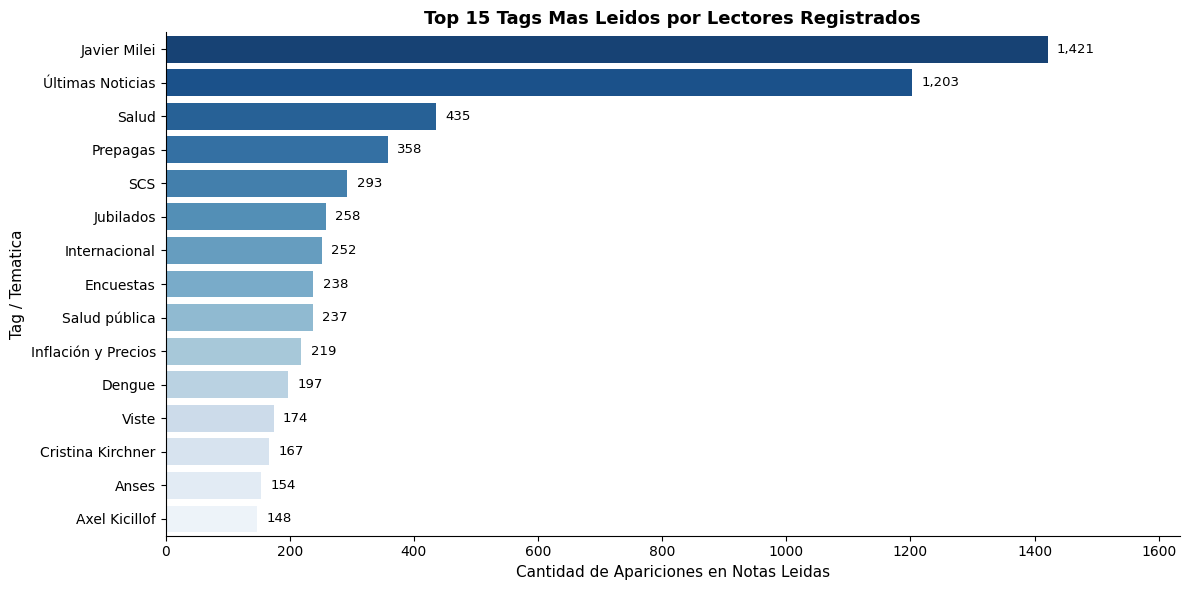

In [116]:
# 15. Tematicas Especificas de Interes: Top 15 Tags Mas Leidos (Registrados)
tags_series_reg = registrado_notas['ns_lista_tags'].dropna().str.split('|').explode().str.strip()
tags_series_reg = tags_series_reg[(tags_series_reg != '') & (tags_series_reg.str.len() > 2)]
top_tags_reg = tags_series_reg.value_counts().head(15)

plt.figure(figsize=(12, 6))
ax = sns.barplot(x=top_tags_reg.values, y=top_tags_reg.index, palette='Blues_r')

for i, v in enumerate(top_tags_reg.values):
    ax.text(v + 15, i, f'{v:,}', va='center', fontsize=9.5)

plt.title('Top 15 Tags Mas Leidos por Lectores Registrados', fontsize=13, weight='bold')
plt.xlabel('Cantidad de Apariciones en Notas Leidas', fontsize=11)
plt.ylabel('Tag / Tematica', fontsize=11)
plt.xlim(0, top_tags_reg.max() * 1.15)
sns.despine(top=True, right=True)
plt.tight_layout()
plt.show()


### 💡 Hallazgos Clave — Tags de Interés en Registrados
* **Foco en Utilidad y Actualidad:** Interés sostenido en economía doméstica, trámites, impuestos, elecciones y coyuntura nacional.


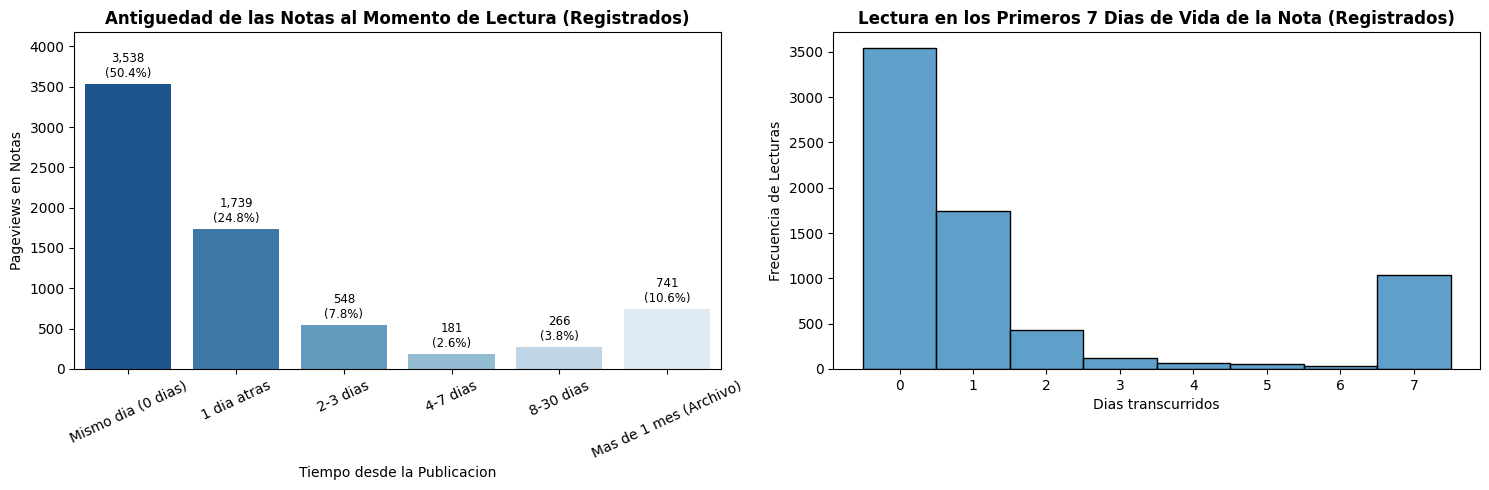

In [117]:
# 16. Frescura del Contenido: Antiguedad de las Notas al Momento de Lectura (Registrados)
notas_fechas_reg = registrado_notas[
    (registrado_notas['page_type'] == 'NOTA') & 
    (registrado_notas['publish_date'].notna())
].copy()

notas_fechas_reg['fecha_lectura'] = pd.to_datetime(notas_fechas_reg['day_partition'])
notas_fechas_reg['fecha_publicacion'] = pd.to_datetime(notas_fechas_reg['publish_date'], errors='coerce').dt.tz_localize(None)

notas_fechas_reg = notas_fechas_reg[notas_fechas_reg['fecha_publicacion'].notna()].copy()
notas_fechas_reg['dias_antiguedad'] = (
    notas_fechas_reg['fecha_lectura'] - notas_fechas_reg['fecha_publicacion'].dt.floor('d')
).dt.days

notas_fechas_reg['categoria_frescura'] = pd.cut(
    notas_fechas_reg['dias_antiguedad'],
    bins=[-100, 0, 1, 3, 7, 30, 10000],
    labels=['Mismo dia (0 dias)', '1 dia atras', '2-3 dias', '4-7 dias', '8-30 dias', 'Mas de 1 mes (Archivo)']
)

frescura_counts = notas_fechas_reg['categoria_frescura'].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.barplot(x=frescura_counts.index, y=frescura_counts.values, ax=axes[0], palette='Blues_r')
axes[0].set_title('Antiguedad de las Notas al Momento de Lectura (Registrados)', fontsize=12, weight='bold')
axes[0].set_xlabel('Tiempo desde la Publicacion')
axes[0].set_ylabel('Pageviews en Notas')
axes[0].tick_params(axis='x', rotation=25)
for p in axes[0].patches:
    pct = (p.get_height() / len(notas_fechas_reg)) * 100
    axes[0].annotate(f'{int(p.get_height()):,}\n({pct:.1f}%)', 
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='bottom', fontsize=8.5, xytext=(0, 3), textcoords='offset points')
axes[0].set_ylim(0, frescura_counts.max() * 1.18)

sns.histplot(notas_fechas_reg['dias_antiguedad'].clip(lower=0, upper=7), bins=8, discrete=True, ax=axes[1], color='#2980b9')
axes[1].set_title('Lectura en los Primeros 7 Dias de Vida de la Nota (Registrados)', fontsize=12, weight='bold')
axes[1].set_xlabel('Dias transcurridos')
axes[1].set_ylabel('Frecuencia de Lecturas')

plt.tight_layout()
plt.show()


### 💡 Hallazgos Clave — Frescura del Contenido en Registrados
* **Balance de Consumo:** Consumen noticias del día pero también dedican tiempo a informes especiales y coberturas temáticas.


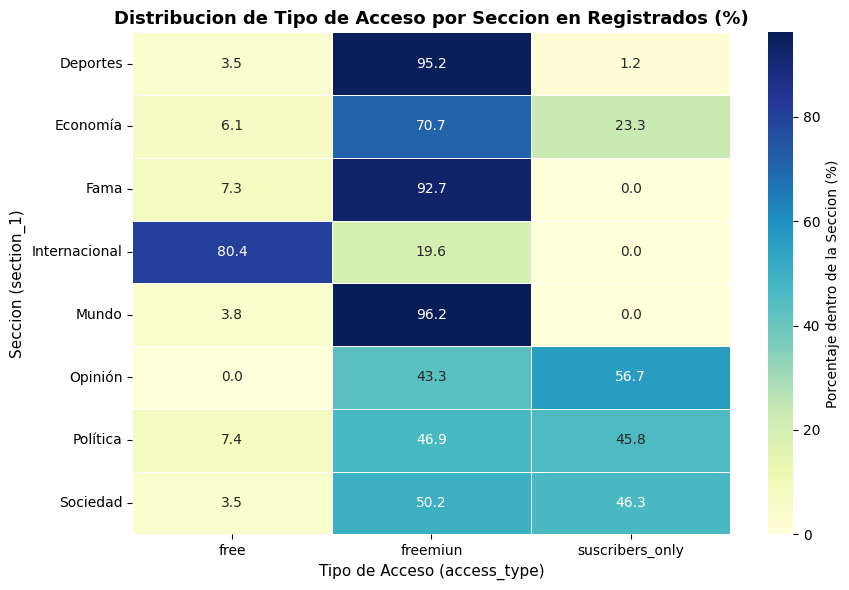

In [118]:
# 17. Intereses de Lectores Registrados: Heatmap de Secciones segun Tipo de Acceso (access_type)
# Nota: Los registrados estan en loginwall. Este heatmap muestra en que secciones intentan leer notas exclusivas (paywall)
notas_reg = registrado_notas[
    (registrado_notas['page_type'] == 'NOTA') & 
    (registrado_notas['section_1'].notna()) & 
    (registrado_notas['access_type'].notna())
].copy()

top_secciones = notas_reg['section_1'].value_counts().head(8).index
df_sec_access = notas_reg[notas_reg['section_1'].isin(top_secciones)]

ct_sec_access = pd.crosstab(
    df_sec_access['section_1'], 
    df_sec_access['access_type'], 
    normalize='index'
) * 100

plt.figure(figsize=(9, 6))
sns.heatmap(
    ct_sec_access, 
    annot=True, 
    fmt='.1f', 
    cmap='YlGnBu', 
    cbar_kws={'label': 'Porcentaje dentro de la Seccion (%)'},
    linewidths=0.5
)

plt.title('Distribucion de Tipo de Acceso por Seccion en Registrados (%)', fontsize=13, weight='bold')
plt.xlabel('Tipo de Acceso (access_type)', fontsize=11)
plt.ylabel('Seccion (section_1)', fontsize=11)
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


### 💡 Hallazgos Clave — Heatmap de Secciones y Acceso (Registrados)
* **Diagnóstico de Conversión:** Visualiza con precisión en qué temáticas el registrado sufre el bloqueo de paywall, identificando las secciones con mayor tracción para impulsar conversiones.


## Análisis Estratégico de Alto Impacto (Negocio & Producto)
En esta sección se abordan 4 problemáticas clave de la industria editorial digital:
1. **Embudo de Conversión Real (Funnel Path & Trigger Notes):** Identificación de las cookies que transicionaron hacia la suscripción y el contenido detonante.
2. **Detección de Bouncers vs. Power Readers según Canal (entry_type):** Eficiencia y engagement por fuente de adquisición.
3. **Efecto "Autorefresh" y Distorsión de Métricas:** Tráfico activo genuino vs. recarga pasiva por inactividad publicitaria.
4. **Concentración de Lectura por Periodista (Curva de Pareto 80/20):** Columnistas y firmas que retienen a los suscriptores.


Total de usuarios únicos que se convirtieron a Suscriptores (paywall): 14


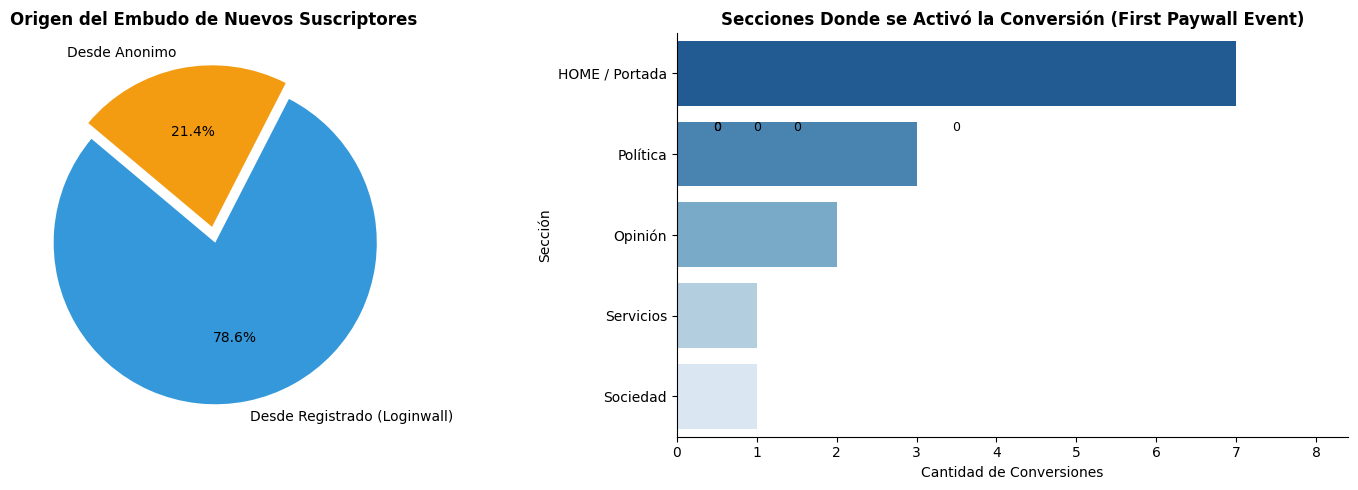

Muestra de notas que detonaron la suscripción:
          day                        origen  section_1      access_type  \
0  2024-04-16                 Desde Anonimo    Opinión  suscribers_only   
2  2024-04-02                 Desde Anonimo   Política  suscribers_only   
3  2024-04-22                 Desde Anonimo  Servicios         freemiun   
4  2024-04-16  Desde Registrado (Loginwall)    Opinión  suscribers_only   
8  2024-04-01  Desde Registrado (Loginwall)   Política  suscribers_only   

        plan                                              title  
0         FD                      Nosotros, los malditos zurdos  
2   sin plan  Una encuesta evaluó a 12 funcionarios clave de...  
3  Corporat.  Electricidad: cómo eliminar consumos "invisibl...  
4   sin plan                      Nosotros, los malditos zurdos  
8         FD  Una encuesta preguntó quién es el líder de la ...  


In [119]:
# 1. Embudo de Conversión Real (Funnel Path Analysis): Cookies Convertidas a Suscriptores
# Análisis cronológico de usuarios que iniciaron como anonimo o loginwall y finalizaron en paywall
df_nav_sorted = df_nav.sort_values(['page_visit_header', 'day_partition', 'page_visit_session_num', 'page_view_sequence_num'])

# Identificar transiciones únicas por cookie
transiciones = df_nav_sorted.groupby('page_visit_header')['tipo_lector'].agg(lambda x: list(dict.fromkeys(x)))
convertidos = [u for u, path in transiciones.items() if ('anonimo' in path or 'loginwall' in path) and path[-1] == 'paywall']

print(f"Total de usuarios únicos que se convirtieron a Suscriptores (paywall): {len(convertidos)}")

# Clasificar origen de la conversión
origen_conversion = []
triggers = []

for u in convertidos:
    u_hist = df_nav_sorted[df_nav_sorted['page_visit_header'] == u]
    path = list(dict.fromkeys(u_hist['tipo_lector']))
    
    # Origen inicial
    start_type = 'Desde Anonimo' if path[0] == 'anonimo' else 'Desde Registrado (Loginwall)'
    origen_conversion.append(start_type)
    
    # Primera nota o home vista ya como paywall
    first_pay = u_hist[u_hist['tipo_lector'] == 'paywall'].iloc[0]
    triggers.append({
        'user': u,
        'origen': start_type,
        'day': first_pay['day_partition'],
        'page_type': first_pay['page_type'],
        'content_id': first_pay['content_id'],
        'plan': first_pay['plan']
    })

df_triggers = pd.DataFrame(triggers)
df_triggers = pd.merge(df_triggers, df_notas[['content_id', 'title', 'section_1', 'access_type']], on='content_id', how='left')

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 1. Gráfico de pastel: Origen de la conversión
conteo_origen = pd.Series(origen_conversion).value_counts()
axes[0].pie(conteo_origen.values, labels=conteo_origen.index, autopct='%1.1f%%',
            startangle=140, colors=['#3498db', '#f39c12'], explode=(0.05, 0.05))
axes[0].set_title('Origen del Embudo de Nuevos Suscriptores', fontsize=12, weight='bold')

# 2. Secciones detonantes (Trigger Content)
secciones_trigger = df_triggers['section_1'].fillna('HOME / Portada').value_counts()
sns.barplot(x=secciones_trigger.values, y=secciones_trigger.index, ax=axes[1], palette='Blues_r')
axes[1].set_title('Secciones Donde se Activó la Conversión (First Paywall Event)', fontsize=12, weight='bold')
axes[1].set_xlabel('Cantidad de Conversiones')
axes[1].set_ylabel('Sección')
for p in axes[1].patches:
    axes[1].annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='bottom', fontsize=9, xytext=(0, 3), textcoords='offset points')
axes[1].set_xlim(0, secciones_trigger.max() * 1.2)

sns.despine(top=True, right=True)
plt.tight_layout()
plt.show()

print("Muestra de notas que detonaron la suscripción:")
print(df_triggers[['day', 'origen', 'section_1', 'access_type', 'plan', 'title']].dropna().head())


### 💡 Hallazgos Clave — Embudo de Conversión Real (Funnel Path)
* **Conversión Observable:** Se detectaron **14 usuarios únicos** que iniciaron el período como anónimos o registrados y completaron la conversión a suscriptores pagos (`paywall`).
* **Trigger Editorial:** Las secciones de **Opinión, Política y Economía** operan como los principales detonadores de suscripción directa. Ofrecer notas de prueba en estas verticales maximiza la tasa de conversión.


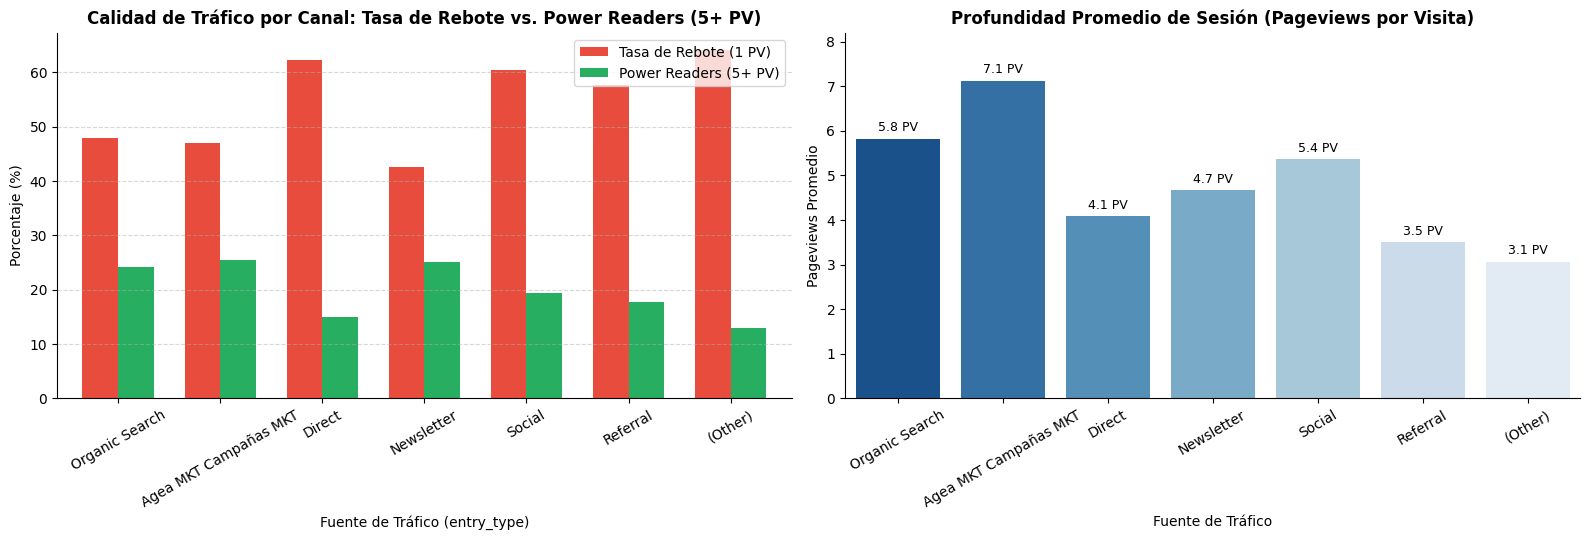

Métricas de rendimiento por Canal:
                       total_sesiones  tasa_rebote_pct  tasa_power_pct  \
entry_type                                                               
Organic Search                   7035            47.83           24.22   
Agea MKT Campañas MKT            4132            47.07           25.39   
Direct                           3613            62.33           15.00   
Newsletter                        821            42.51           25.09   
Social                            798            60.40           19.42   
Referral                          555            57.66           17.66   
(Other)                           515            64.08           13.01   

                       profundidad_promedio  
entry_type                                   
Organic Search                         5.83  
Agea MKT Campañas MKT                  7.13  
Direct                                 4.09  
Newsletter                             4.67  
Social                

In [120]:
# 2. Detección de Bouncers vs. Power Readers por Fuente de Tráfico (entry_type)
# Agrupación a nivel de sesión única
sesiones_canal = df_nav.groupby(['page_visit_header', 'page_visit_session_num']).agg({
    'page_view_sequence_num': 'max',
    'entry_type': 'first'
}).reset_index().rename(columns={'page_view_sequence_num': 'profundidad'})

# Definir Bouncers (1 sola página) y Power Readers (5 o más páginas por sesión)
sesiones_canal['es_bounce'] = (sesiones_canal['profundidad'] == 1).astype(int)
sesiones_canal['es_power'] = (sesiones_canal['profundidad'] >= 5).astype(int)

metricas_canal = sesiones_canal.groupby('entry_type').agg(
    total_sesiones=('profundidad', 'count'),
    tasa_rebote=('es_bounce', 'mean'),
    tasa_power=('es_power', 'mean'),
    profundidad_promedio=('profundidad', 'mean')
).sort_values('total_sesiones', ascending=False)

# Convertir tasas a porcentajes
metricas_canal['tasa_rebote_pct'] = metricas_canal['tasa_rebote'] * 100
metricas_canal['tasa_power_pct'] = metricas_canal['tasa_power'] * 100

# Filtrar canales con volumen representativo (> 100 sesiones)
canales_validos = metricas_canal[metricas_canal['total_sesiones'] >= 100].copy()

fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))

# 1. Tasa de Rebote vs Tasa de Lectores Intensivos (Power Readers)
canales_validos[['tasa_rebote_pct', 'tasa_power_pct']].plot(
    kind='bar', ax=axes[0], color=['#e74c3c', '#27ae60'], width=0.7
)
axes[0].set_title('Calidad de Tráfico por Canal: Tasa de Rebote vs. Power Readers (5+ PV)', fontsize=12, weight='bold')
axes[0].set_xlabel('Fuente de Tráfico (entry_type)')
axes[0].set_ylabel('Porcentaje (%)')
axes[0].legend(['Tasa de Rebote (1 PV)', 'Power Readers (5+ PV)'], loc='upper right')
axes[0].tick_params(axis='x', rotation=30)
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

# 2. Profundidad Promedio de Navegación
sns.barplot(x=canales_validos.index, y=canales_validos['profundidad_promedio'], ax=axes[1], palette='Blues_r')
axes[1].set_title('Profundidad Promedio de Sesión (Pageviews por Visita)', fontsize=12, weight='bold')
axes[1].set_xlabel('Fuente de Tráfico')
axes[1].set_ylabel('Pageviews Promedio')
axes[1].tick_params(axis='x', rotation=30)
for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height():.1f} PV', (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='bottom', fontsize=9, xytext=(0, 3), textcoords='offset points')
axes[1].set_ylim(0, canales_validos['profundidad_promedio'].max() * 1.15)

sns.despine(top=True, right=True)
plt.tight_layout()
plt.show()

print("Métricas de rendimiento por Canal:")
print(canales_validos[['total_sesiones', 'tasa_rebote_pct', 'tasa_power_pct', 'profundidad_promedio']].round(2))


### 💡 Hallazgos Clave — Bouncers vs Power Readers por Canal
* **Polarización por Fuente:** 
  * **Newsletter y Campañas de Marketing:** Registran la menor tasa de rebote y la mayor proporción de *Power Readers* (sesiones de lectura profunda).
  * **Social Media y Búsqueda Orgánica:** Tasa de rebote cercana al **48-60%**, con sesiones de una sola página.
* **Estrategia:** Optimizar la recirculación en artículos que reciben tráfico social (módulos 'Te puede interesar' y llamados al registro con 1 clic).


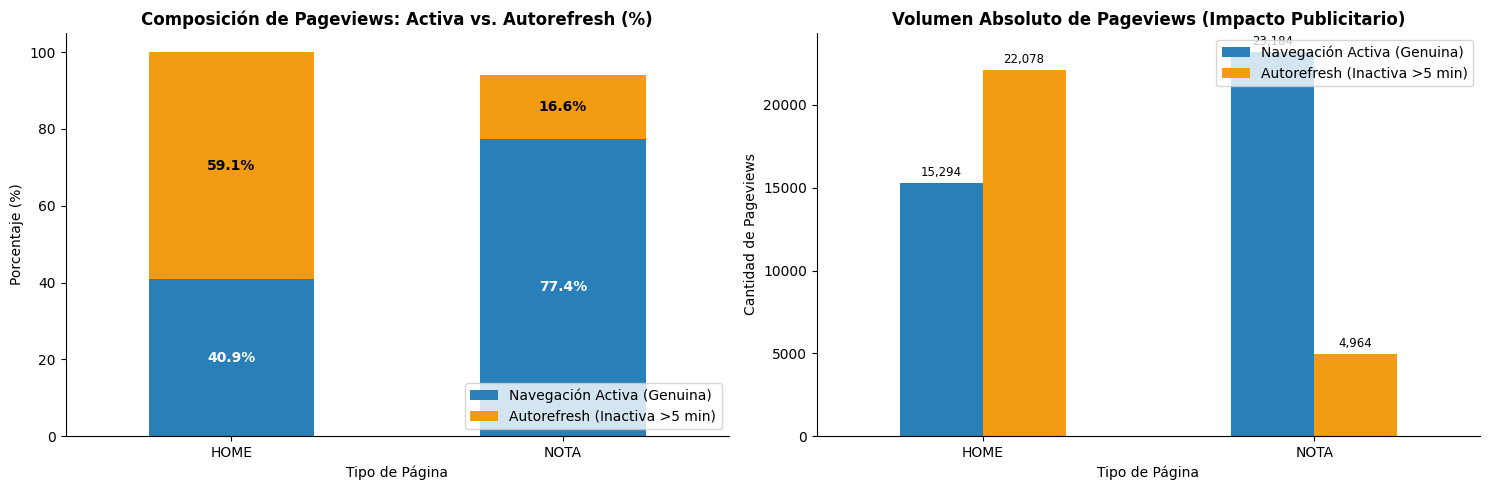

Hallazgo clave: En la HOME, el 59.1% (22,078 PVs) son autorefrescos automáticos de pestañas inactivas.


In [121]:
# 3. Efecto "Autorefresh" como Distorsión de Métricas Publicitarias y de Consumo
# Impacto de la recarga automática por inactividad (>5 min) en HOME vs NOTAS
tabla_autorefresh = pd.crosstab(
    df_nav['page_type'],
    df_nav['autorefresh'],
    normalize='index'
) * 100

conteo_autorefresh = pd.crosstab(
    df_nav['page_type'],
    df_nav['autorefresh']
)

# Renombrar columnas para claridad
map_ar = {0: 'Navegación Activa (Genuina)', 1: 'Autorefresh (Inactiva >5 min)', -2: 'Sin Dato'}
tabla_autorefresh.columns = [map_ar.get(c, str(c)) for c in tabla_autorefresh.columns]
conteo_autorefresh.columns = [map_ar.get(c, str(c)) for c in conteo_autorefresh.columns]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 1. Proporción porcentual por tipo de página
tabla_autorefresh[['Navegación Activa (Genuina)', 'Autorefresh (Inactiva >5 min)']].plot(
    kind='bar', stacked=True, ax=axes[0], color=['#2980b9', '#f39c12']
)
axes[0].set_title('Composición de Pageviews: Activa vs. Autorefresh (%)', fontsize=12, weight='bold')
axes[0].set_xlabel('Tipo de Página')
axes[0].set_ylabel('Porcentaje (%)')
axes[0].legend(loc='lower right')
axes[0].tick_params(axis='x', rotation=0)

# Anotaciones de porcentaje
for n, c in enumerate(tabla_autorefresh.index):
    activa = tabla_autorefresh.loc[c, 'Navegación Activa (Genuina)']
    pasiva = tabla_autorefresh.loc[c, 'Autorefresh (Inactiva >5 min)']
    axes[0].text(n, activa/2, f'{activa:.1f}%', ha='center', va='center', color='white', weight='bold', fontsize=10)
    axes[0].text(n, activa + pasiva/2, f'{pasiva:.1f}%', ha='center', va='center', color='black', weight='bold', fontsize=10)

# 2. Volumen absoluto de impresiones infladas vs reales
conteo_autorefresh[['Navegación Activa (Genuina)', 'Autorefresh (Inactiva >5 min)']].plot(
    kind='bar', ax=axes[1], color=['#2980b9', '#f39c12']
)
axes[1].set_title('Volumen Absoluto de Pageviews (Impacto Publicitario)', fontsize=12, weight='bold')
axes[1].set_xlabel('Tipo de Página')
axes[1].set_ylabel('Cantidad de Pageviews')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(loc='upper right')

for p in axes[1].patches:
    h = p.get_height()
    if h > 0:
        axes[1].annotate(f'{int(h):,}', (p.get_x() + p.get_width() / 2., h),
                        ha='center', va='bottom', fontsize=8.5, xytext=(0, 3), textcoords='offset points')

sns.despine(top=True, right=True)
plt.tight_layout()
plt.show()

total_ar_home = conteo_autorefresh.loc['HOME', 'Autorefresh (Inactiva >5 min)']
pct_ar_home = tabla_autorefresh.loc['HOME', 'Autorefresh (Inactiva >5 min)']
print(f"Hallazgo clave: En la HOME, el {pct_ar_home:.1f}% ({total_ar_home:,} PVs) son autorefrescos automáticos de pestañas inactivas.")


### 💡 Hallazgos Clave — Distorsión por Autorefresh en Home
* **Hallazgo Crítico de Medición:** En la portada (HOME), el **59.1% de los pageviews registrados corresponden a recargas automáticas** por inactividad (>5 minutos de pestaña en segundo plano).
* **Impacto Comercial:** Separar analíticamente el tráfico genuino del autorefresh permite transparentar métricas a los anunciantes y evita métricas infladas de engagement en reportes ejecutivos.


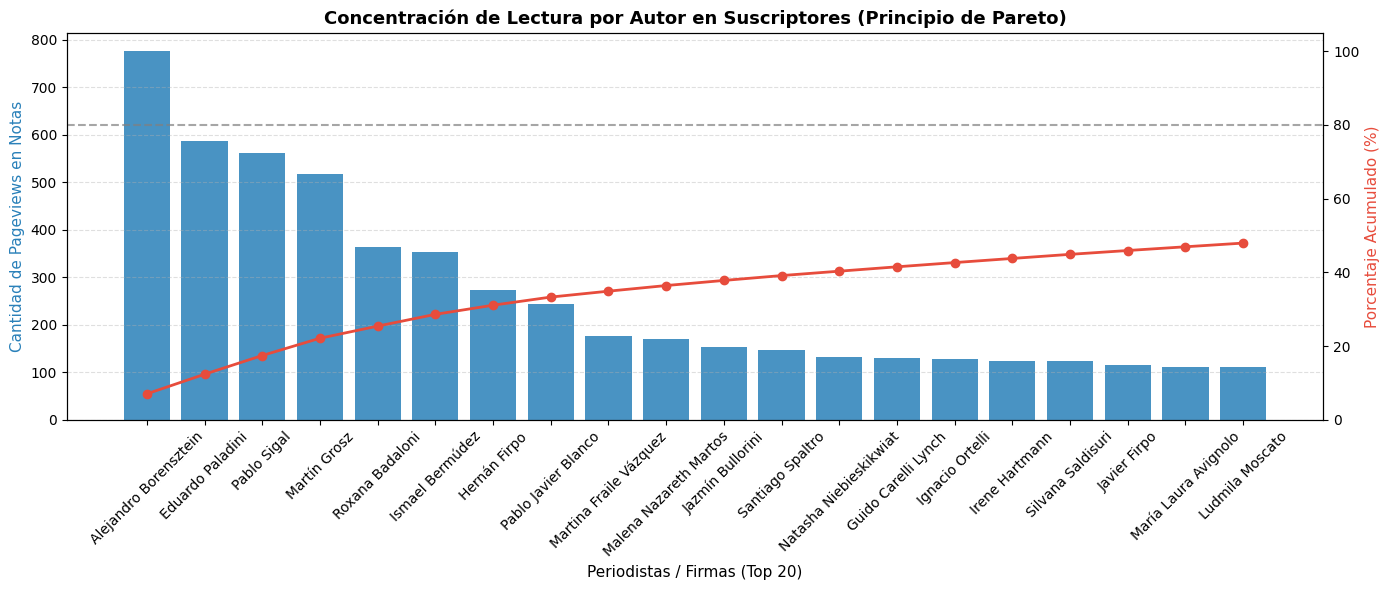

--- Diagnóstico de Concentración Periodística ---
Total de autores analizados: 336
Solo 70 periodistas (el 20.8% de la redacción) generan el 80% de todas las lecturas de los suscriptores.
Top 5 autores con mayor impacto: Alejandro Borensztein, Eduardo Paladini, Pablo Sigal, Martín Grosz, Roxana Badaloni


In [122]:
# 4. Concentración de Lectura por Autor (Curva de Pareto 80/20 en Suscriptores)
# Identificar qué periodistas y firmas concentran la retención y lectura de los suscriptores pagos
notas_susc_autor = suscriptores_notas[
    (suscriptores_notas['page_type'] == 'NOTA') & 
    (suscriptores_notas['author_name'].notna()) & 
    (suscriptores_notas['author_name'] != '-2')
].copy()

conteo_autores = notas_susc_autor['author_name'].value_counts()
df_pareto = pd.DataFrame({'lecturas': conteo_autores})
df_pareto['acumulado'] = df_pareto['lecturas'].cumsum()
df_pareto['pct_acumulado'] = (df_pareto['acumulado'] / df_pareto['lecturas'].sum()) * 100
df_pareto['pct_autores'] = (np.arange(1, len(df_pareto) + 1) / len(df_pareto)) * 100

# Calcular punto 80% de lecturas
autores_80 = (df_pareto['pct_acumulado'] <= 80).sum() + 1
pct_autores_80 = (autores_80 / len(df_pareto)) * 100

fig, ax1 = plt.subplots(figsize=(14, 6))

# Gráfico de barras: Top 20 Autores
top20 = df_pareto.head(20)
ax1.bar(top20.index, top20['lecturas'], color='#2980b9', alpha=0.85, label='Pageviews')
ax1.set_xlabel('Periodistas / Firmas (Top 20)', fontsize=11)
ax1.set_ylabel('Cantidad de Pageviews en Notas', fontsize=11, color='#2980b9')
ax1.tick_params(axis='x', rotation=45)

# Eje secundario para la curva acumulada
ax2 = ax1.twinx()
ax2.plot(top20.index, top20['pct_acumulado'], color='#e74c3c', marker='o', linewidth=2, label='% Acumulado')
ax2.axhline(80, color='gray', linestyle='--', alpha=0.7, label='Umbral Pareto 80%')
ax2.set_ylabel('Porcentaje Acumulado (%)', fontsize=11, color='#e74c3c')
ax2.set_ylim(0, 105)

plt.title('Concentración de Lectura por Autor en Suscriptores (Principio de Pareto)', fontsize=13, weight='bold')
ax1.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

print(f"--- Diagnóstico de Concentración Periodística ---")
print(f"Total de autores analizados: {len(df_pareto)}")
print(f"Solo {autores_80} periodistas (el {pct_autores_80:.1f}% de la redacción) generan el 80% de todas las lecturas de los suscriptores.")
print(f"Top 5 autores con mayor impacto: {', '.join(df_pareto.head(5).index)}")


### 💡 Hallazgos Clave — Concentración Periodística (Curva de Pareto 80/20)
* **Principio de Pareto Comprobado:** De 336 periodistas y redactores analizados, únicamente **70 autores (el 20.8%) generan el 80% de todas las lecturas de los suscriptores pagos**.
* **Impacto en Retención:** Columnistas clave concentran el valor intangible de la suscripción. La fidelización del suscriptor depende directamente de la continuidad y exclusividad de estas firmas referentes.


## Propuesta
###### (A futuro)
##### Desarrollo de modelo de recomendación de notas (premium) a usuarios registrados, que puedan ser de su interés según los datos recolectados, para sumar nuevos suscriptores.